## Summary

This notebook assembles the physical and observational context for the Russian River estuary seepage analysis. 

First, local tidal datums are harmonized by estimating the offset between MSL and NAVD88 at Jenner, and DEM-derived hypsometry is used to convert stage into estuary area and volume, including simple diagnostics for how stage uncertainty propagates into storage. 
A Fourier-based (spectral) open/closed detector is then applied to long time series to detect individual closure events, for which wave energy, river discharge, wind, and precipitation are collated.

For each closure event, hourly and daily mass-balance plots summarize estuary storage change and its partitioning among inflows, overwash, and seepage, providing a visual check on timing and data quality.

The notebook compares USGS and Visitor Center water-level records and generates event-scale figures (e.g., seepage vs $\Delta h$ and visitor-level power-law fits) that link to the pooled and grouped seepage–head models developed in the companion notebook.


_All water levels are in meters relative to NAVD88. Discharges are in m³ s⁻¹, 
volumes in m³, and areas in m² unless noted._



### MSL relative to NAVD88 in  Jenner (Sonoma County)

What is the local offset between **Mean Sea Level (MSL)** and **NAVD88** at/near **Jenner, CA**


Use the two nearest NOAA tide stations that publish tidal datums in feet relative to MLLW, then compute  
$(\Delta = \text{MSL} - \text{NAVD88})$ at each station and interpolate for Jenner, which lies between them along the same coast.

- **9415020 – Point Reyes**: MSL = 3.10 ft, NAVD88 = 0.02 ft → $(\Delta = 3.10 - 0.02 = {3.08\ ft})$.
- **9416841 – Arena Cove**: MSL = 3.14 ft, NAVD88 = 0.14 ft  → $(\Delta = 3.14 - 0.14 = {3.00\ ft})$.

**Estimate for Jenner.** Simple midpoint between the bracketing stations:

$$
\Delta_{\text{Jenner}} \approx \tfrac{3.08 + 3.00}{2} = {3.04\ \text{ft}}\ (\approx {0.927\ \text{m}})
$$


- NOAA VDatum provides site-specific transforms; typical West Coast MSL↔NAVD88 uncertainties are on the order of a few cm (~2–13 cm).

- Use MSL ≈ NAVD88 + 0.927 m near Jenner for quick calculations.

MLLW = Mean Lower Low Water, the average height of the lower of the two daily low tides (for mixed/semidiurnal coasts), computed over a 19-year National Tidal Datum Epoch.


In [66]:
try:
    from IPython import get_ipython
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic("load_ext", "autoreload")
        ip.run_line_magic("autoreload", "2")
except Exception:
    pass

# --- std libs & paths ---
from pathlib import Path
import sys

try:
    here = Path(__file__).resolve().parent   # .py files
except NameError:
    here = Path.cwd().resolve()              # notebooks

root    = here.parent
scripts = root / "src"
if str(scripts) not in sys.path:
    sys.path.insert(0, str(scripts))

# --- plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter
import seaborn as sns

plt.style.use("ggplot")
mpl.rcParams.update({
    "figure.dpi": 300,
    "figure.figsize": (12, 6),
})

for mod in ['plot_config', 'timeseries_functions', 'seepage_analysis', 'seepage_plots']:
    if mod in sys.modules:
        del sys.modules[mod]

import plot_config
from timeseries_functions import *
from seepage_analysis import *
from seepage_plots import *

# --- additional std-lib & domain imports ---
import os
import re
import shutil
import xarray as xr
from scipy.signal import find_peaks
try:
    from PIL import Image
except ImportError:
    Image = None

# --- paths & constants ---
data_path = root / "data"

N_VISITOR_EVENTS = 90   # total visitor-center closure events
N_USGS_EVENTS    = 35   # total USGS closure events


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [67]:
merged = pd.read_pickle(data_path / "processed/merged.pkl")


## Hypsometry

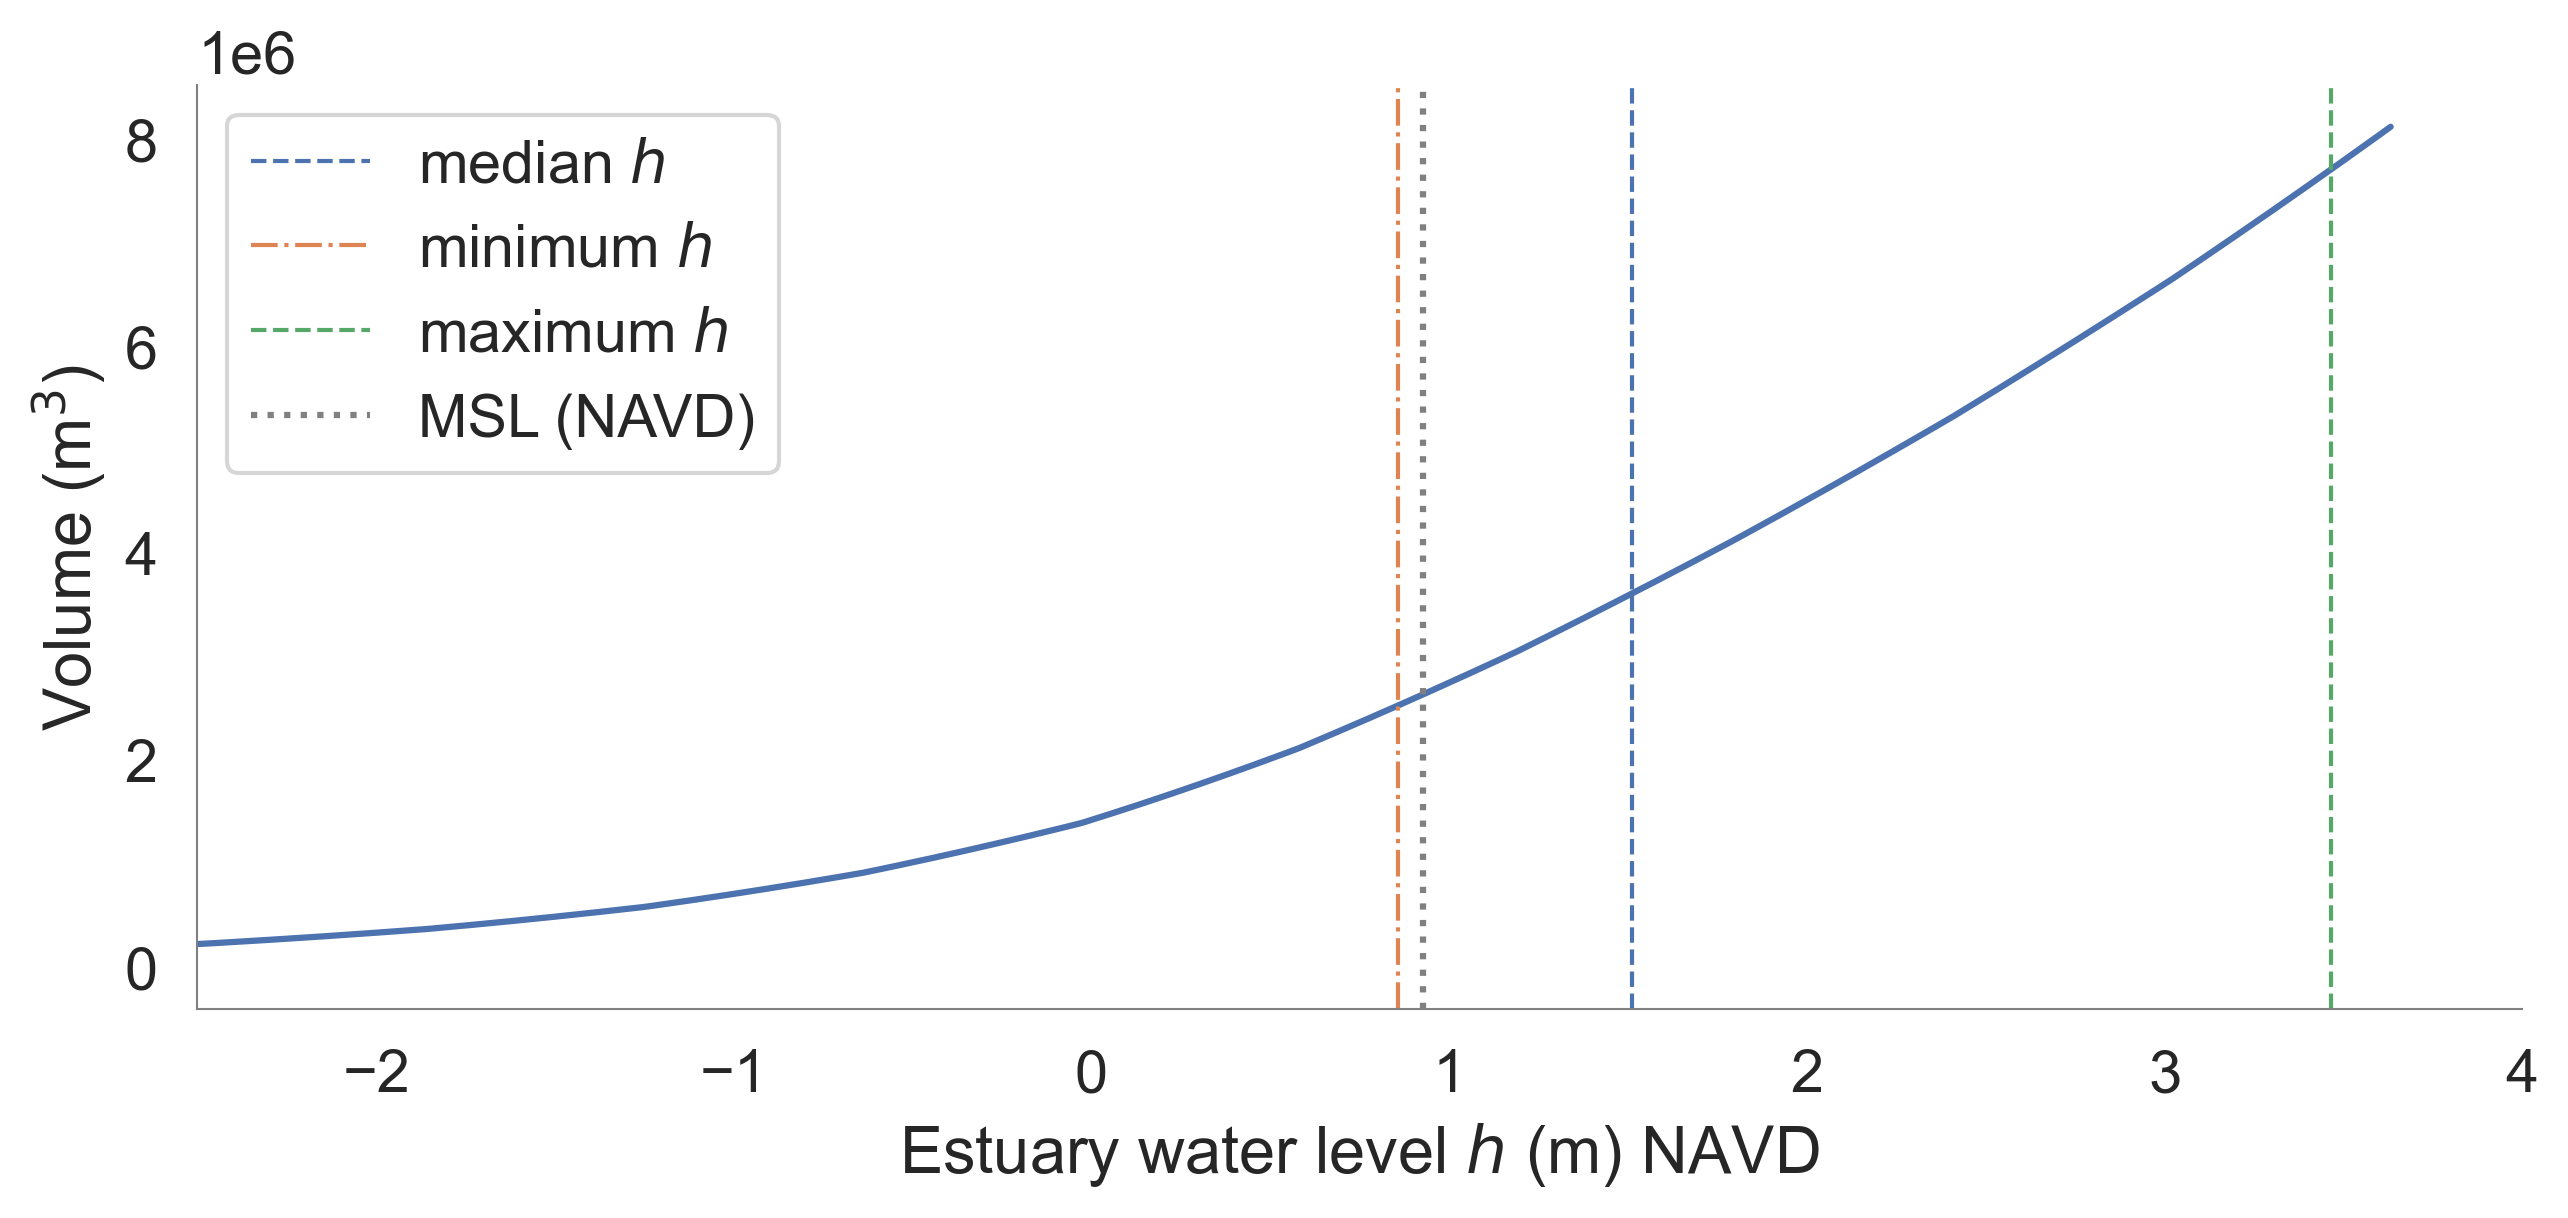

In [68]:
def add_vol(h_name, subset, name = "vol_m3"):
    """
    add hypsometry
    """
    for i, ind in enumerate(subset[h_name].dropna().index):
        diff = (subset.loc[ind][h_name] - hypso.h_m).dropna().abs()
        subset.at[ind, name] = hypso.iloc[diff.idxmin()].vol_m3
    return subset

hypso = pd.read_excel(data_path / "RR_stage_storage.xlsx", header=3)
hypso.columns = ['h_m', 'vol_m3', 'A_m2']
hypso['h_m'] = hypso['h_m'] + 2.73*0.3048

hypso.head()

hypso['vol_m3'].max()/ hypso['h_m'].max()
# 2235803.62 m2, 223 km2

### Hypso plots
plt.figure(figsize = (10, 4))
ax = plt.gca()
ax.plot(hypso.h_m, hypso.vol_m3, '-', ms = 5)
ax.set_ylabel("Volume (m$^3$)")
ax.set_xlabel("Estuary water level $h$ (m) NAVD")
plt.axvline(np.percentile(merged.visitor_h.dropna(), 50),  c = 'C0', ls = "--", lw = 1, label = "median $h$")
plt.axvline(np.percentile(merged.visitor_h.dropna(), 0.5), c = 'C1', ls = "-.", lw = 1, label = "minimum $h$")
plt.axvline(np.percentile(merged.visitor_h.dropna(), 99.5),  c = 'C2', ls = "--", lw = 1, label = "maximum $h$")

plt.axvline(0.927, c = 'grey', ls = ":", label = "MSL (NAVD)" )
ax.set_xlim(-2.5, 4)
ax.legend()


In [69]:
hypso.head()

,h_m,vol_m3,A_m2
0,3.632104,8.120671e+06,0.0
1,3.622104,8.095340e+06,0.0
2,3.612104,8.070451e+06,0.0
3,3.602104,8.045590e+06,0.0
4,3.592104,8.020758e+06,0.0


In [70]:

# Make sure hypso is sorted by stage
hypso = hypso.sort_values("h_m").reset_index(drop=True)
hypso = hypso.query("h_m > -1")

# 1) dV/dh 
dVdh = np.gradient(hypso["vol_m3"].values, hypso["h_m"].values)
hypso["A_from_grad_m2"] = dVdh

# Otherwise use the gradient:
A = hypso["A_from_grad_m2"].values

# 2) Volume error for a 0.10 m stage error
dh = 0.1  # 10cm
hypso["dV_0p1m_m3"] = np.abs(A) * dh

# 3) Percent volume error; avoid division by ~0 for tiny volumes
eps = 1e-6
mask = hypso["vol_m3"].values > eps
hypso["pct_err_0p1m"] = np.nan
hypso.loc[mask, "pct_err_0p1m"] = (
    100.0 * hypso.loc[mask, "dV_0p1m_m3"] / hypso.loc[mask, "vol_m3"]
)


In [71]:
hypso.head()

,h_m,vol_m3,A_m2,A_from_grad_m2,dV_0p1m_m3,pct_err_0p1m
1427,-0.997896,705655.157766,0.148263,530089.978051,53008.997805,7.512026
1428,-0.987896,710956.057547,0.148263,530943.416239,53094.341624,7.468020
1429,-0.977896,716274.026091,0.148263,532793.928312,53279.392831,7.438409
1430,-0.967896,721611.936113,0.148263,534586.820288,53458.682029,7.408231
1431,-0.957896,726965.762497,0.148263,536199.536697,53619.953670,7.375857


In [72]:
# Ensure sorted
hypso = hypso.sort_values("h_m").reset_index(drop=True)

# Define a coarser 0.1 m grid
dh_coarse = 0.1  # 10 cm
h_min, h_max = hypso["h_m"].min(), hypso["h_m"].max()
h_coarse = np.arange(h_min, h_max + dh_coarse/2, dh_coarse)

# Interpolate volume onto the 0.1 m grid
V_coarse = np.interp(h_coarse, hypso["h_m"].values, hypso["vol_m3"].values)

# Compute dV/dh on the 0.1 m grid
dVdh_coarse = np.gradient(V_coarse, h_coarse)


(-1.0, 5.0)

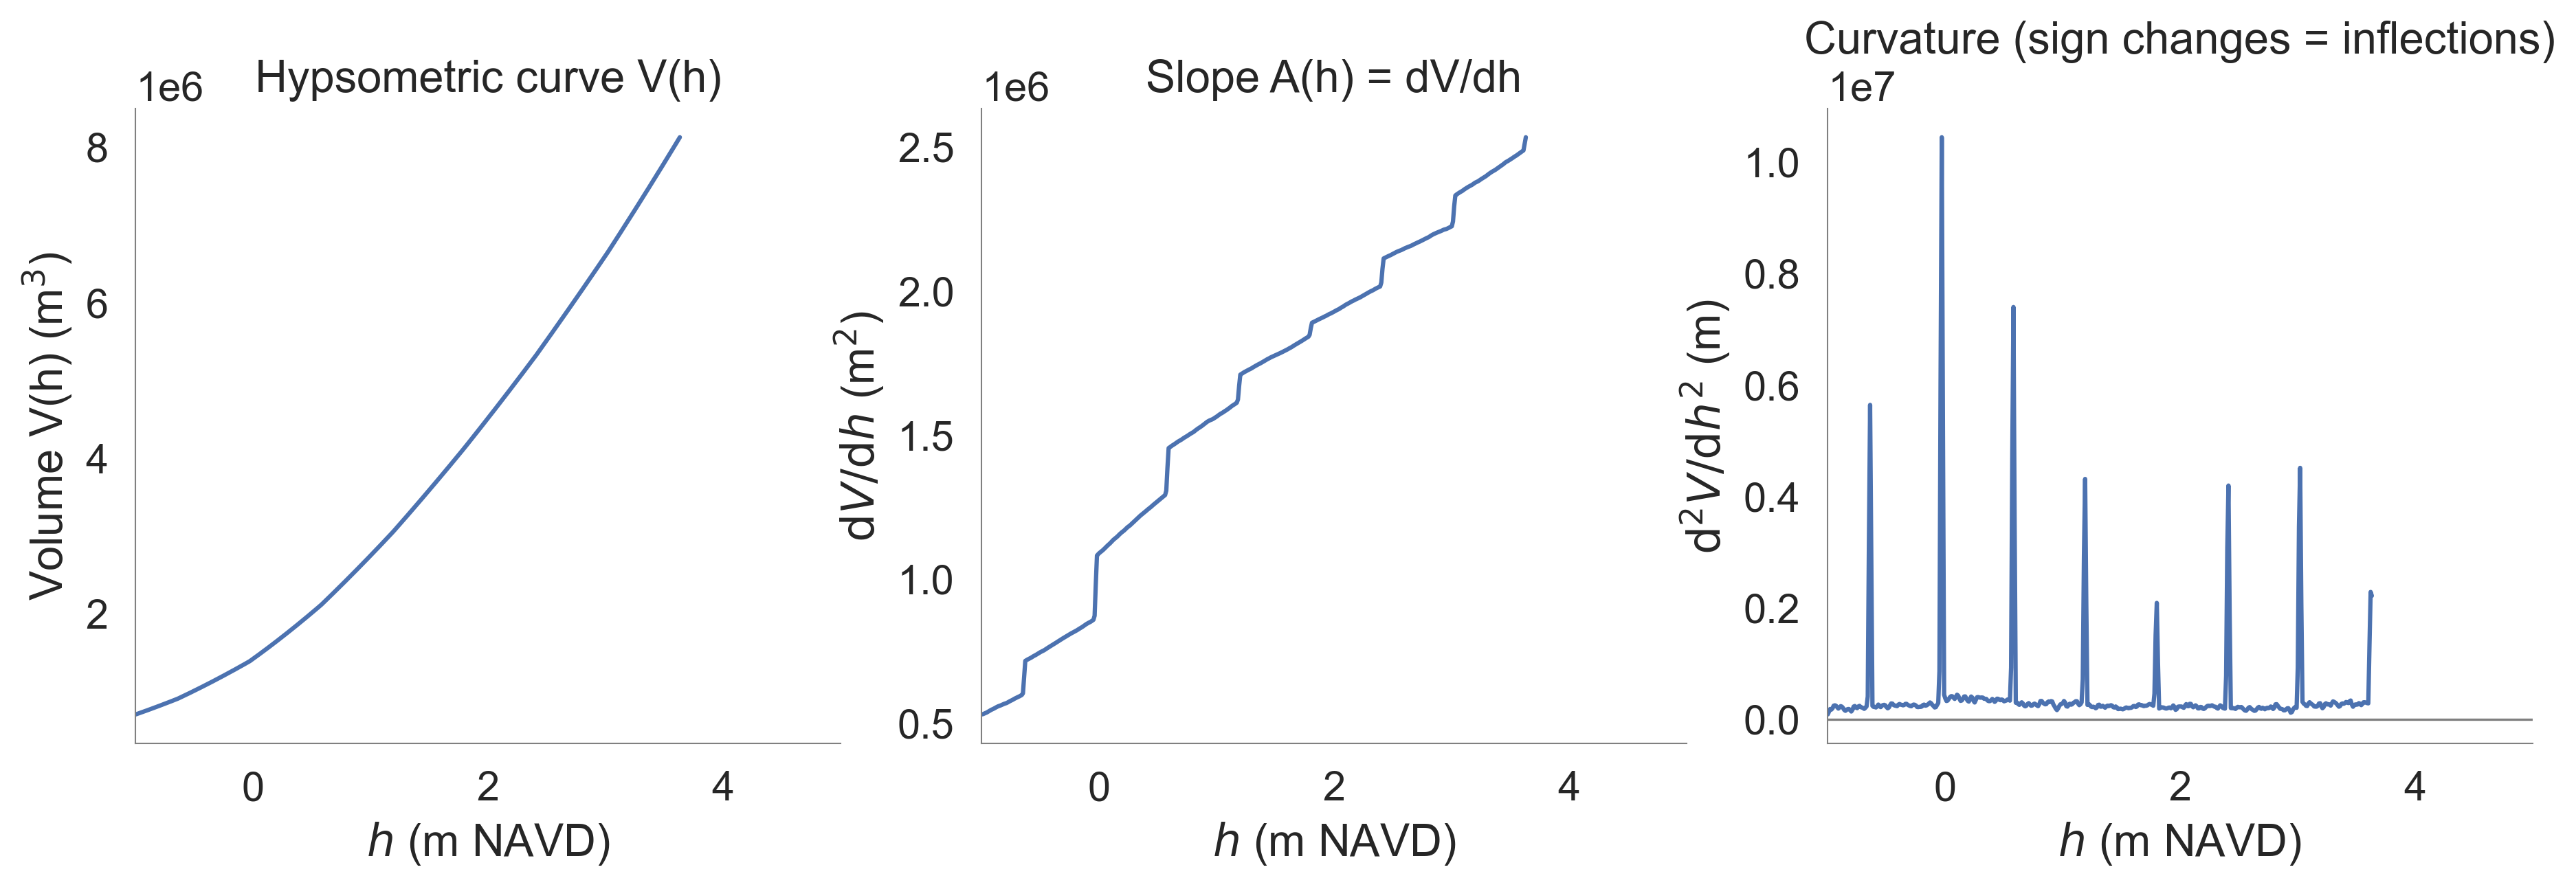

In [73]:

# Assuming hypso already has h_m and vol_m3 and we've computed dVdh above
hypso["dVdh_m2"] = dVdh  # slope of V(h), units m^2

# Second derivative (curvature)
d2Vdh2 = np.gradient(hypso["dVdh_m2"].values, hypso["h_m"].values)
hypso["d2Vdh2_m"] = d2Vdh2  # units ~ m

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

# (a) Original V(h)
ax = axes[0]
ax.plot(hypso["h_m"], hypso["vol_m3"])
ax.set_ylabel("Volume V(h) (m$^3$)")
ax.set_xlabel("$h$ (m NAVD)")
ax.set_title("Hypsometric curve V(h)")

# (b) First derivative dV/dh
ax = axes[1]
ax.plot(hypso["h_m"], hypso["dVdh_m2"])
ax.set_ylabel(r"$\mathrm{d}V/\mathrm{d}h$ (m$^2$)")
ax.set_xlabel("$h$ (m NAVD)")
ax.set_title("Slope A(h) = dV/dh")

# (c) Second derivative d²V/dh²
ax = axes[2]
ax.plot(hypso["h_m"], hypso["d2Vdh2_m"])
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_ylabel(r"$\mathrm{d}^2 V/\mathrm{d} h^2$ (m)")
ax.set_xlabel("$h$ (m NAVD)")
ax.set_title("Curvature (sign changes = inflections)")

ax.set_xlim(-1, 5 )

Found 8 discontinuities in the hypsometry curve
  h locations (m NAVD): [-0.64 -0.03  0.58  1.19  1.8   2.41  3.02  3.62]

Spacing between discontinuities (m):   [0.61 0.61 0.61 0.61 0.61 0.61 0.6 ]
Spacing between discontinuities (ft):  [2.   2.   2.   2.   2.   2.   1.97]

  Median spacing: 0.610 m  =  2.00 ft

Interpretation: The discontinuities are consistent with a survey grid of
~2 ft, i.e. the original cross-sections were measured at
every 2-foot contour interval, with volume linearly
interpolated between them. This creates a piecewise-linear V(h) and
corresponding step-changes in A(h) = dV/dh at each control elevation.


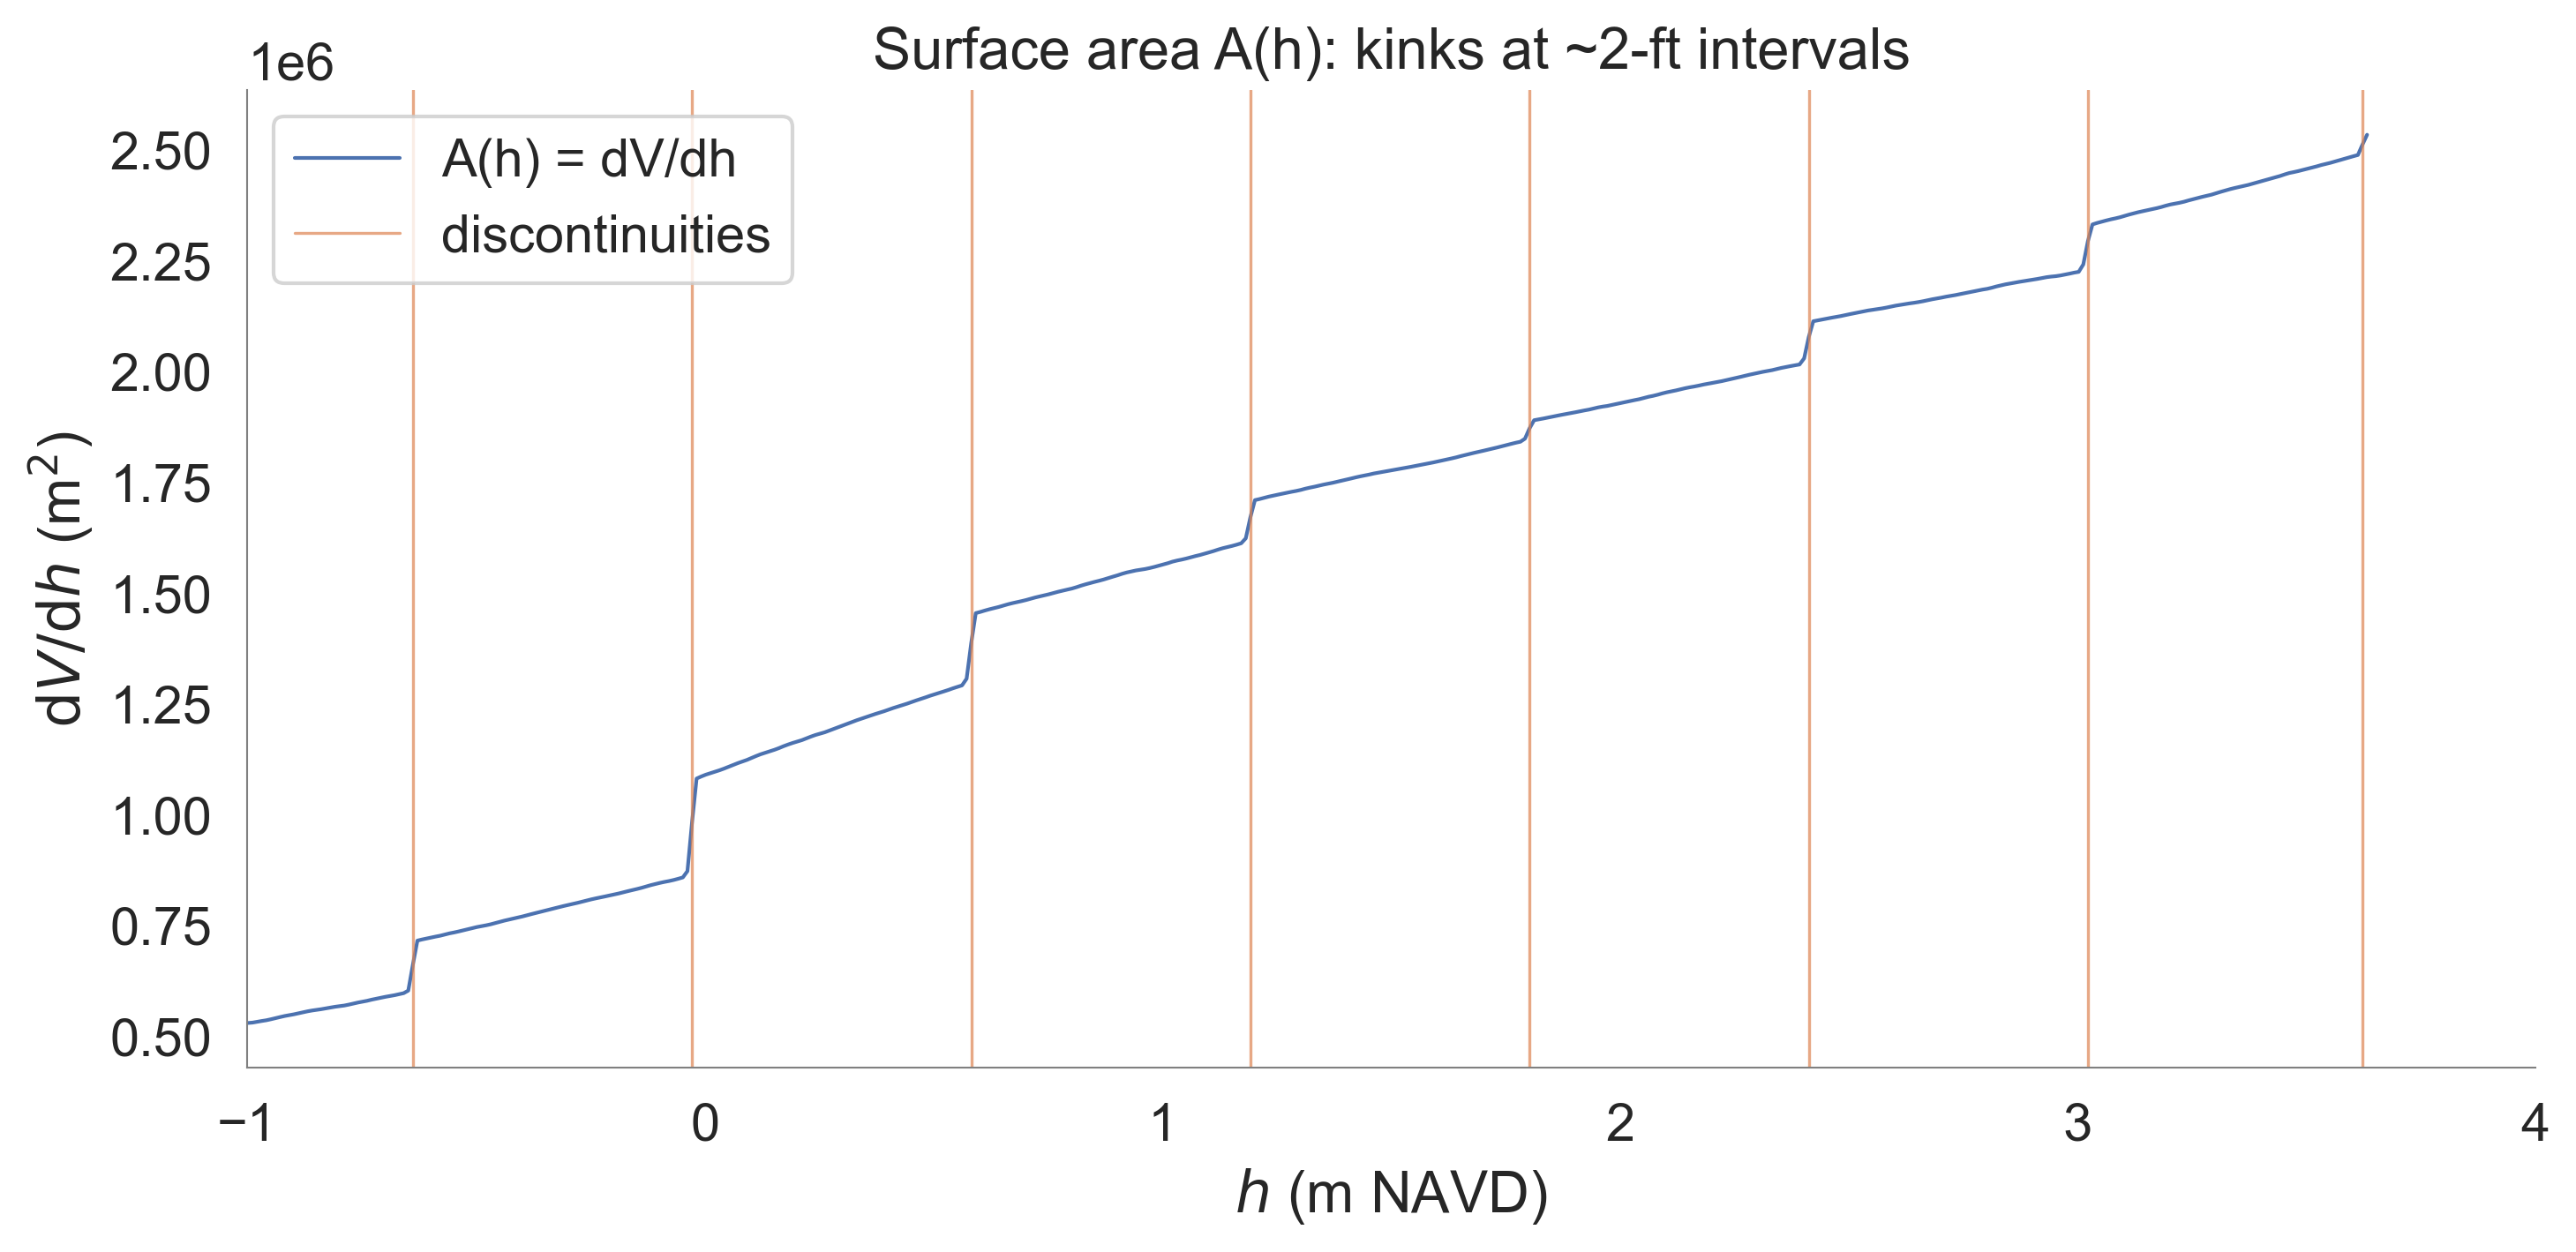

In [74]:
# ── Hypsometry discontinuity analysis (for Dane) ────────────────────────────────────────────
# The V(h) curve was built from cross-sections at every 2-foot contour, with
# volume linearly interpolated between control elevations. This creates a
# piecewise-linear V(h) and step-changes in A(h) = dV/dh at each 2-foot mark.

FT_PER_M = 1 / 0.3048

h  = hypso["h_m"].values
d2 = hypso["d2Vdh2_m"].values

# Detect kink locations: spikes above 99th percentile of |d2V/dh2|
threshold = np.percentile(np.abs(d2), 95)
kink_idx  = np.where(np.abs(d2) > threshold)[0]
kink_h_m  = h[kink_idx]

# Cluster adjacent detections (within 0.05 m) into single kink events
clusters = []
current  = [kink_h_m[0]]
for v in kink_h_m[1:]:
    if v - current[-1] < 0.05:
        current.append(v)
    else:
        clusters.append(np.mean(current))
        current = [v]
clusters.append(np.mean(current))
clusters = np.array(clusters)

spacings_m  = np.diff(clusters)
spacings_ft = spacings_m * FT_PER_M

print(f"Found {len(clusters)} discontinuities in the hypsometry curve")
print(f"  h locations (m NAVD): {np.round(clusters, 2)}")
print(f"\nSpacing between discontinuities (m):   {np.round(spacings_m, 3)}")
print(f"Spacing between discontinuities (ft):  {np.round(spacings_ft, 2)}")
print(f"\n  Median spacing: {np.median(spacings_m):.3f} m  =  {np.median(spacings_ft):.2f} ft")
print()
print("Interpretation: The discontinuities are consistent with a survey grid of")
print(f"~{round(np.median(spacings_ft))} ft, i.e. the original cross-sections were measured at")
print(f"every {round(np.median(spacings_ft))}-foot contour interval, with volume linearly")
print("interpolated between them. This creates a piecewise-linear V(h) and")
print("corresponding step-changes in A(h) = dV/dh at each control elevation.")

# ── Plot kink locations on the A(h) curve ──
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hypso["h_m"], hypso["dVdh_m2"], lw=1, label="A(h) = dV/dh")
for i, c in enumerate(clusters):
    ax.axvline(c, color="C1", lw=0.8, alpha=0.7, label="discontinuities" if i == 0 else None)
ax.set_xlabel("$h$ (m NAVD)")
ax.set_ylabel(r"$\mathrm{d}V/\mathrm{d}h$ (m$^2$)")
ax.set_title(f"Surface area A(h): kinks at ~{round(np.median(spacings_ft))}-ft intervals")
ax.set_xlim(-1, 4)
ax.legend()
plt.tight_layout()

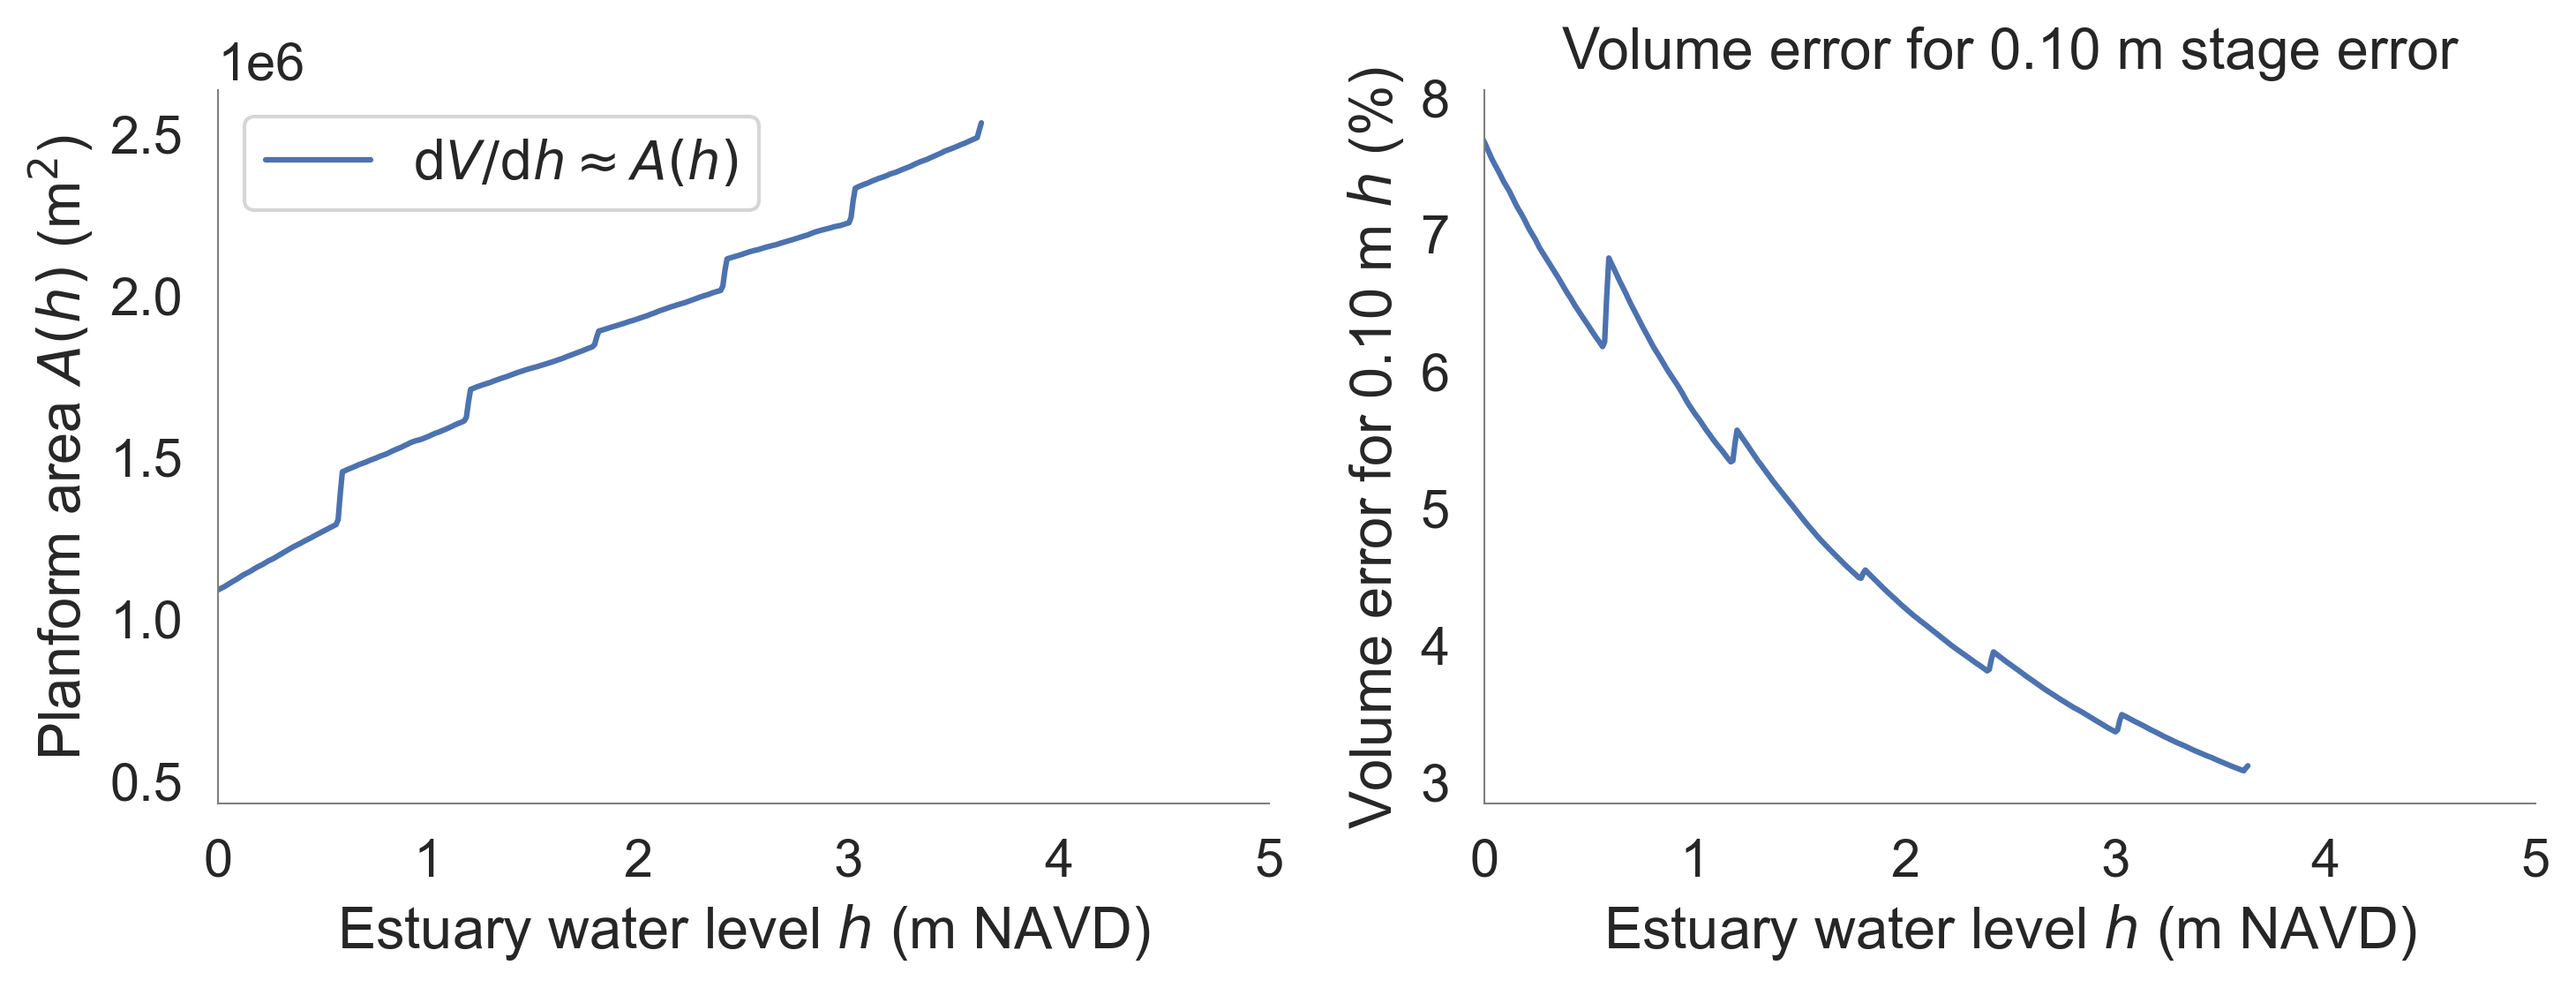

In [75]:
A = dVdh  # alias, if you want

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

ax = axes[0]
ax.plot(hypso["h_m"], A, label=r"$\mathrm{d}V/\mathrm{d}h \approx A(h)$")
ax.set_ylabel("Planform area $A(h)$ (m$^2$)")
ax.set_xlabel("Estuary water level $h$ (m NAVD)")
ax.legend()

ax = axes[1]
ax.plot(hypso["h_m"], hypso["pct_err_0p1m"])
ax.set_ylabel("Volume error for 0.10 m $h$ (%)")
ax.set_xlabel("Estuary water level $h$ (m NAVD)")
ax.set_title("Volume error for 0.10 m stage error")

for ax in axes:
    ax.set_xlim(0, 5)

plt.tight_layout()

For small errors in stage $h$, the induced volume error can be approximated as
$$
  \Delta V(h) \approx \frac{\mathrm{d}V}{\mathrm{d}h}\,\Delta h \approx A(h)\,\Delta h,
$$

where $V(h)$ is the cumulative volume at stage $h$ and $A(h) = \mathrm{d}V/\mathrm{d}h$ is the corresponding planform area.

The associated percent volume error for a given stage error $\Delta h$ is
$$
  \text{\% error}(h) \approx 100 \times \frac{\Delta V(h)}{V(h)}
  = 100 \times \frac{A(h)\,\Delta h}{V(h)}.
$$


In [76]:
# Assuming hypso is your DataFrame with columns 'h_m' and 'vol_m3'

hypso['A_surface'] = hypso['vol_m3'].diff() / hypso['h_m'].diff()

# Optionally fill first row with 0 or NaN
hypso['A_surface'].iloc[0] = np.nan  # or 0

# Find max surface area
max_surface_area = hypso['A_surface'].max()
max_row = hypso.loc[hypso['A_surface'].idxmax()]

print(f"Max surface area: {max_surface_area/1e6:.2f} km² at elevation h = {max_row['h_m']:.2f} m")
# estuary area is about 2.5 square km

# Find min surface area
min_surface_area = hypso['A_surface'].min()
min_row = hypso.loc[hypso['A_surface'].idxmin()]

print(f"Min surface area: {min_surface_area/1e6:.2f} km² at elevation h = {min_row['h_m']:.2f} m")

# Find median surface area
med_row = hypso.query("h_m > {0}".format(merged['visitor_h'].median())).sort_values('h_m').iloc[0]
med_surface_area = med_row['A_surface']

print(f"Median surface area: {med_surface_area/1e6:.2f} km² at elevation h = {med_row['h_m']:.2f} m")

Max surface area: 2.53 km² at elevation h = 3.63 m
Min surface area: 0.53 km² at elevation h = -0.99 m
Median surface area: 1.78 km² at elevation h = 1.51 m


## Code to identify closures

### Fourier transform to detect open/close events

(178, 163)

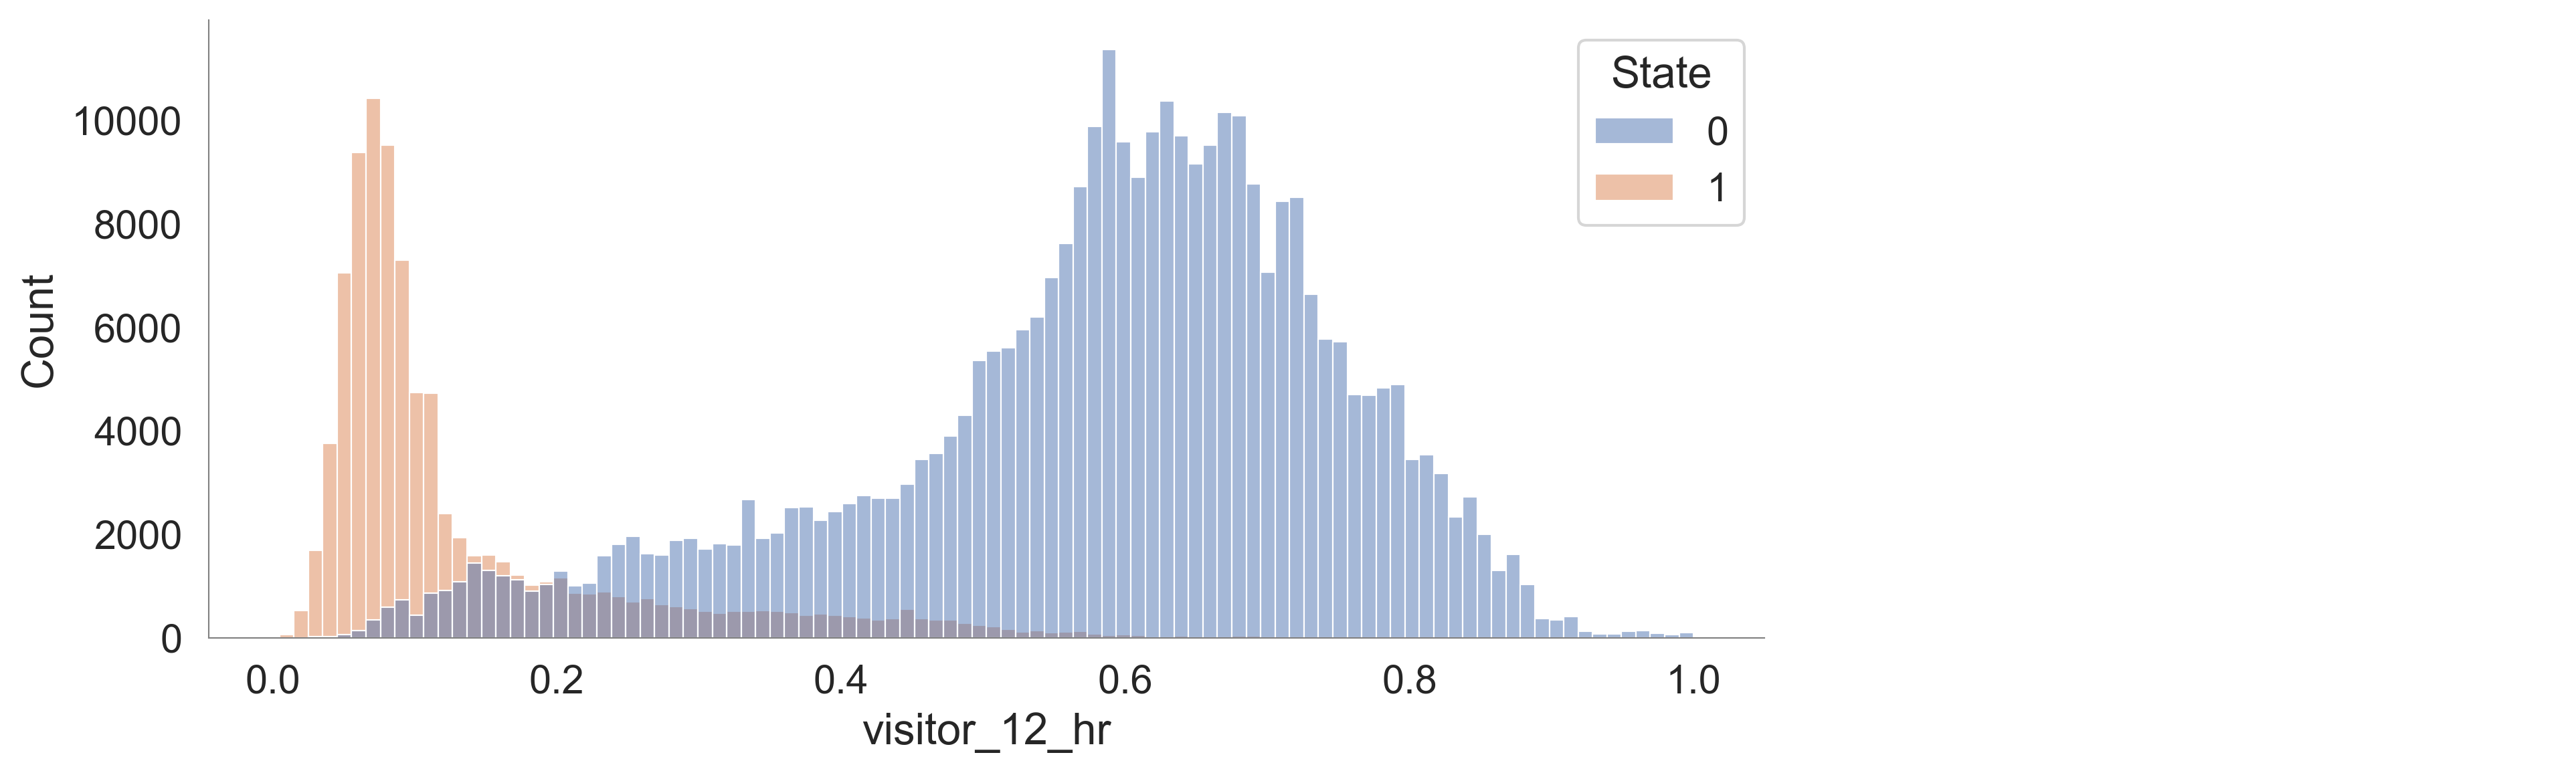

In [77]:

merged = add_power_visitor(merged, 12, label = 'visitor_12_hr' )
merged = add_power_USGS(merged, 12, label = 'USGS_12_hr' )

# State = 1 corresponds to closed.
merged['State'] = merged['State'].astype(int)
merged['State_visit'] = (merged['visitor_12_hr'] < 0.3) & (merged['State'] == 1)
merged['State_USGS'] = (merged['USGS_12_hr'] < 0.3) & (merged['State'] == 1)

merged['State_visit'] = merged['State_visit'].astype(float)
merged['State_USGS'] = merged['State_USGS'].astype(float)
merged['rain_vol'] = 0
plt.figure(figsize = (10, 4))
sns.histplot(data=merged, x= 'visitor_12_hr', hue='State', alpha = 0.5)

ax = plt.gca()
ax.text(1.5, 1., ' ', transform=ax.transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');

len(np.unique(merged.query("State == 0 and visitor_12_hr < 0.2").index.date)), \
len(np.unique(merged.query("State == 1 and visitor_12_hr > 0.3").index.date))

In [78]:
# Mean difference between h_vc and h_ocn
merged.visitor_h.mean() - (merged.visitor_h - merged.v).mean()

0.998022618112416

## Add wave energy

https://cdip.ucsd.edu/themes/media/docs/documents/html_pages/compendium.html

In [79]:

hindcast = xr.open_dataset(data_path / 'CDIP/MOP_alongshore_VE157_hindcast.nc')
nowcast = xr.open_dataset(data_path / 'CDIP/VE157_nowcast.nc')

waveHs = pd.DataFrame({"waveHs" : hindcast.waveHs.data}, index= pd.to_datetime(hindcast.time.data))

waveHs = pd.concat([waveHs, pd.DataFrame({"waveHs" : nowcast.waveHs.data}, index= pd.to_datetime(nowcast.waveTime))], axis = 0)

waveHs.index = waveHs.index.tz_localize("UCT")

hourly = merged.groupby(pd.Grouper(freq='H'))[['State_visit', 'State_USGS', 'USGS_h', 'visitor_h','v',
                                               'Q', 'visitor_12_hr']].median()
hourly.index = pd.to_datetime(hourly.index)
hourly = hourly.join(waveHs, how = 'inner')

merged['date_hr']  = merged.index.round('H')
merged['datetime']  = merged.index
merged['year'] = pd.to_datetime(merged.date).dt.year
waveHs['date_hr'] = waveHs.index


merged_wave = merged.merge(waveHs, on = 'date_hr', how = 'inner')
merged_wave.index = merged_wave.datetime


In [80]:
# merged_all = merged.copy()
merged_wave.query("waveHs > 0.5").shape[0]/ merged_wave.shape[0]

0.15328716278672905

In [81]:
merged_wave.shape

(421914, 25)

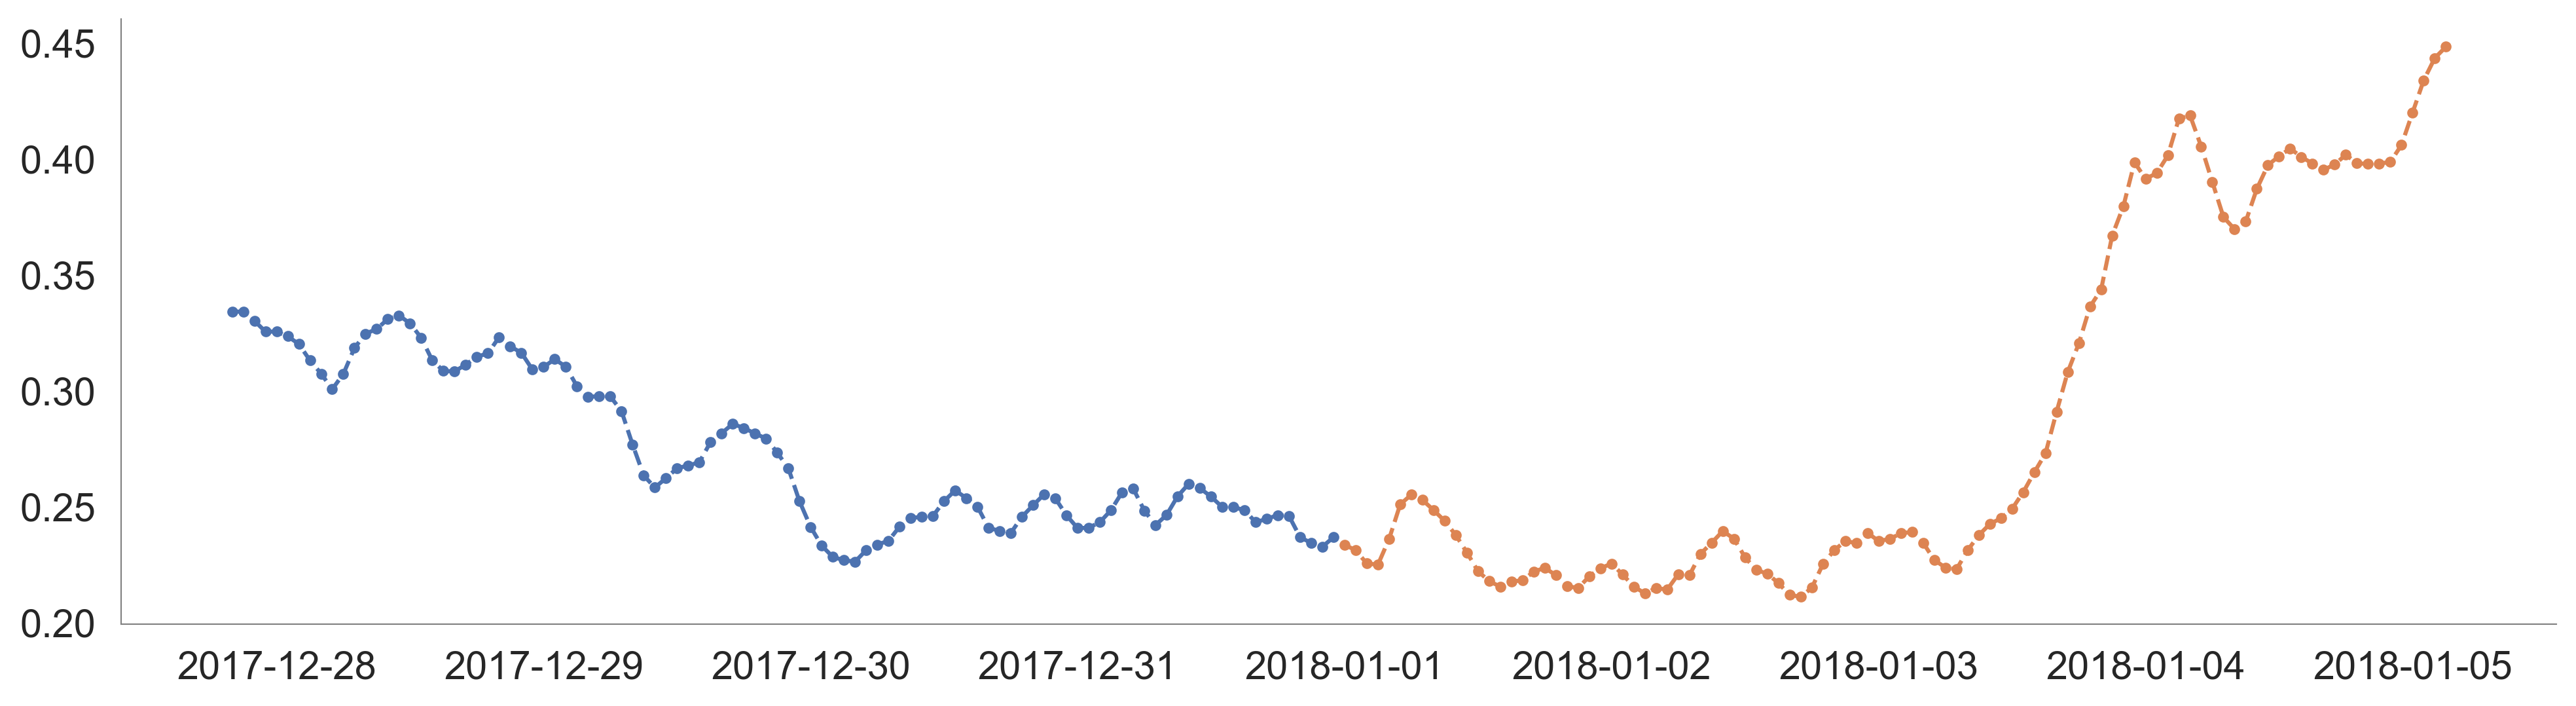

In [82]:
plt.figure(figsize = (16, 4))
plt.plot(hindcast.time.data[-100:], hindcast.waveHs.data[-100:], '.--')
plt.plot(nowcast.waveTime.data[:100], nowcast.waveHs.data[:100], '.--')

## Wind


In [83]:
files = sorted(os.listdir(data_path / 'bml_wind'))


In [84]:
wind = pd.DataFrame()
for file in files:
    wind = pd.concat([wind,
                      pd.read_csv(data_path / 'bml_wind' / file, header = None,
                                  names = ['date', 'blank',  'wind'])])


In [85]:
wind = wind.query("date != 'UTC_Datetime'")
wind['date_hr'] = pd.to_datetime(wind.date,utc = True)
wind = wind.drop(['blank', 'date'], axis = 1)

In [86]:
merged_wave = merged_wave.merge(wind, on = 'date_hr', how = 'inner')
merged_wave.index = merged_wave.datetime
# adding backwards compatibility
merged_wave['rain_vol'] = 0
merged_wave['rain_m3s'] = 0

merged['rain_vol'] = 0
merged['rain_m3s'] = 0

# merged_wave = merged_wave.drop('datetime', axis = 1)

In [87]:
merged_wave.shape, merged.shape

((395882, 27), (421943, 25))

## Rain

In [88]:
files = sorted(os.listdir(data_path / 'bml_rain'))


In [89]:
rain = pd.DataFrame()
for file in files:
    rain = pd.concat([rain,
                      pd.read_csv(data_path / 'bml_rain' / file, header = None,
                                  names = ['date', 'blank',  'rain'])])
    
rain = rain.query("date != 'UTC_Datetime'")
rain['date'] = pd.to_datetime(rain.date,utc = True)
rain = rain.drop(['blank'], axis = 1)


In [90]:
# merged_wave = merged_wave.drop('datetime', axis = 1)
rain['date'] = pd.to_datetime(rain['date'], utc=True)
# merged_wave['datetime'] = pd.to_datetime(merged_wave['datetime'], utc=True)

# Sort both (required for merge_asof)
rain = rain.sort_values('date')
merged_wave = merged_wave.sort_index()

merged_rain = pd.merge_asof(
    merged_wave.drop(['datetime','date'], axis = 1),
    rain,
    left_on='datetime',
    right_on='date',
    direction='nearest',    
    tolerance=pd.Timedelta("5m")   # optional: max allowed gap
)
merged_rain["rain"] = merged_rain["rain"] * 0.0254  # now in meters


In [91]:
# For each timestep, we only care about events where it actually rained, 
# so we first filter to rows with rain > 0. For those rows, we take the observed water 
# level visitor_h, find the nearest matching stage h_m in the hypsometry table, 
# and then assign the corresponding A_surface value. In other words, we use a nearest-neighbor lookup
# from water level to surface area, applied only during rainy periods.


# mask: only rows where it actually rained
rain_mask = merged_rain["rain"] > 0

# pull hypsometry arrays
h_vals = hypso["h_m"].to_numpy()
A_vals = hypso["A_surface"].to_numpy()

# make an output column (NaN where no rain)
merged_rain["A_surface"] = np.nan

def nearest_A_surface(h):
    """Return A_surface for the h_m closest to h."""
    idx = np.argmin(np.abs(h_vals - h))
    return A_vals[idx]

# apply only where rain > 0
merged_rain.loc[rain_mask, "A_surface"] = (
    merged_rain.loc[rain_mask, "visitor_h"]
    .apply(nearest_A_surface)
)


merged_rain['rain_vol'] = merged_rain['A_surface']*merged_rain['rain']

merged_rain['rain_vol'] = merged_rain['rain_vol'].fillna(0)
merged_rain['rain_m3s'] = merged_rain['rain_vol']/24./3600

merged_rain.index = merged_rain['date_hr']
merged_rain['date'] = merged_rain['date_hr'].dt.date


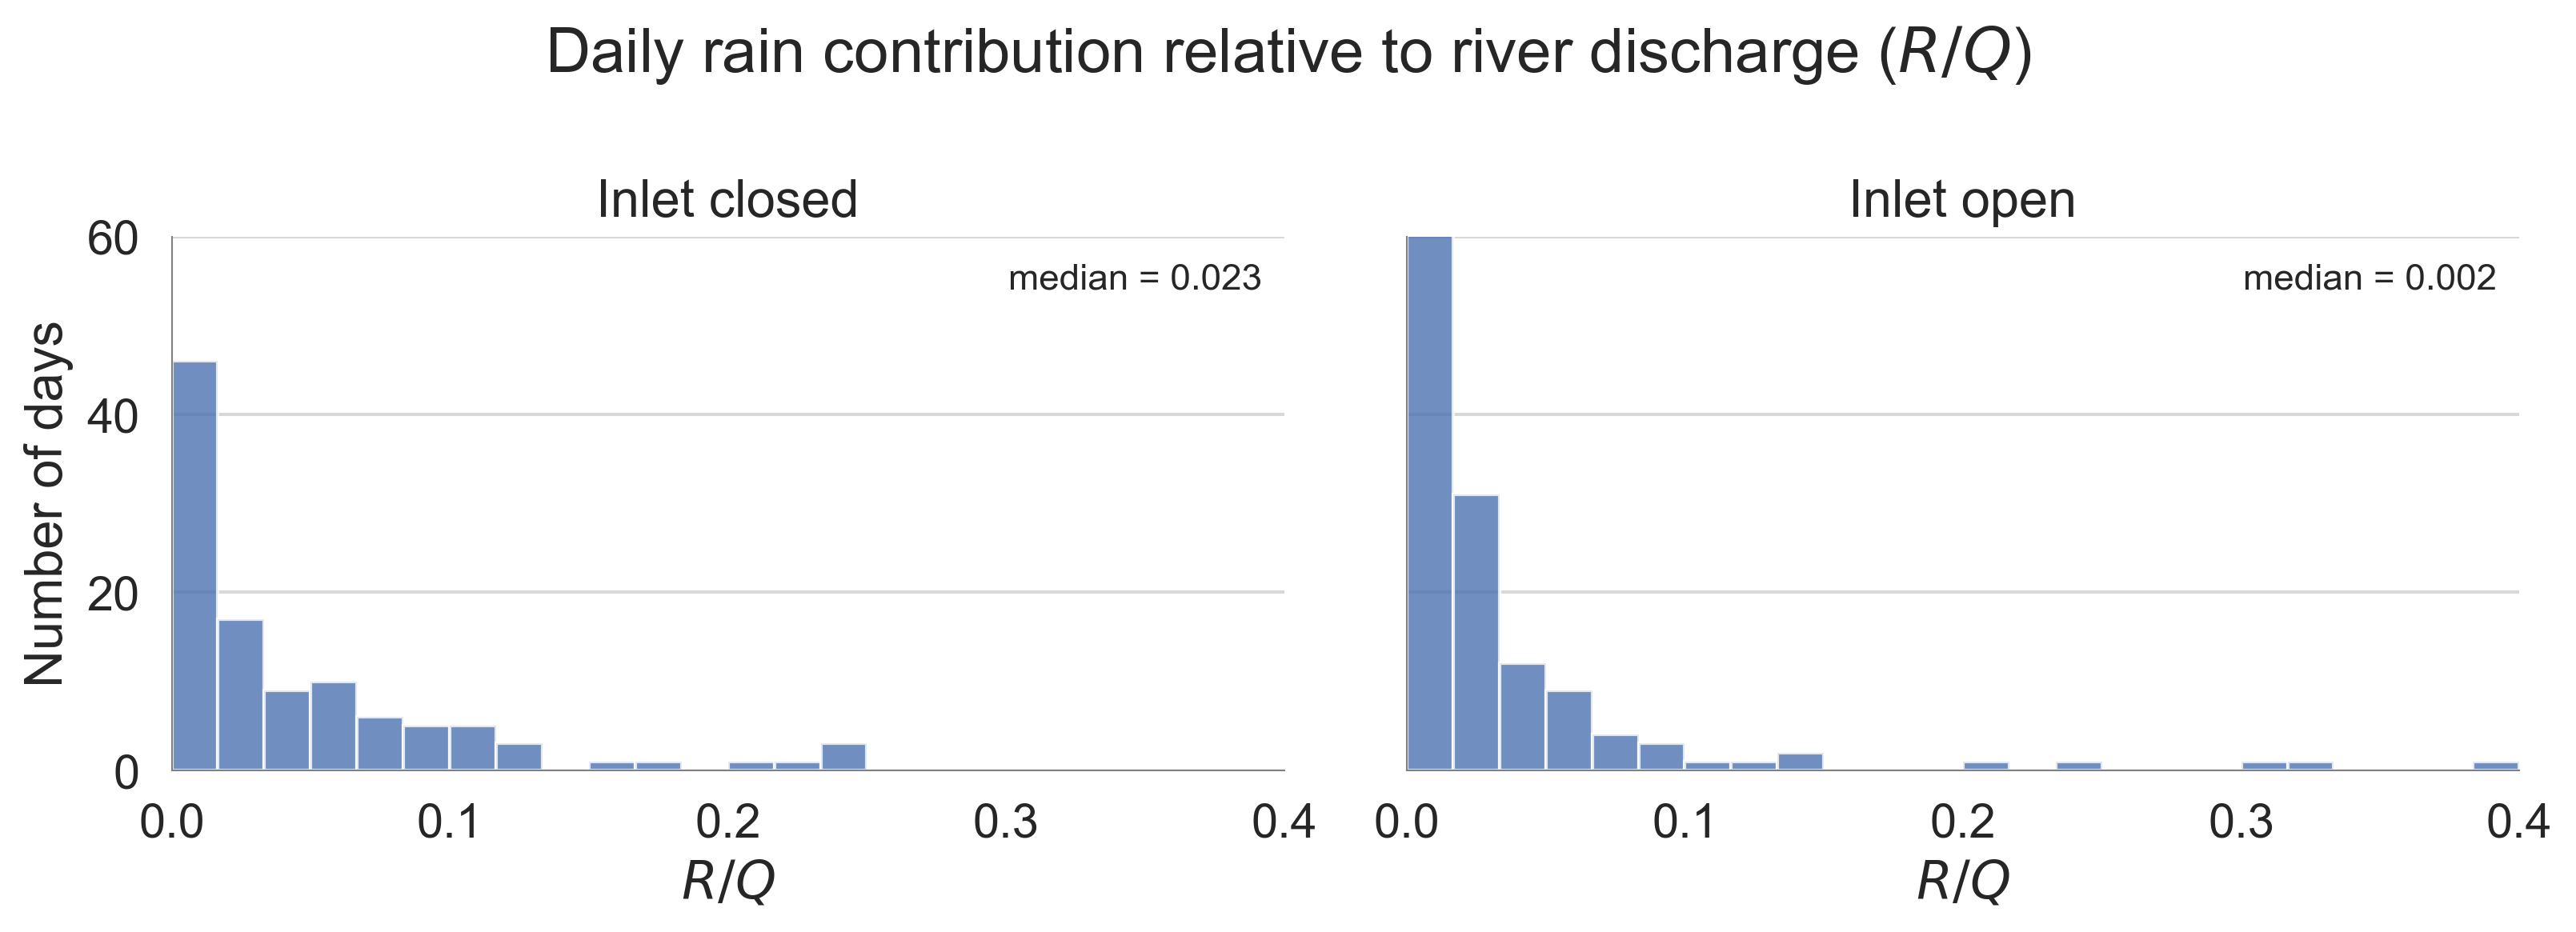

In [92]:
# R/Q on days with non-trivial rain
closed = merged_rain.query("State == 1 and rain > 0.001").copy()
open_  = merged_rain.query("State == 0 and rain > 0.001").copy()

rq_closed = closed["rain_m3s"] / closed["Q"]
rq_open   = open_["rain_m3s"] / open_["Q"]


xmax_plot = 0.4
bins = np.linspace(0, xmax_plot, 25)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
fig.suptitle("Daily rain contribution relative to river discharge ($R/Q$)")

for ax, data_raw, title in zip(
    axes,
    [rq_closed, rq_open],
    ["Inlet closed", "Inlet open"],
):
    # Clean data: drop NaNs / inf
    data = np.asarray(data_raw, float)
    data = data[np.isfinite(data)]

    if len(data) == 0:
        ax.text(
            0.5, 0.5, "no rainy days",
            transform=ax.transAxes,
            ha="center", va="center", fontsize=11
        )
        ax.set_title(title)
        ax.set_xlim(0, xmax_plot)
        continue

    # Clip to [0, xmax_plot] for plotting
    data_clipped = np.clip(data, 0, xmax_plot)
    ax.hist(data_clipped, bins=bins, edgecolor="white", alpha=0.8)

    # Tail count
    med = np.median(data)
    n_tail = int((data > xmax_plot).sum())
    lines = [f"median = {med:.3f}"]

    # Top-right annotation in axes coords
    ax.text(
        0.98, 0.95,
        "\n".join(lines),
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=11,
    )

    ax.set_title(title)
    ax.set_xlabel("$R/Q$")
    ax.set_xlim(0, xmax_plot)
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0,60)

axes[0].set_ylabel("Number of days")
plt.tight_layout()
plt.show()


In [93]:
merged.shape, merged_rain.shape

((421943, 25), (395882, 28))

In [94]:


visitor_patches = find_patches(list(merged_rain.State_visit))
visitor_inds = list(visitor_patches.keys())

USGS_patches = find_patches(list(merged_rain.State_USGS))
USGS_inds = list(USGS_patches.keys())

visitor_closures = get_visitor_closures(merged_rain)
# closures = get_visitor_closures(merged_rain)


# closure dates
merged_rain.iloc[visitor_inds[0]].date

datetime.date(2014, 9, 17)

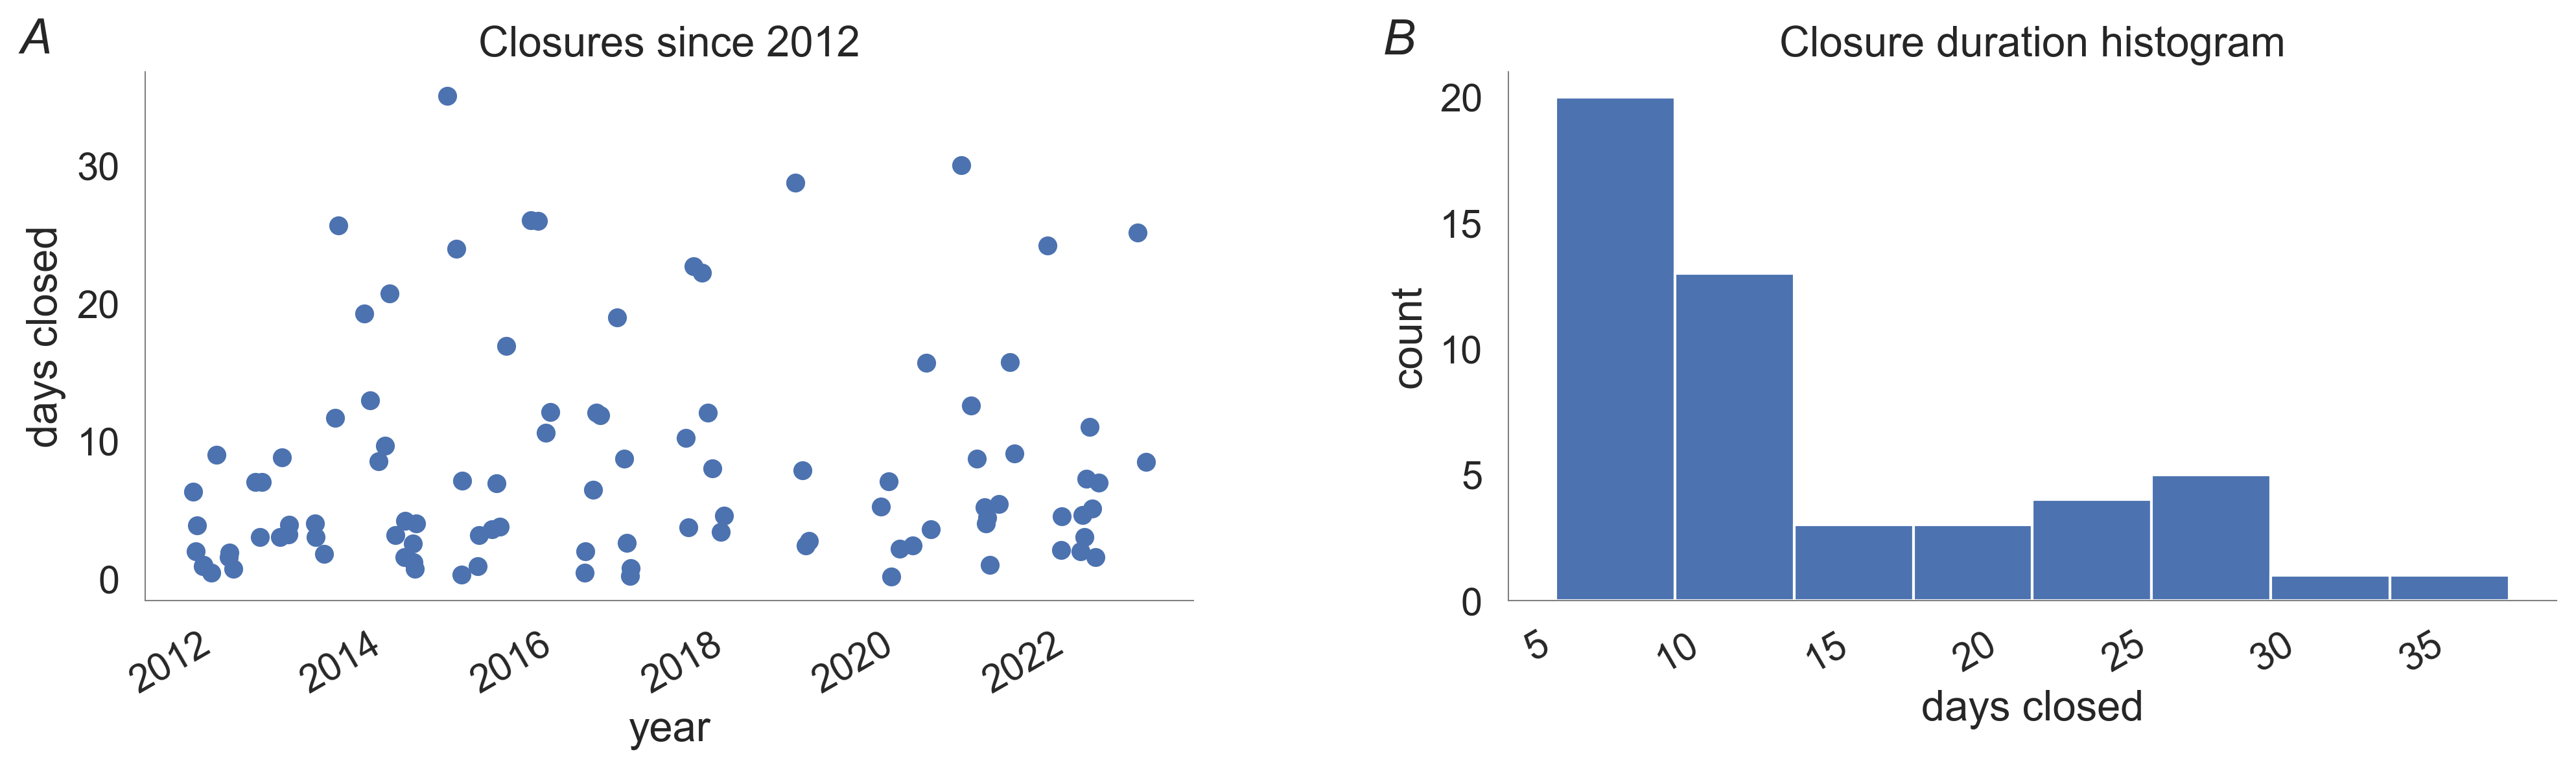

In [95]:


fig, axes = plt.subplots(1, 2, figsize = (16,4))
plt.subplots_adjust(wspace = 0.3)
ax = axes[0]
for key in visitor_patches.keys():
    ax.plot(merged_rain.iloc[key].name.date(), visitor_patches[key]/24/4, 'bo')
plt.gcf().autofmt_xdate()
ax.set_ylabel('days closed')
ax.set_xlabel('year')
ax.set_title("Closures since 2012")

ax = axes[1]
ax.hist(np.array(list(visitor_patches.values()))/24/4, np.arange(5, 40, 4))
ax.set_ylabel("count")
ax.set_xlabel("days closed")
ax.set_title("Closure duration histogram")

axes[0].text(-0.12, 1.1, 'A', transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');

axes[1].text(-0.12, 1.1, 'B', transform=axes[1].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');

## Hourly analysis

In [96]:
ind = 1
subset = get_subset(merged_rain, ind, 0, 0)
hourly_subset = get_hourly_visitor(subset)

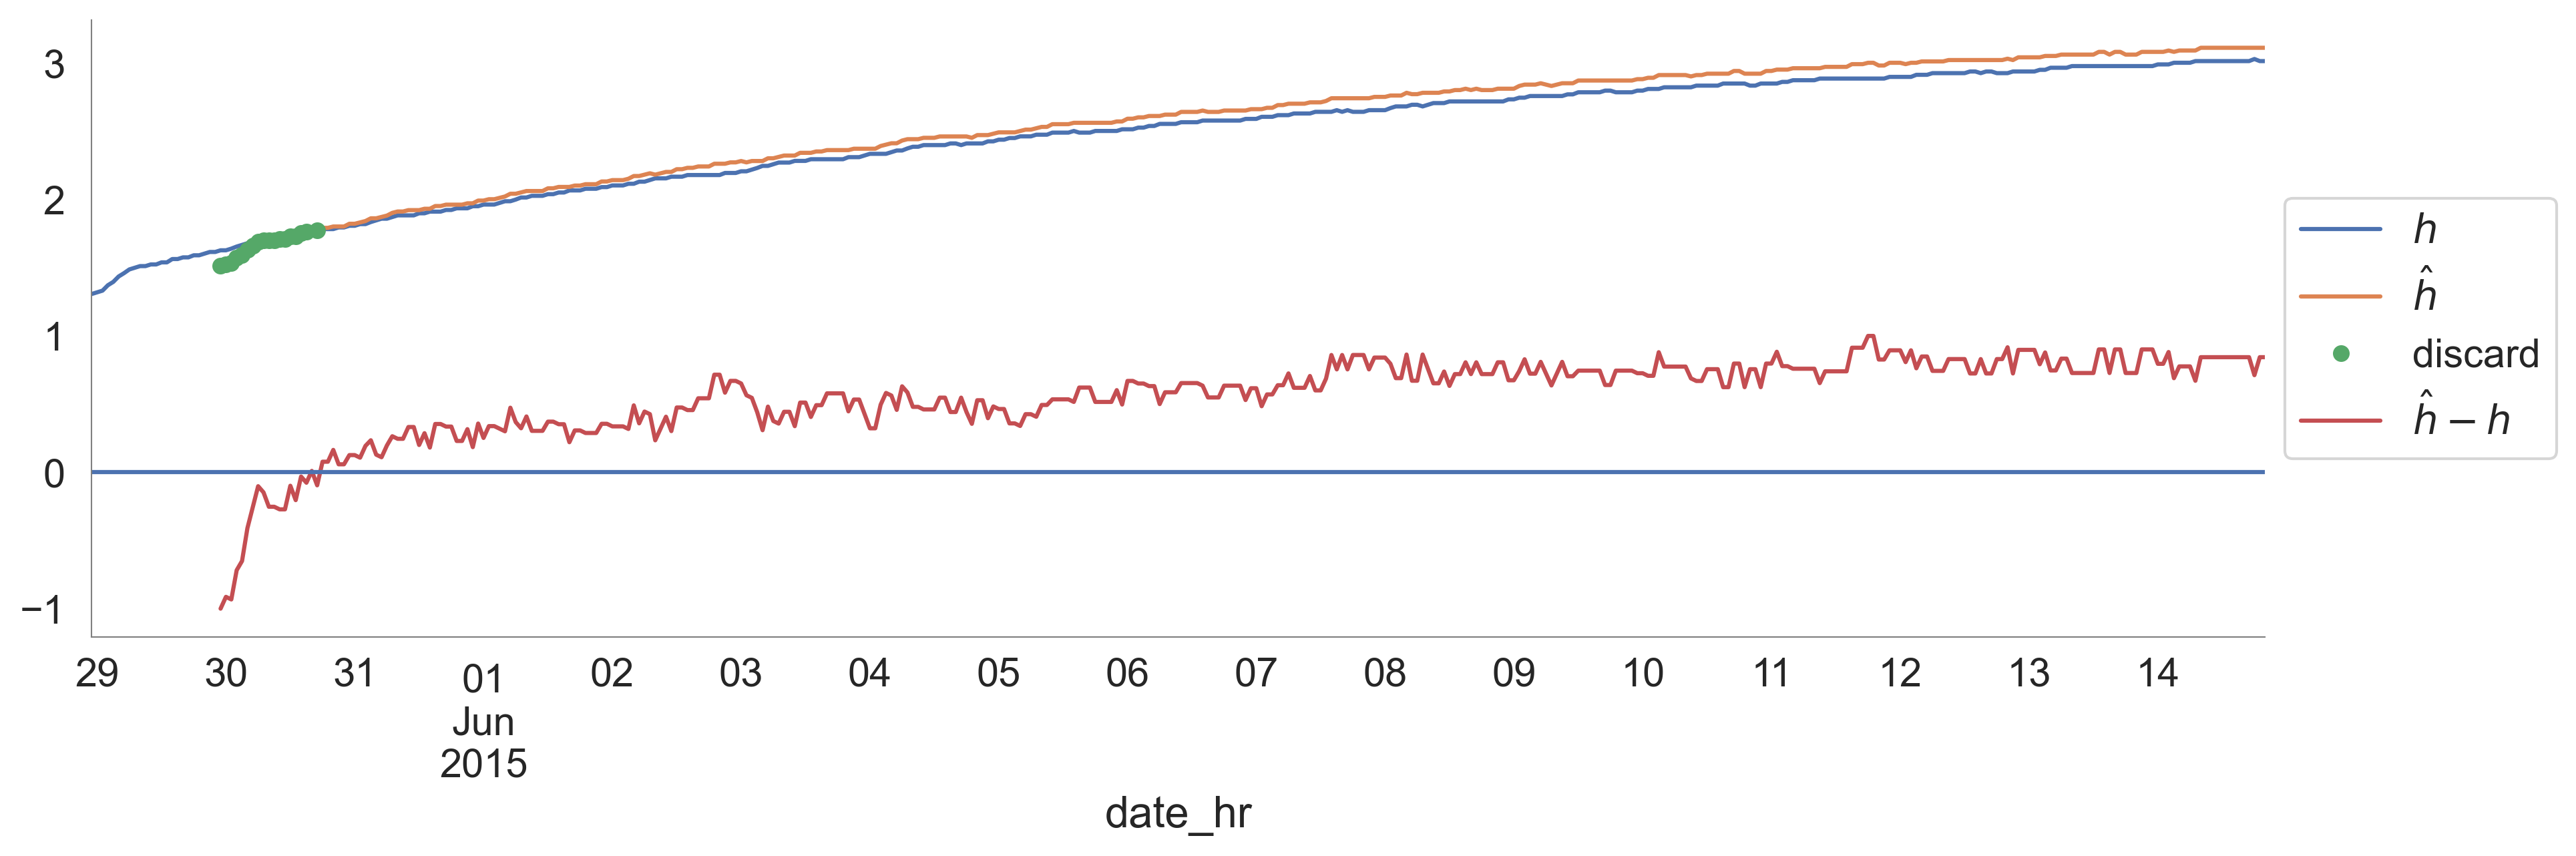

In [97]:
def plot_overwash_discard(merged, ind):

    subset = get_subset(merged, ind, 0, 0 )
    hourly_subset = get_hourly_visitor(subset).query("State_visit == 1")

    # keep indices where predicted h > observed h
    keep = hourly_subset[(hourly_subset[ 'visitor_h_Q']- hourly_subset['visitor_filled']) >  -0.0].index
    # discard indices where predicted h < observed h
    discard = hourly_subset[(hourly_subset[ 'visitor_h_Q']- hourly_subset['visitor_filled']) < -0.0].index

    fig, ax = plt.subplots(1, figsize = (14,4))
    rename = {"visitor_filled" : "$h$", "visitor_h_Q" : "$\hat h$"}
    hourly_subset[['visitor_filled', 'visitor_h_Q']].rename(rename, axis = 1).plot(ax =ax)

    if len(discard) > 0:
        hourly_subset.loc[discard][[ 'visitor_h_Q']].rename(
            {"visitor_h_Q": "discard"}, axis = 1).plot(marker = 'o', ms = 5, ls = '', ax = ax)

    (hourly_subset[['h_hat_minus_h']].apply(scale_series, maxval = 1)).rename(
        {"h_hat_minus_h": "$\hat h - h$"}, axis = 1).plot(ax =ax)

    
    ax.axhline(0)

    ax.legend(title = '', loc='center left', bbox_to_anchor=(1, 0.5))

    
plot_overwash_discard(merged_rain, 14)

In [98]:
# Get data for 12 closure, 
subset = get_subset(merged_rain, ind = 12, prev = 0, post = 0)

hourly_subset = get_hourly_visitor(subset).query("State_visit == 1")

daily_subset = get_daily_subset(subset, include_USGS = 0, periods = 1)
daily_subset.index.date[[0, -1]]

array([datetime.date(2013, 9, 26), datetime.date(2013, 10, 16)],
      dtype=object)

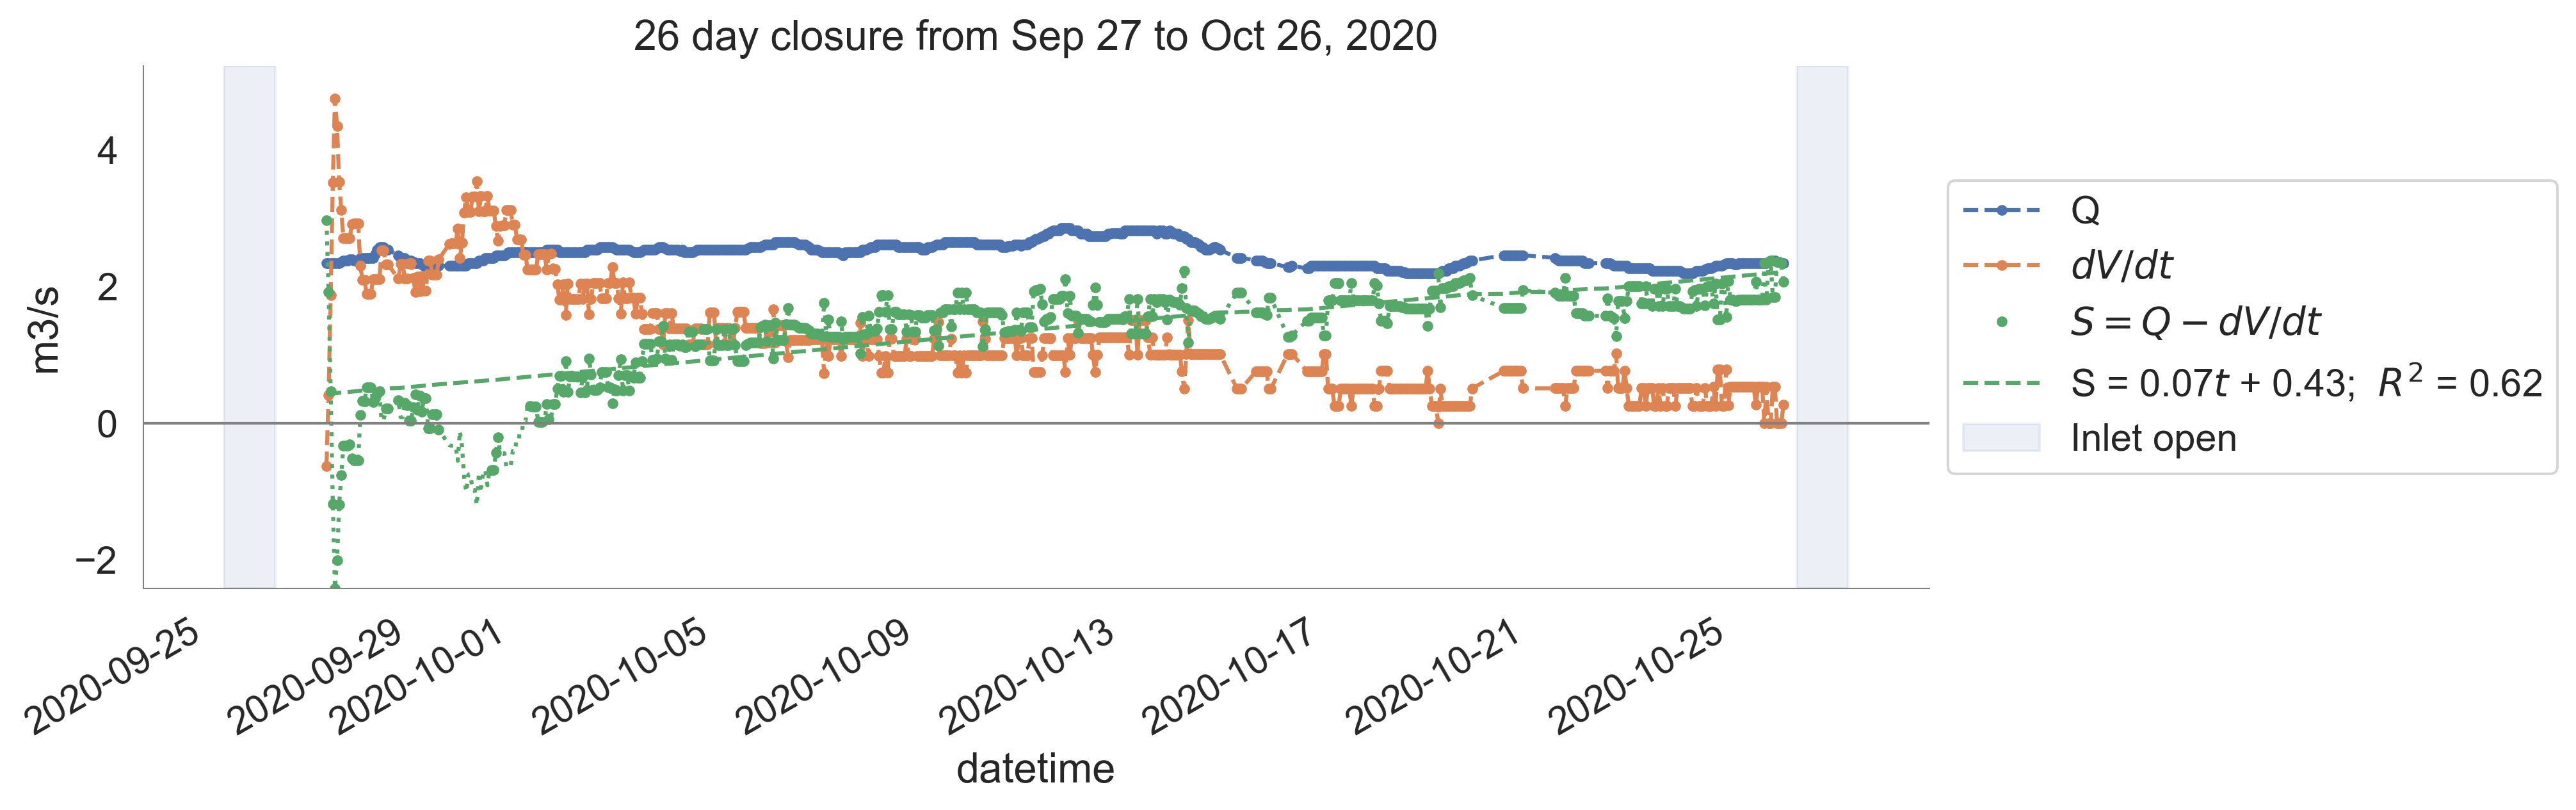

In [99]:
ind = 1

subset =  get_subset(merged_rain, ind, 0, 0)

fig, ax = plt.subplots( 1, figsize = (12, 4))
plt.subplots_adjust(hspace = 0.35)
plot_mass_bal_hourly(merged_wave,  ind, padding  = 1, logscale = False, ax = ax);

## Mass balance plots

###  Diagnostic plots

In [100]:
def hide_axes(ax):
    # Hide the spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Hide the ticks and labels
    ax.set_xticks([])
    ax.set_yticks([])


def plot_mass_bal_visit(merged_case, ind, ax, padding = 10, logscale = 1,
                        legend_loc = "outside", regression_line = True):
    """
    Plot daily mass-balance terms for a single closure event
    using Visitor Center hypsometry.

    Shows river inflow Q, storage-change dV/dt, and inferred
    seepage S = Q - dV/dt, with an optional regression of S
    against time (days since closure).
    """
    subset = get_subset(merged_case, ind, padding, padding)
    closure_subset = get_subset(merged_case, ind, 0, 0)

    daily_subset = get_daily_subset(closure_subset)
    daily_subset["date"] = daily_subset.index.date
    daily_subset["day"]  = np.arange(len(daily_subset))  # days since closure start

    # fixes x-axis limits (invisible background series)
    subset[["v"]].rename({"v" : ""}, axis = 1).plot(ax = ax, visible = False)

    # Closure days (for ylim)
    closed = daily_subset["State_visit"] > 0
    closed = daily_subset[closed].index

    # Q(t)
    daily_subset["Q"].plot(secondary_y = False, xlabel = "Time",
                           style = "C0.--", legend = True, ax = ax,
                           label = r"$Q$")

    # dV/dt(t)
    daily_subset["dvol/dt_visitor_filled"].plot(xlabel = "Time",
                                                style = "C1.--", alpha = 0.7,
                                                ax = ax, label = r"$dV/dt$")

    # S(t) = Q - dV/dt (all days)
    daily_subset["seepage_visitor"].plot(xlabel = "Time",
                                         style = "C2:.", ax = ax, label = "")

    # Exclude overtopping days for positive seepage regressio
    lose       = filter_overtop(closure_subset, minval = minval)
    pos_subset = daily_subset[~(daily_subset.date).isin(lose)]
    pos_subset = pos_subset[["day", "date", "seepage_visitor"]].dropna()
    pos_subset = pos_subset.query("seepage_visitor > 0")

    # Positive seepage points (no overtopping)
    if len(pos_subset) > 0:
        pos_subset["seepage_visitor"].plot(xlabel = "Time", style = "C2o",
                                           ms = 6, ax = ax,
                                           label = r"$S = Q + P \cdot A-  dV/dt$")

    # Optional regression of S vs time (days since closure)
    if len(pos_subset) > 0 and regression_line:
        X = pos_subset[["day"]]
        y = pos_subset["seepage_visitor"]
        (predictions, slope, intercept, r_squared,
         t_value, CI_low, CI_high, residuals) = fit_Xy(X, y, fit_intercept = True)

        pos_subset["predictions"] = predictions
        reg_label = rf"$S = {slope:.2f}\,t + {intercept:.2f}$"

        pos_subset["predictions"].plot(style = "C2--", ax = ax, label = reg_label)

    ax.axhline(0, c = "grey", lw = 1)

    ymin, ymax = get_ylim_visitor(daily_subset.loc[closed])
    ax.set_ylim(ymin, ymax)
    ax.yaxis.set_major_locator(MaxNLocator(5))
    ax.set_ylabel(r"Water-budget terms (m$^3$ s$^{-1}$)")
    ax.set_xlabel("$t$ (days since closure)")

    # Add shading wherever power_12_hour is less than threshold
    for start, end in get_shading_regions(subset["State_visit"], 0.2)[1:]:
        ax.axvspan(start, end, color = "C0", alpha = 0.1)

    for start, end in get_shading_regions(subset["State_visit"], 0.2)[:1]:
        ax.axvspan(start, end, color = "C0", alpha = 0.1, label = "")

    if legend_loc == "outside":
        ax.legend(title = "", loc = "center left", bbox_to_anchor = (1, 0.5))
    else:
        ax.legend(title = "", loc = legend_loc)

    ax.set_xlabel("")
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval = 1))
    date_form = DateFormatter("%m-%d")
    ax.xaxis.set_major_formatter(date_form)

    return ax


def plot_12hr_visit(merged_case, ind, ax, legend_loc = "outside",
                    padding = 10, wind = False, wave = False):
    """
    Plot estuary and ocean water levels (and optionally waves or wind)
    for a single closure event, at daily resolution.
    """
    subset         = get_subset(merged_case, ind, padding, padding)
    closure_subset = get_subset(merged_case, ind, 0, 0)

    daily_subset = get_daily_subset(closure_subset, periods = 1)
    closed       = daily_subset.index

    if wave:
        subset[["visitor_filled", "v", "waveHs"]].rename(
            {"visitor_filled" : "", "v" : "", "waveHs" : "", "wind" : ""}, axis = 1
        ).plot(c = "grey", alpha = 0.6, ax = ax, linewidth = 1)

        daily_subset[["waveHs"]].rename({"waveHs" : "wave height"}, axis = 1
        ).plot(c = "green", alpha = 1, ax = ax, linewidth = 1)

    elif wind:
        subset[["visitor_filled", "v"]].rename(
            {"visitor_filled" : "", "v" : "", "wind" : ""}, axis = 1
        ).plot(c = "grey", alpha = 0.6, ax = ax, linewidth = 1)

        (daily_subset[["wind"]] / 10).rename({"wind" : "wind"}, axis = 1
        ).plot(c = "green", alpha = 1, ax = ax, linewidth = 1)

    else:
        subset[["visitor_filled", "v"]].rename(
            {"visitor_filled" : "", "v" : "", "wind" : ""}, axis = 1
        ).plot(c = "grey", alpha = 0.6, ax = ax, linewidth = 1)

    daily_subset[["visitor_filled", "v"]].rename(
        {"visitor_filled" : "Estuary $h$", "v" : "Ocean $h_{ocn}$"}, axis = 1
    ).plot(ax = ax, marker = ".", linestyle = "--", linewidth = 1)

    ax.set_ylabel("m (NAVD88)")
    ax.yaxis.set_major_locator(MaxNLocator(5))

    # Add shading wherever power_12_hour is less than threshold
    for start, end in get_shading_regions(subset["State_visit"], 0.2)[1:]:
        ax.axvspan(start, end, color = "C0", alpha = 0.1)

    for start, end in get_shading_regions(subset["State_visit"], 0.2)[:1]:
        ax.axvspan(start, end, color = "C0", alpha = 0.1, label = "")

    if legend_loc == "outside":
        ax.legend(title = "", loc = "center left", bbox_to_anchor = (1, 0.5))
    else:
        ax.legend(title = "", loc = legend_loc)

    ax.set_ylim(ax.get_ylim()[0] * 0.5 - 0.1, ax.get_ylim()[1])

    ax.set_xlabel("")
    title = "{0} day closure from {1} to {2}".format(
        len(closed),
        closed[0].date().strftime("%b %d"),
        closed[-1].date().strftime("%b %d, %Y")
    )

    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval = 1))
    date_form = DateFormatter("%m-%d")
    ax.xaxis.set_major_formatter(date_form)

    return title, len(closed)


def plot_visitor_scatter(merged_case, ind, ax, offset = 0, power = 1):
    """
    Plot S vs Δh for a single closure event using Visitor Center
    mass-balance seepage estimates, with two regressions:
    all days (S+O) and positive seepage without overtopping (S).
    """
    subset = get_subset(merged_case, ind, 0, 0)

    daily_subset = get_daily_subset(subset, periods = 1).query("seepage_visitor < 4.5")

    daily_subset["seepage"]      = daily_subset["seepage_visitor"]
    daily_subset["State_visit"]  = daily_subset["State_visit"].apply(np.floor)
    daily_subset["delta_h"]      = daily_subset.visitor_filled - daily_subset.v
    daily_subset                 = daily_subset[["seepage", "delta_h", "waveHs"]].dropna()
    daily_subset["date"]         = daily_subset.index.date

    # All days (S + O)
    ax.scatter(daily_subset["delta_h"], daily_subset["seepage"], label = "", s = 40)

    X = daily_subset[["delta_h"]] 
        # (daily_subset[["delta_h"]] + offset) ** power).values.reshape(-1, 1)
    y = daily_subset["seepage"]

    if len(X) > 0:
        (predictions, slope, intercept, r_squared,
         t_value, CI_low, CI_high, residuals) = fit_Xy(X, y)

        ax.plot(daily_subset["delta_h"], predictions, color = "C0",alpha = 0.6, 
                 label = r"All days; $S + O = C_L\,\Delta h$"
               # label = r"All days; $S + O = C_L\,\Delta h$"
               )

    # Exclude overtopping and negative S
    lose       = filter_overtop(subset, minval = minval)
    pos_subset = daily_subset[~(daily_subset.date).isin(lose)]
    pos_subset = pos_subset.query("seepage > 0")

    if len(pos_subset) > 0:
        X = pos_subset[["delta_h"]]
        y = pos_subset["seepage"]
        (predictions, slope, intercept, r_squared,
         t_value, CI_low, CI_high, residuals) = fit_Xy(X, y)

        ax.scatter(pos_subset["delta_h"], pos_subset["seepage"], label = "", s = 15)

        ax.plot(pos_subset["delta_h"], predictions, color = "C1",
                label = r"Non-overwash days; $S = C_L\,\Delta h$")

    #ax.set_ylabel(r"$S = Q - dV/dt$  (m$^3$ s$^{-1}$)")
    ax.set_ylabel(r"Seepage (m$^3$ s$^{-1}$)")

    ax.set_xlabel(r"$\Delta h$ (m)")
    ax.legend(loc = "upper left")
    ax.set_xlim(0, )
    ax.axhline(0, c = "k", lw = 1)

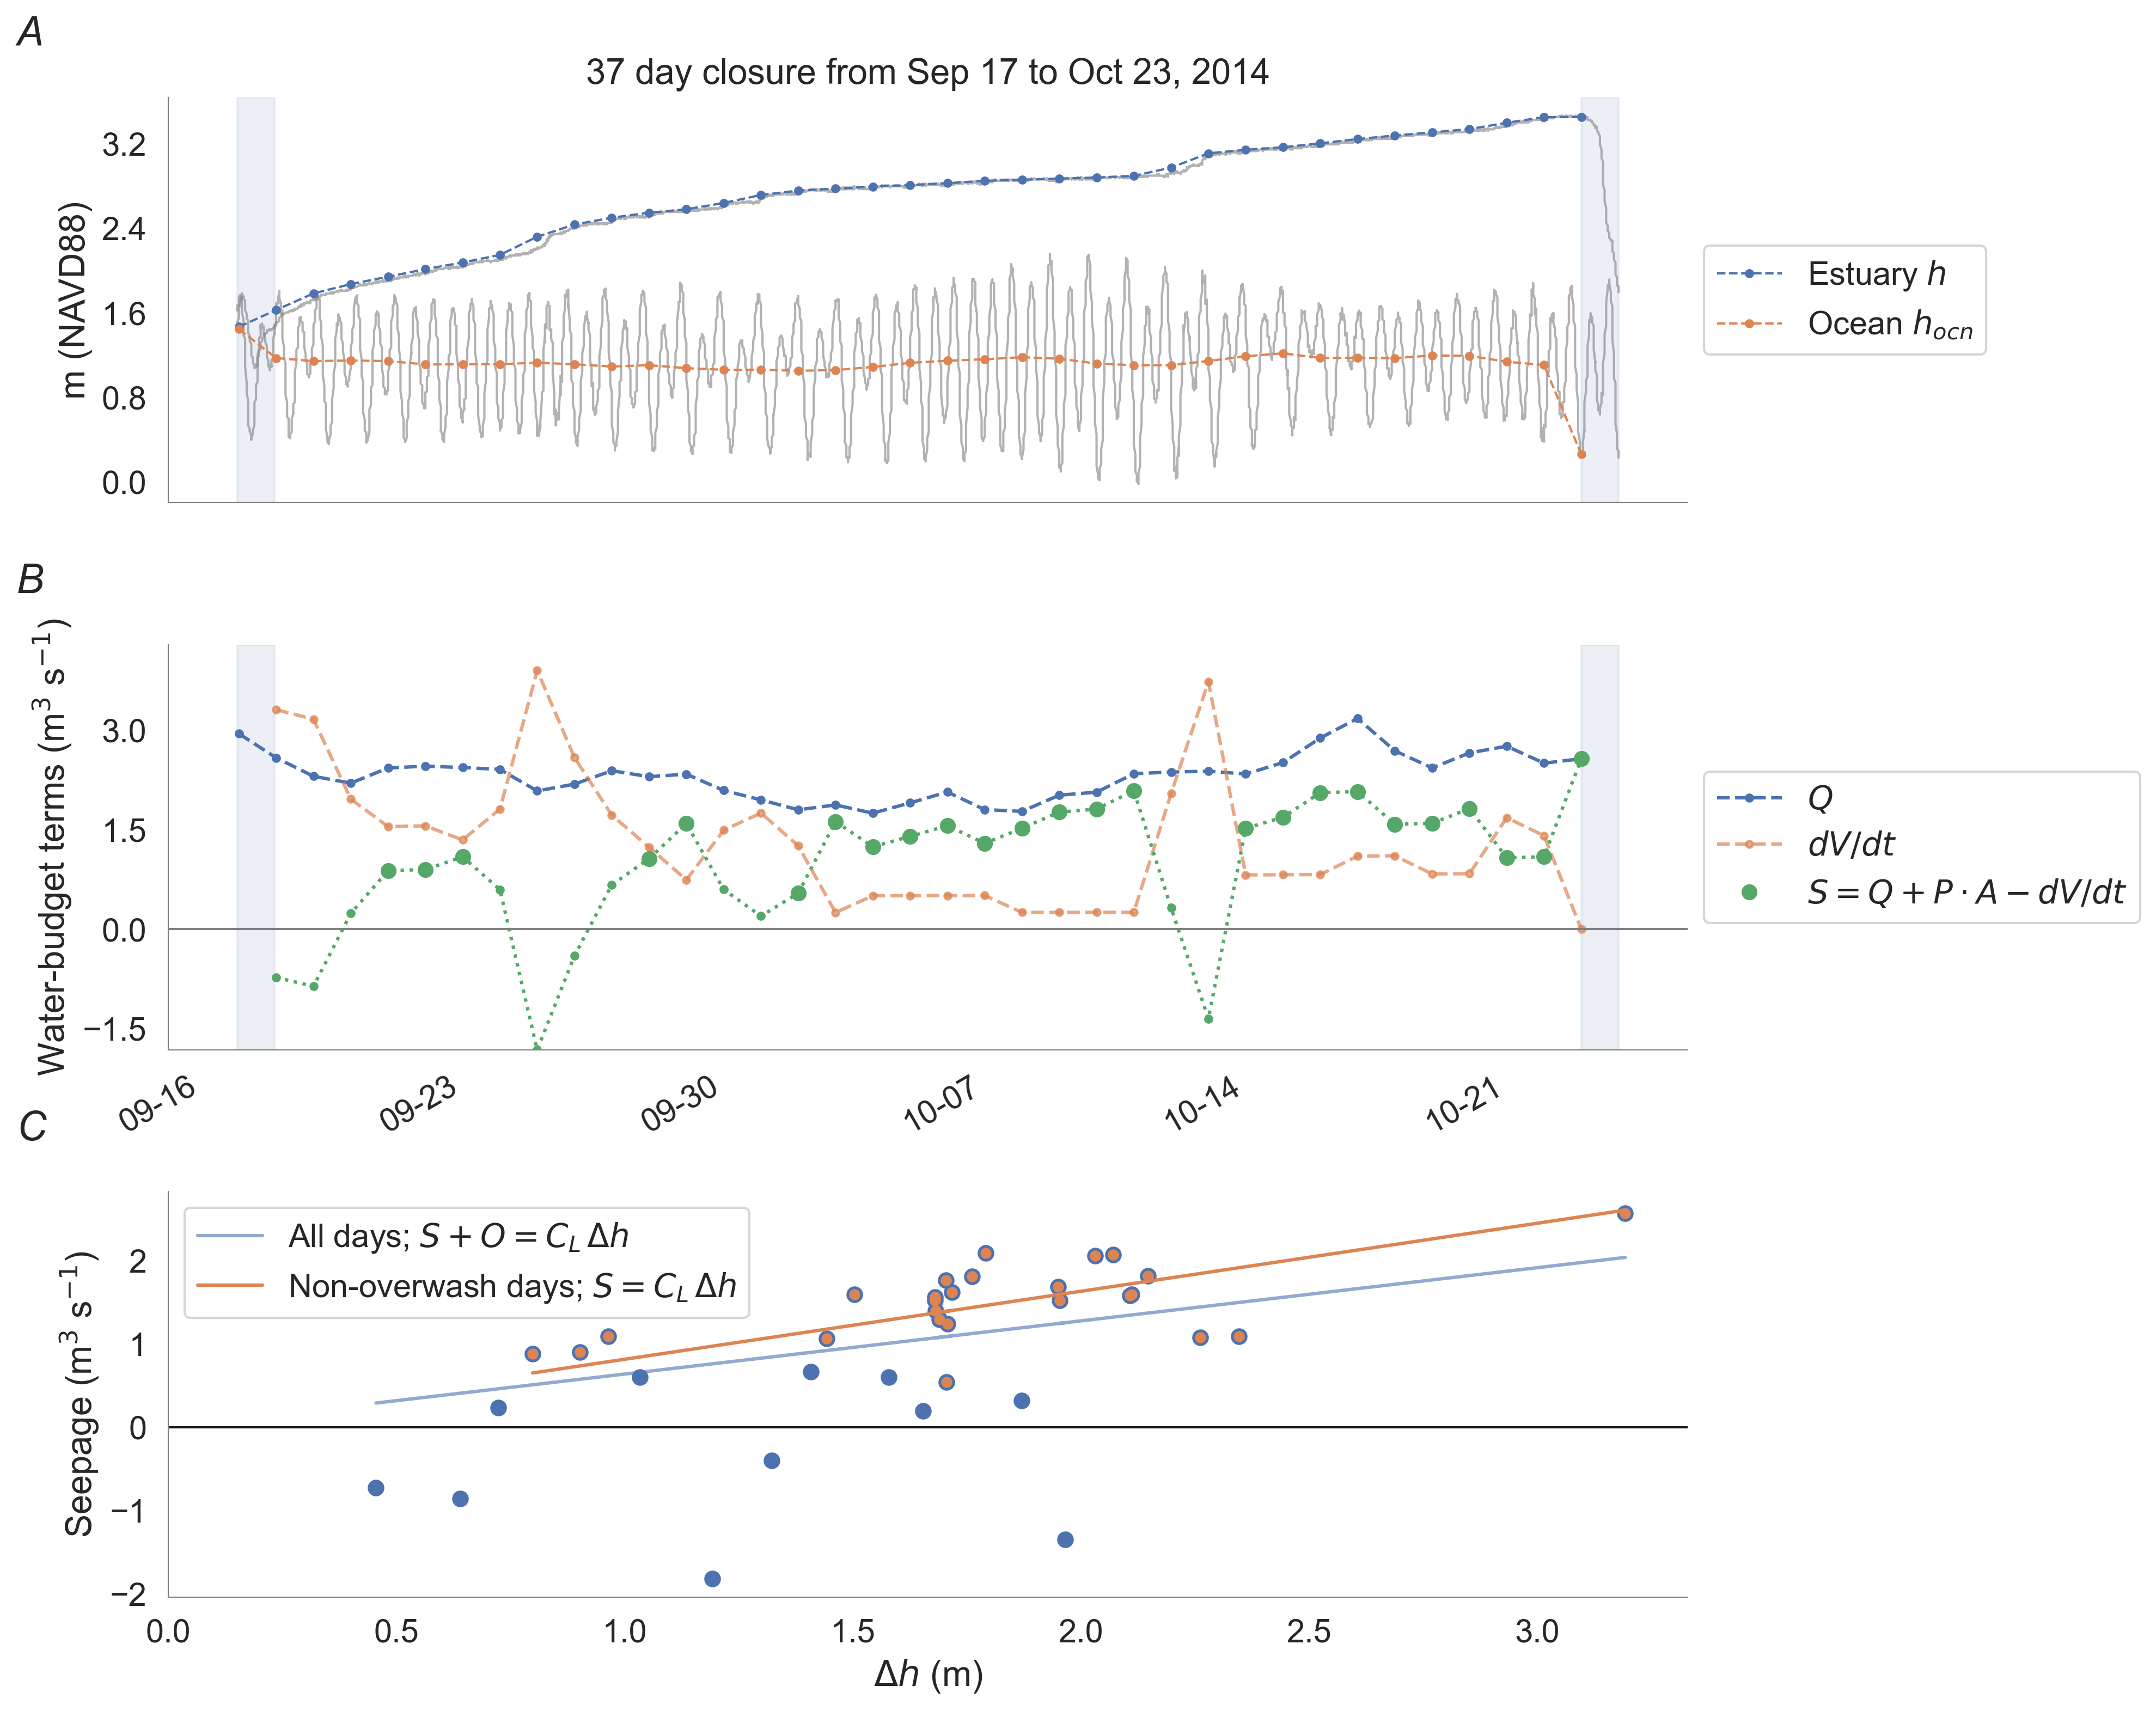

In [101]:
# ── Driver: plot one closure event per iteration ──────────────────────────────
ind          = 0
merged_case  = merged_rain
minval = 0.01
for ind in range(1):
    subset = get_subset(merged_case, ind, 0, 0)

    fig, axes = plt.subplots(3, 1, figsize = (12, 13.5))
    plt.subplots_adjust(hspace = 0.35)

    title, duration = plot_12hr_visit(merged_case, ind, axes[0],
                                      wind = False, padding = 1)

    plot_mass_bal_visit(merged_case, ind, padding = 1, logscale = False,
                        regression_line = False, ax = axes[1])

    plot_visitor_scatter(merged_case, ind, axes[2], offset = 0.5, power = 0.5)

    axes[0].text(-0.1, 1.2, "A", transform = axes[0].transAxes,
                 ha = "left", va = "top", fontsize = 18, style = "italic")
    axes[0].set_title(title)

    axes[1].text(-0.1, 1.2, "B", transform = axes[1].transAxes,
                 ha = "left", va = "top", fontsize = 18, style = "italic")
    axes[2].text(-0.1, 1.2, "C", transform = axes[2].transAxes,
                 ha = "left", va = "top", fontsize = 18, style = "italic")

    axes[0].set_xticks([])
    date = f"{subset.iloc[0].name.year}-{subset.iloc[0].name.month}"

    plt.savefig(root / f"figures/visitor_closures/{duration}days__{subset.iloc[0].name.date()}.png",
                bbox_inches = "tight")


In [102]:
subset =  get_subset(merged_rain, 0, 0, 0)
daily_subset = get_daily_subset(subset, periods = 1)

In [103]:
daily_subset['seepage_visitor'].sum()/(daily_subset['Q']).sum()

0.4072030175924785

In [104]:
merged_rain.shape, merged_wave.shape

((395882, 28), (395882, 27))

In [105]:
# -----------------------------------------------------------------------------
# Build a pooled, event-labeled panel of daily records
# - Stacks all days from all events into one DataFrame (no aggregation).
# - Applies standard filters:
#       * keep days with seepage_visitor < 5 (screen out suspect values)
#       * drop rows with NaNs in key fields
#       * remove dates flagged as overtopping (via filter_overtop)
#       * keep only positive seepage
# - Computes Δh = visitor_filled - v
# - Labels each row with its event index for later fixed/random-effects modeling
#   (e.g., OLS with C(event) or mixed models with random intercepts).
# -----------------------------------------------------------------------------

merged_case = merged_rain
pooled_event_df = pd.DataFrame()

def filter_outliers(pooled_event_df, k=1.5):
    """
    Filter outliers using Tukey's IQR fences (Q1 - k*IQR, Q3 + k*IQR)
    for: delta_h, seepage, and seepage/delta_h.
    """
    df = pooled_event_df.copy()

    def iqr_bounds(s):
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        if (not np.isfinite(iqr)) or iqr == 0:
            return None  # nothing sensible to filter
        return q1 - k * iqr, q3 + k * iqr

    # 1) delta_h fences
    b = iqr_bounds(df["delta_h"])
    if b is not None:
        lo, hi = b
        df = df[df["delta_h"].between(lo, hi)]

    # 2) seepage fences
    b = iqr_bounds(df["seepage"])
    if b is not None:
        lo, hi = b
        df = df[df["seepage"].between(lo, hi)]

    # 3) seepage/delta_h fences (drop inf/NaN ratios)
    ratio = df["seepage"].div(df["delta_h"]).replace([np.inf, -np.inf], np.nan).dropna()
    if len(ratio) > 0:
        b = iqr_bounds(ratio)
        if b is not None:
            lo, hi = b
            df = df.loc[ratio[ratio.between(lo, hi)].index]
        else:
            # if no bounds, still remove rows with undefined ratio
            df = df.loc[ratio.index]

    return df

for ind in range(N_VISITOR_EVENTS):
    subset =  get_subset(merged_case, ind, 0, 0)
    
    # Daily rollup + initial screen
    daily_subset = (get_daily_subset(subset, periods = 1)
#         .query("seepage_visitor < 5")
        .copy())

    # Prepare fields
    daily_subset["seepage"] = daily_subset["seepage_visitor"]
    daily_subset["State_visit"] = np.floor(daily_subset["State_visit"])
    
    # Calculate Δh
    daily_subset["delta_h"] = daily_subset["visitor_filled"] - daily_subset["v"]
    daily_subset = daily_subset[["seepage", "delta_h", "waveHs", "visitor_h", 'Q', 'rain_vol']].dropna()
    daily_subset["date"] = daily_subset.index.date


    # Remove overtopping dates
    lose = filter_overtop(subset, minval=0.0)
    
    if lose is None:
        lose = []
    
    pos_subset = daily_subset[~daily_subset["date"].isin(lose)]
    pos_subset = pos_subset.query("seepage > 0 ").copy()

 
    pos_subset["event"] = ind
    if len(pos_subset) >= 1:
        pooled_event_df = pd.concat([pooled_event_df, pos_subset], axis=0)


pooled_event_df = filter_outliers(pooled_event_df)

pooled_event_df["n"] = pooled_event_df.groupby("event")["event"].transform("size").astype("int64")        
pooled_event_df = pooled_event_df.query("n >= 5")
pooled_event_df.to_csv(data_path / "processed/pooled_event_df.csv")    



In [106]:
IQR = np.percentile(pooled_event_df.seepage, 75)  - np.percentile(pooled_event_df.seepage, 25)
max_threshold = np.percentile(pooled_event_df.seepage, 75)   + 1.5*IQR

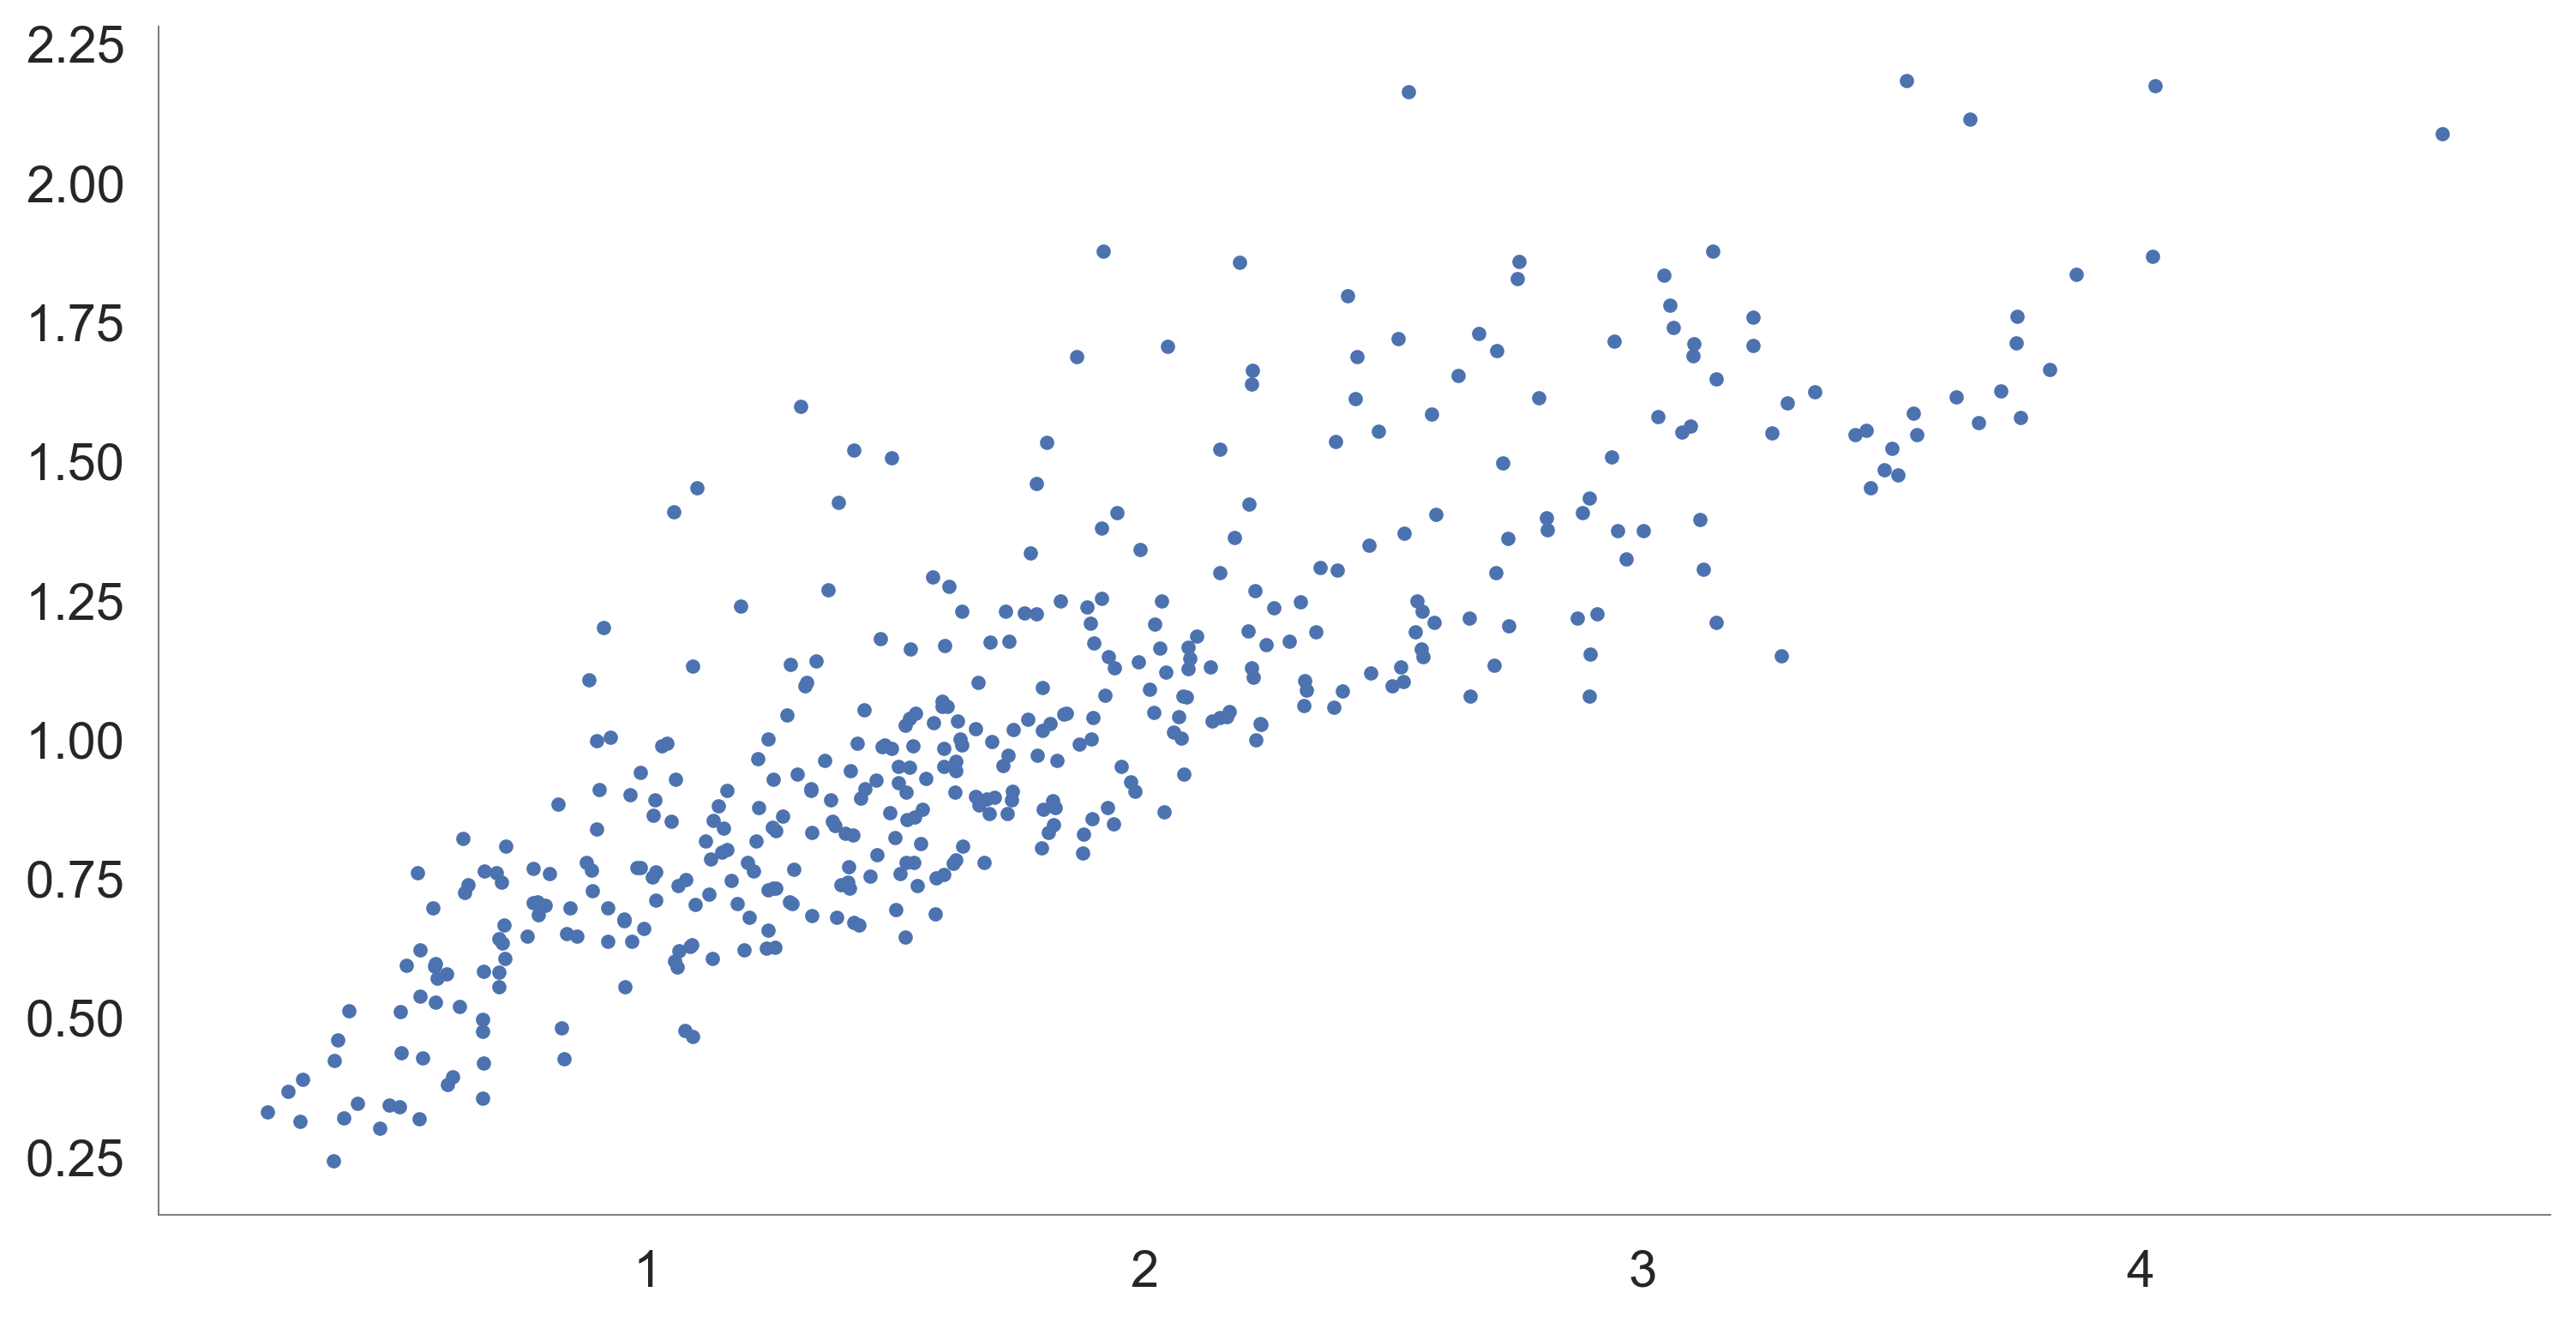

In [107]:
plt.plot(pooled_event_df['seepage'], pooled_event_df['seepage']/pooled_event_df['delta_h'], '.')

In [108]:
# exploratory stats
print('max_threshold (IQR):', max_threshold)
print('seepage/delta_h std:', (pooled_event_df['seepage']/pooled_event_df['delta_h']).std())
print('3*std, mean:', 3*pooled_event_df.seepage.std(), pooled_event_df.seepage.mean())
print('seepage max:', pooled_event_df.seepage.max())
print('shape:', pooled_event_df.shape)


max_threshold (IQR): 3.8492690435167667
seepage/delta_h std: 0.3759035394904027
3*std, mean: 2.507823526817463 1.7358267292587992
seepage max: 4.606372962314489
shape: (419, 9)


In [109]:
df = pooled_event_df
# make sure 'date' is datetime (if it's not already)
df["date"] = pd.to_datetime(df["date"])

# add year and month (numeric)
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

# optional: month as a name
df["month_name"] = df["date"].dt.month_name()


In [110]:
mask = (merged["visitor_12_hr"] > 0.29) & (merged["State_visit"] == 1)

cand = pd.to_datetime(merged.loc[mask, "date"], errors="coerce").dt.normalize()
pool = pd.to_datetime(pooled_event_df["date"], errors="coerce").dt.normalize()

# drop unparseable values (NaT)
cand = cand.dropna()
pool = pool.dropna()

present_dates = pd.Index(cand.unique()).intersection(pool.unique()).to_numpy()


In [111]:

# your string
s = "201312301700"

# parse to UTC timestamp
ts = pd.to_datetime(s, format = "%Y%m%d%H%M", utc = True)
print(ts)
# 2013-12-30 17:10:00+00:00
row = merged_wave.loc[ts]   # KeyError if 17:10 isn't in the index


2013-12-30 17:00:00+00:00


In [112]:
len(merged_wave.index.unique()), len(merged_wave)

(393911, 395882)

In [113]:
pooled_event_df.sort_values('waveHs')

,seepage,delta_h,waveHs,visitor_h,Q,rain_vol,date,event,n,year,month,month_name
date,,,,,,,,,,,,
2014-01-17,1.117378,1.367003,0.179811,2.377440,2.973727,0.000000,2014-01-17,11,10,2014,1,January
2014-01-18,1.150043,1.442823,0.184596,2.448084,2.831777,0.000000,2014-01-18,11,10,2014,1,January
2013-12-28,1.527049,1.609946,0.202759,2.635728,4.502079,0.000000,2013-12-28,27,5,2013,12,December
2014-01-16,0.920849,1.320791,0.217120,2.298541,2.989375,0.000000,2014-01-16,11,10,2014,1,January
2018-11-10,2.967608,2.242388,0.226642,3.345527,3.246717,0.000000,2018-11-10,2,27,2018,11,November
...,...,...,...,...,...,...,...,...,...,...,...,...
2015-09-12,0.630592,0.767740,0.833652,1.907699,1.952414,0.000000,2015-09-12,3,23,2015,9,September
2014-10-07,1.294258,1.689600,0.834190,2.850266,1.802544,0.000000,2014-10-07,0,28,2014,10,October
2015-09-11,0.539461,0.710525,0.918748,1.852994,1.849146,4.996600,2015-09-11,3,23,2015,9,September


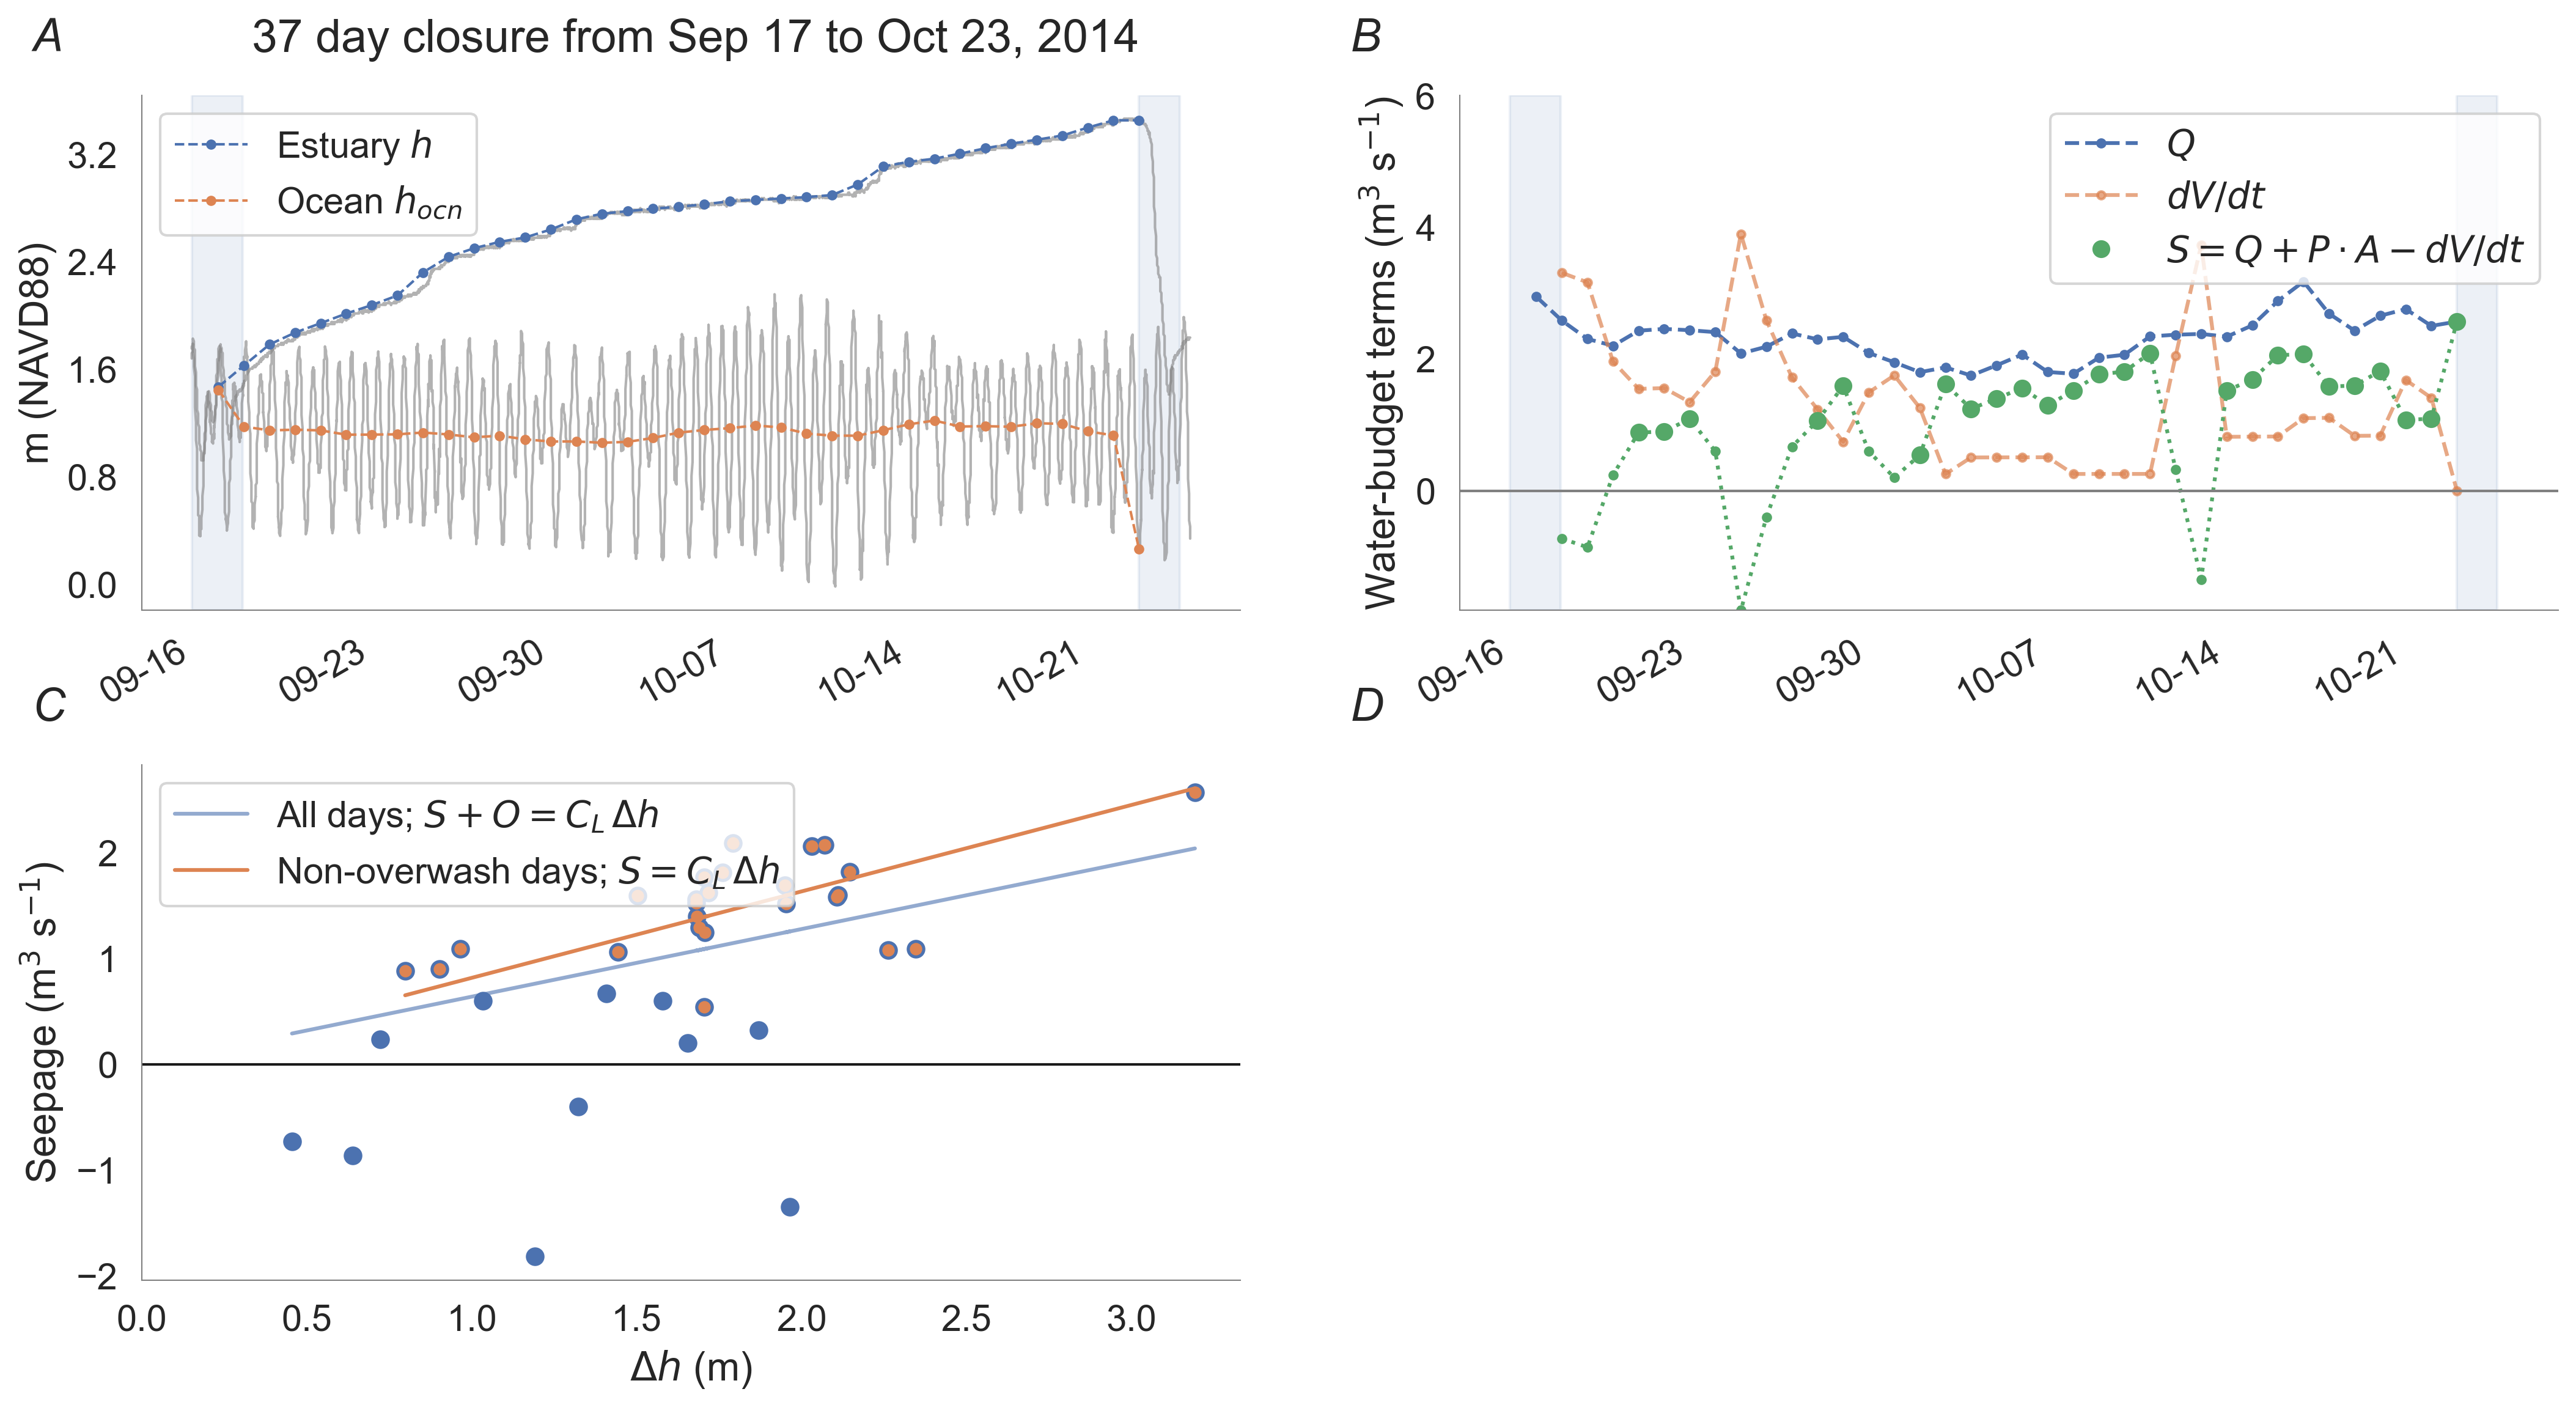

In [114]:
ind = 0

subset =  get_subset(merged_case, ind, 0, 0)
fig, axes = plt.subplots(2, 2, figsize = (17, 9.5))
axes = axes.ravel()
plt.subplots_adjust(hspace = 0.3)
plt.subplots_adjust(wspace = 0.2)

title, duration = plot_12hr_visit(merged_case, ind, axes[0], legend_loc = 'upper left', padding  = 2)

plot_mass_bal_visit(merged_case, ind, padding  = 2, logscale = False, legend_loc = 'upper right',
                    regression_line = False, ax = axes[1])
plot_visitor_scatter(merged_case, ind, axes[2], power =1)

axes[1].set_ylim(axes[1].get_ylim()[0], axes[1].get_ylim()[1]*1.4)

axes[0].text(-0.1, 1.15, 'A', transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');

axes[0].text(0.1, 1.15, title, transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 18, style = 'normal');

axes[1].text(-0.1, 1.15, 'B', transform=axes[1].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[2].text(-0.1, 1.15, 'C', transform=axes[2].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[3].text(-0.1, 1.15, 'D', transform=axes[3].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
hide_axes(axes[3])
date = "{0}-{1}".format(subset.iloc[0].name.year, subset.iloc[0].name.month)

# Panel C shows net berm flux $Q - \dfrac{dV}{dt}$ as a function of $\Delta h$.
# On days with overwash, $Q - \dfrac{dV}{dt} = S + O$, where $S$ is seepage and
# $O$ is overwash. On non-overtopping days, $O \approx 0$, so the net berm flux
# approximates seepage $S$.

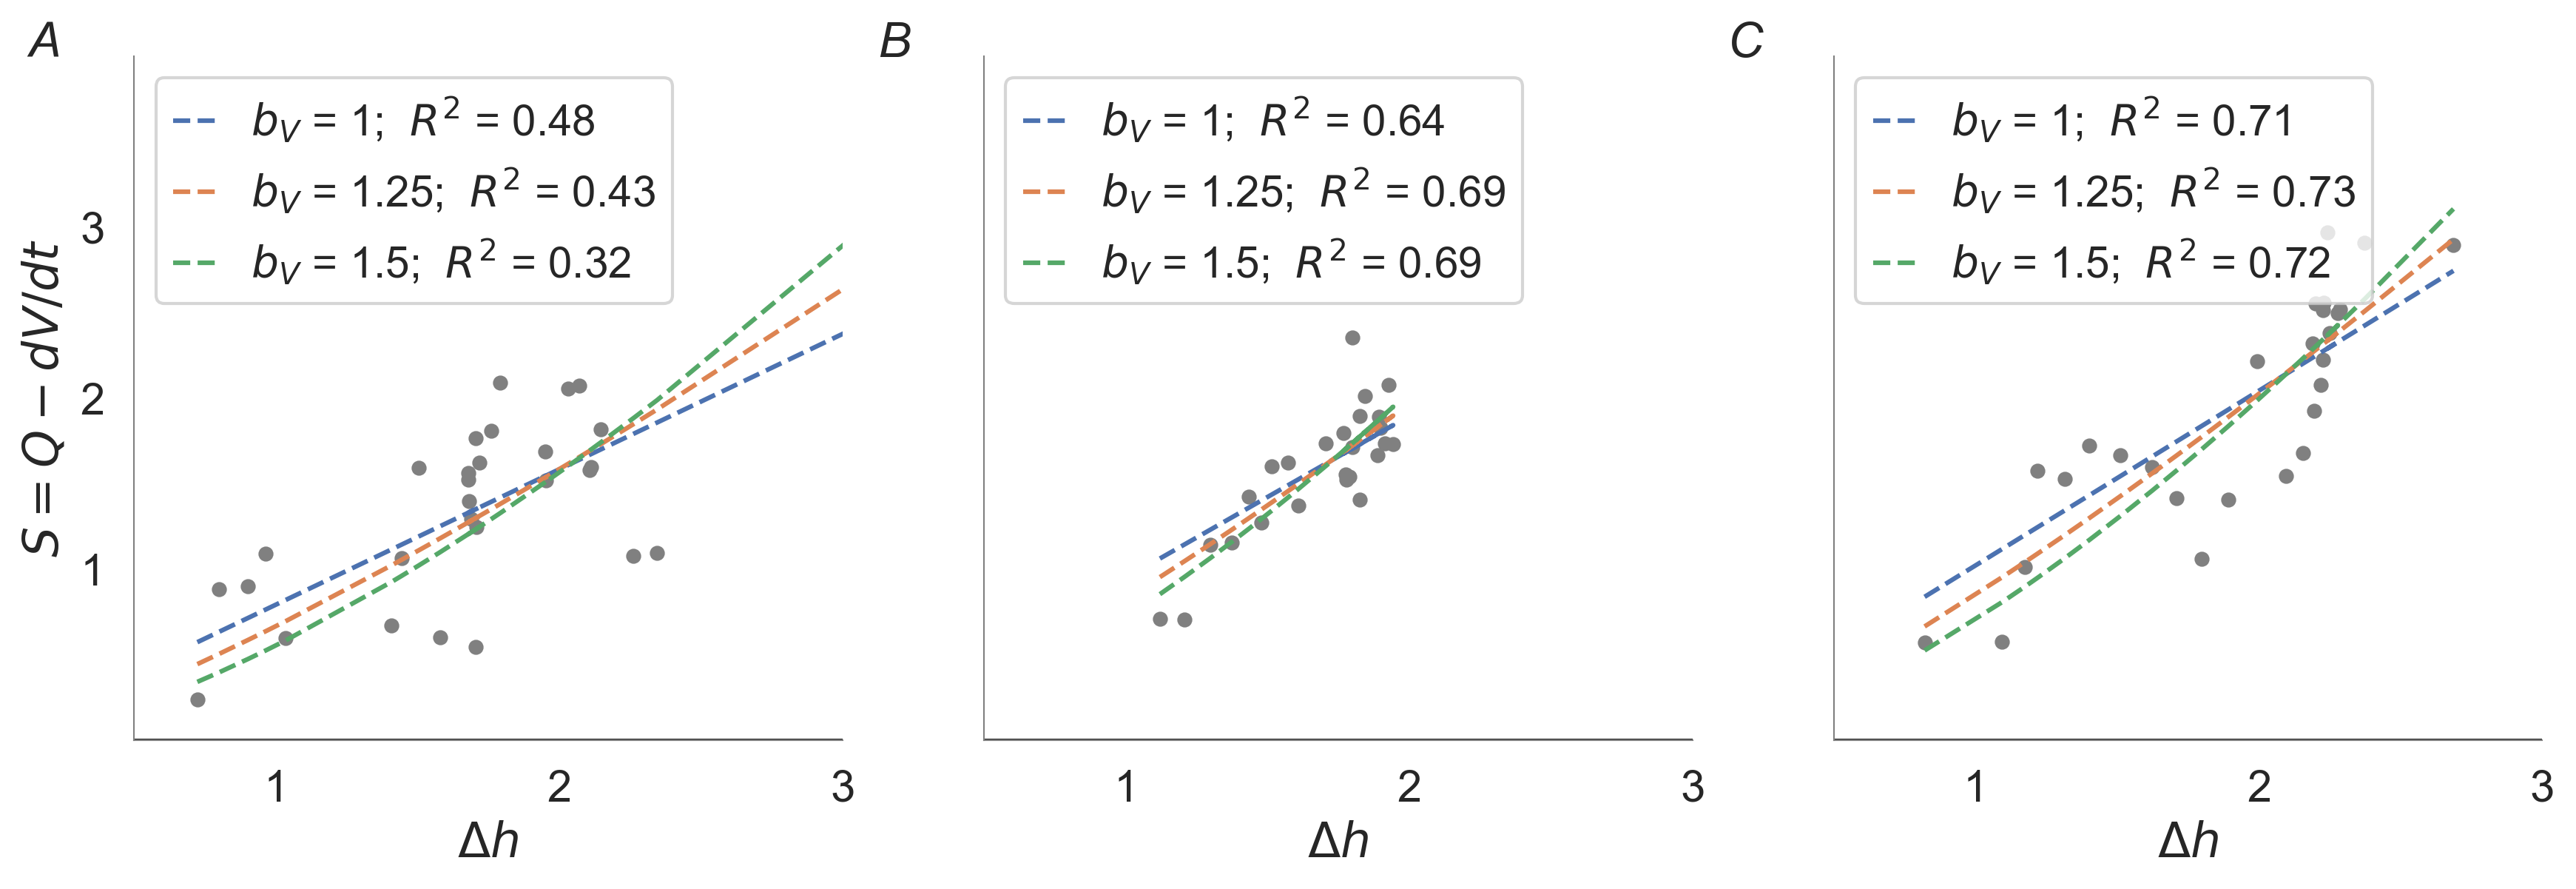

In [115]:
def plot_visitor_power(merged_case, ind, ax, power = [1,1.25, 1.5]):
    """
    """
    subset =  get_subset(merged_case, ind, 0, 0)

    daily_subset = get_daily_subset(subset, periods = 1)
    #print (daily_subset.index[0].date(), "duration = {0} days" .format( len(daily_subset)))
    daily_subset = daily_subset.query("seepage_visitor < 6")

    daily_subset['seepage'] =  daily_subset['seepage_visitor']
    daily_subset['State_visit'] = daily_subset['State_visit'].apply(np.floor)

    # Calculate Δh
    daily_subset['delta_h'] = daily_subset.visitor_filled - daily_subset.v
    daily_subset = daily_subset[['seepage', 'delta_h', 'waveHs', 'visitor_h']].dropna()
    daily_subset['date'] = daily_subset.index.date

    # daily_subset = daily_subset
    lose = filter_overtop(subset, minval=0.0)

    pos_subset = daily_subset[~(daily_subset.date).isin(lose)]
    pos_subset = pos_subset.query("seepage > 0 ")
    if len(pos_subset) > 0:

        X = pos_subset[['delta_h']]**power[0]
        # X = (pos_subset['delta_h'] * pos_subset['visitor_h']**power[0]).values.reshape(-1, 1)
        y =  pos_subset['seepage']
        predictions, slope, intercept, r_squared, t_value, CI_low, CI_high, residual = fit_Xy(X, y)
        ax.scatter(pos_subset['delta_h'], pos_subset['seepage'],  c= 'grey', label='', s = 15)
        ax.plot(pos_subset['delta_h'], predictions, color='C0', ls = '--',
            label=f'$b_V$ = {power[0]:.0f};  $R^2$ = {r_squared:.2f}')

        X = pos_subset[['delta_h']]**power[1]
        # X = (pos_subset['delta_h'] * pos_subset['visitor_h']**power[1]).values.reshape(-1, 1)
        y =  pos_subset['seepage']
        predictions, slope, intercept, r_squared, t_value, CI_low, CI_high, residual = fit_Xy(X, y)
        ax.plot(pos_subset['delta_h'], predictions, color='C1', ls = '--',
            label=f'$b_V$ = {power[1]:.2f};  $R^2$ = {r_squared:.2f}')


        X = pos_subset[['delta_h']]**power[2]
        # X = (pos_subset['delta_h'] * pos_subset['visitor_h']**power[2]).values.reshape(-1, 1)
        y =  pos_subset['seepage']
        predictions, slope, intercept, r_squared, t_value, CI_low, CI_high, residual = fit_Xy(X, y)
        ax.plot(pos_subset['delta_h'], predictions, color='C2', ls = '--',
            label=f'$b_V$ = {power[2]:.1f};  $R^2$ = {r_squared:.2f}')

    ax.set_xlabel('$\Delta h$')
    ax.legend(loc = 'upper left', handlelength = 1, fontsize = 14)
    #ax.set_xlim(0, )
    ax.axhline(0, c = 'k', lw = 1)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7)))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())


fig, axes = plt.subplots(1,3, figsize = (14, 4), sharex = True, sharey = True)

plot_visitor_power(merged_case, 0, axes[0])
axes[0].set_ylabel('$S = Q - dV/dt$')
plot_visitor_power(merged_case, 1, axes[1])
plot_visitor_power(merged_case, 2, axes[2])
axes[0].set_xticks([1,2,3]);
axes[0].set_yticks([1,2,3]);
axes[0].set_xlim(0.5, 3)
axes[0].set_ylim(0, 4)

axes[0].text(-0.15, 1.05, 'A', transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 16, style = 'italic');
axes[1].text(-0.15, 1.05, 'B', transform=axes[1].transAxes, ha="left", va="top",
        fontsize = 16, style = 'italic');
axes[2].text(-0.15, 1.05, 'C', transform=axes[2].transAxes, ha="left", va="top",
        fontsize = 16, style = 'italic');


2014-09-17 duration = 37 days
2020-09-26 duration = 31 days
2018-10-16 duration = 29 days


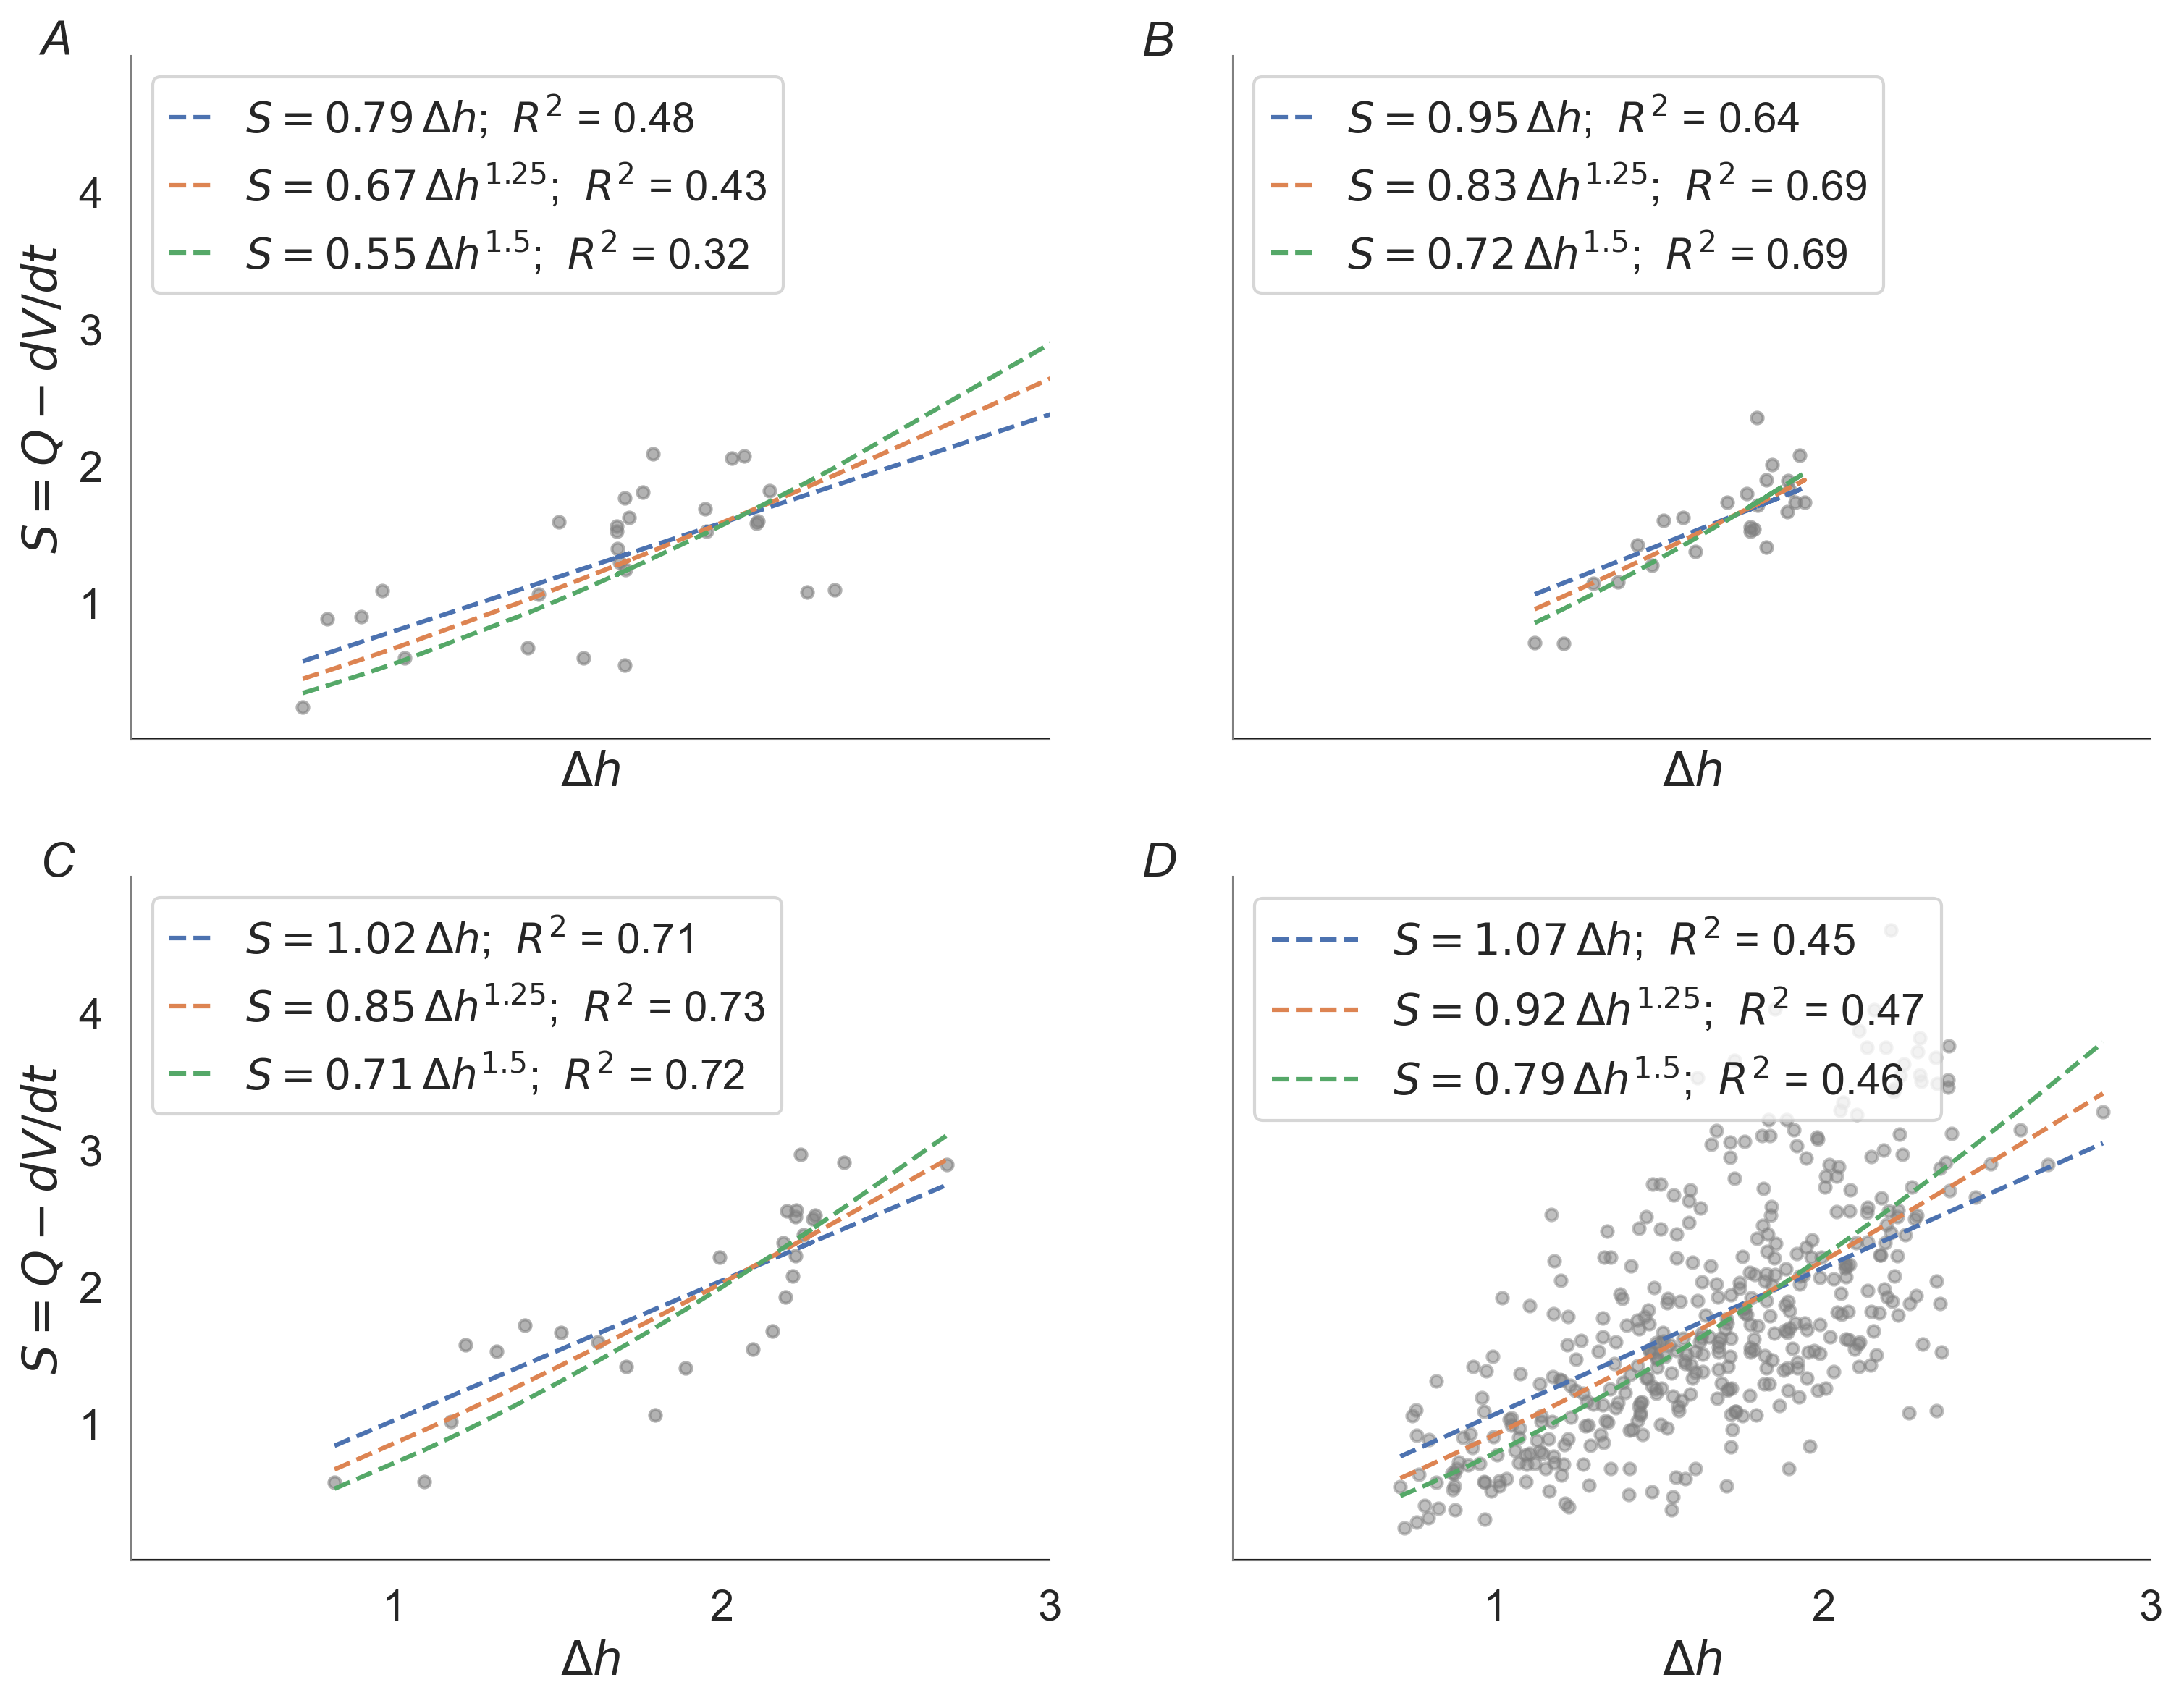

In [116]:
def plot_visitor_power_exp(merged_case, ind, ax, power = [1,1.25,1.5]):
    """
    """
    subset =  get_subset(merged_case, ind, 0, 0)

    daily_subset = get_daily_subset(subset, periods = 1)
    print (daily_subset.index[0].date(), "duration = {0} days" .format( len(daily_subset)))
    daily_subset = daily_subset.query("seepage_visitor < 6")

    daily_subset['seepage'] =  daily_subset['seepage_visitor']
    daily_subset['State_visit'] = daily_subset['State_visit'].apply(np.floor)

    # Calculate Δh
    daily_subset['delta_h'] = daily_subset.visitor_filled - daily_subset.v
    daily_subset = daily_subset[['seepage', 'delta_h', 'waveHs']].dropna()
    daily_subset['date'] = daily_subset.index.date

    # daily_subset = daily_subset
    lose = filter_overtop(subset, minval=0.0)

    pos_subset = daily_subset[~(daily_subset.date).isin(lose)]
    pos_subset = pos_subset.query("seepage > 0 ")
    if len(pos_subset) > 0:

        X = pos_subset[['delta_h']]**power[0]
        y =  pos_subset['seepage']
        predictions, slope, intercept, r_squared, t_value, CI_low, CI_high, residuals = fit_Xy(X, y)
        ax.scatter(pos_subset['delta_h'], pos_subset['seepage'],  c= 'grey', label='', alpha = 0.6, s = 15)
        
        ax.plot(pos_subset['delta_h'], predictions, color='C0', ls = '--',
            label=f'$S = {slope:.2f}\,\Delta h$;  $R^2$ = {r_squared:.2f}')

        y =  pos_subset['seepage']
        X = pos_subset[['delta_h']]**power[1]        
        predictions, slope, intercept, r_squared, t_value, CI_low, CI_high, residuals = fit_Xy(X, y)
        ax.plot(pos_subset['delta_h'], predictions, color='C1', ls = '--',
            label=f'$S = {slope:.2f}\,\Delta h^{{1.25}}$;  $R^2$ = {r_squared:.2f}')

        y =  pos_subset['seepage']
        X = pos_subset[['delta_h']]**power[2]        
        predictions, slope, intercept, r_squared, t_value, CI_low, CI_high, residuals = fit_Xy(X, y)
        ax.plot(pos_subset['delta_h'], predictions, color='C2', ls = '--',
                        label=f'$S = {slope:.2f}\,\Delta h^{{1.5}}$;  $R^2$ = {r_squared:.2f}')


    ax.set_xlabel('$\Delta h$')
    ax.legend(loc = 'upper left', handlelength = 1, fontsize = 14)
    #ax.set_xlim(0, )
    ax.axhline(0, c = 'k', lw = 1)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7)))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())

fig, axes = plt.subplots(2,2, figsize = (12, 9), sharex = True, sharey = True)
axes = axes.ravel()

plot_visitor_power_exp(merged_case, 0, axes[0])
plot_visitor_power_exp(merged_case, 1, axes[1])
plot_visitor_power_exp(merged_case, 2, axes[2])
axes[0].set_xticks([1,2,3]);
axes[0].set_yticks([1,2,3,]);
axes[0].set_xlim(0.5, 3)
axes[0].set_ylim(0, 4)
axes[0].set_ylabel('$S = Q - dV/dt$')

axes[0].text(-0.1, 1.05, 'A', transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 16, style = 'italic');
axes[1].text(-0.1, 1.05, 'B', transform=axes[1].transAxes, ha="left", va="top",
        fontsize = 16, style = 'italic');
axes[2].text(-0.1, 1.05, 'C', transform=axes[2].transAxes, ha="left", va="top",
        fontsize = 16, style = 'italic');
axes[3].text(-0.1, 1.05, 'D', transform=axes[3].transAxes, ha="left", va="top",
        fontsize = 16, style = 'italic');

ax = axes[3]

pooled_event_df = pooled_event_df.sort_values("delta_h")
ax.scatter(pooled_event_df['delta_h'], pooled_event_df['seepage'], label='', c= 'grey', alpha  = 0.5, s = 15)
X = pooled_event_df[['delta_h']]
y =  pooled_event_df['seepage']
predictions, slope, intercept, r_squared, t_value, CI_low, CI_high, residuals = fit_Xy(X, y)


ax.plot(pooled_event_df['delta_h'], predictions, "--",
    label=f'$S = {slope:.2f}\,\Delta h$;  $R^2$ = {r_squared:.2f}')
X = pooled_event_df[['delta_h']]**1.25
y =  pooled_event_df['seepage']
predictions, slope, intercept, r_squared, t_value, CI_low, CI_high, residuals = fit_Xy(X, y)


ax.plot(pooled_event_df['delta_h'], predictions, "--",
    label=f'$S = {slope:.2f}\,\Delta h^{{1.25}}$;  $R^2$ = {r_squared:.2f}')

X = pooled_event_df[['delta_h']]**1.5
y =  pooled_event_df['seepage']
predictions, slope, intercept, r_squared, t_value, CI_low, CI_high, residuals = fit_Xy(X, y)
ax.plot(pooled_event_df['delta_h'], predictions,  "--",
    label=f'$S = {slope:.2f}\,\Delta h^{{1.5}}$;  $R^2$ = {r_squared:.2f}')

axes[2].set_ylabel('$S = Q - dV/dt$')
ax.set_xlabel('$\Delta h$')
ax.legend(loc = 'upper left')
ax.set_xlim(0.2, )
ax.set_ylim(0., 5)
ax.axhline(0, c = 'k', lw = 1)
ax.set_yticks([1, 2, 3, 4]);
ax.set_xticks([ 1, 2, 3]);

In [117]:
plt.rcParams['figure.figsize'] = (12.0, 6.0)
for mod in ['plot_config', 'timeseries_functions', 'seepage_analysis', 'seepage_plots']:
    if mod in sys.modules:
        del sys.modules[mod]

import plot_config
from timeseries_functions import *
from seepage_analysis import *
from seepage_plots import *
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

## Code to summarize

In [118]:
summary = pd.DataFrame()
for ind in range(N_VISITOR_EVENTS):
    try:
        best= optimize_exponent(merged_case, ind)
        summary = pd.concat([summary, best], axis = 1)
    except:
        continue         
        
summary = summary.T.reset_index().drop('index', axis = 1)# .head(30)


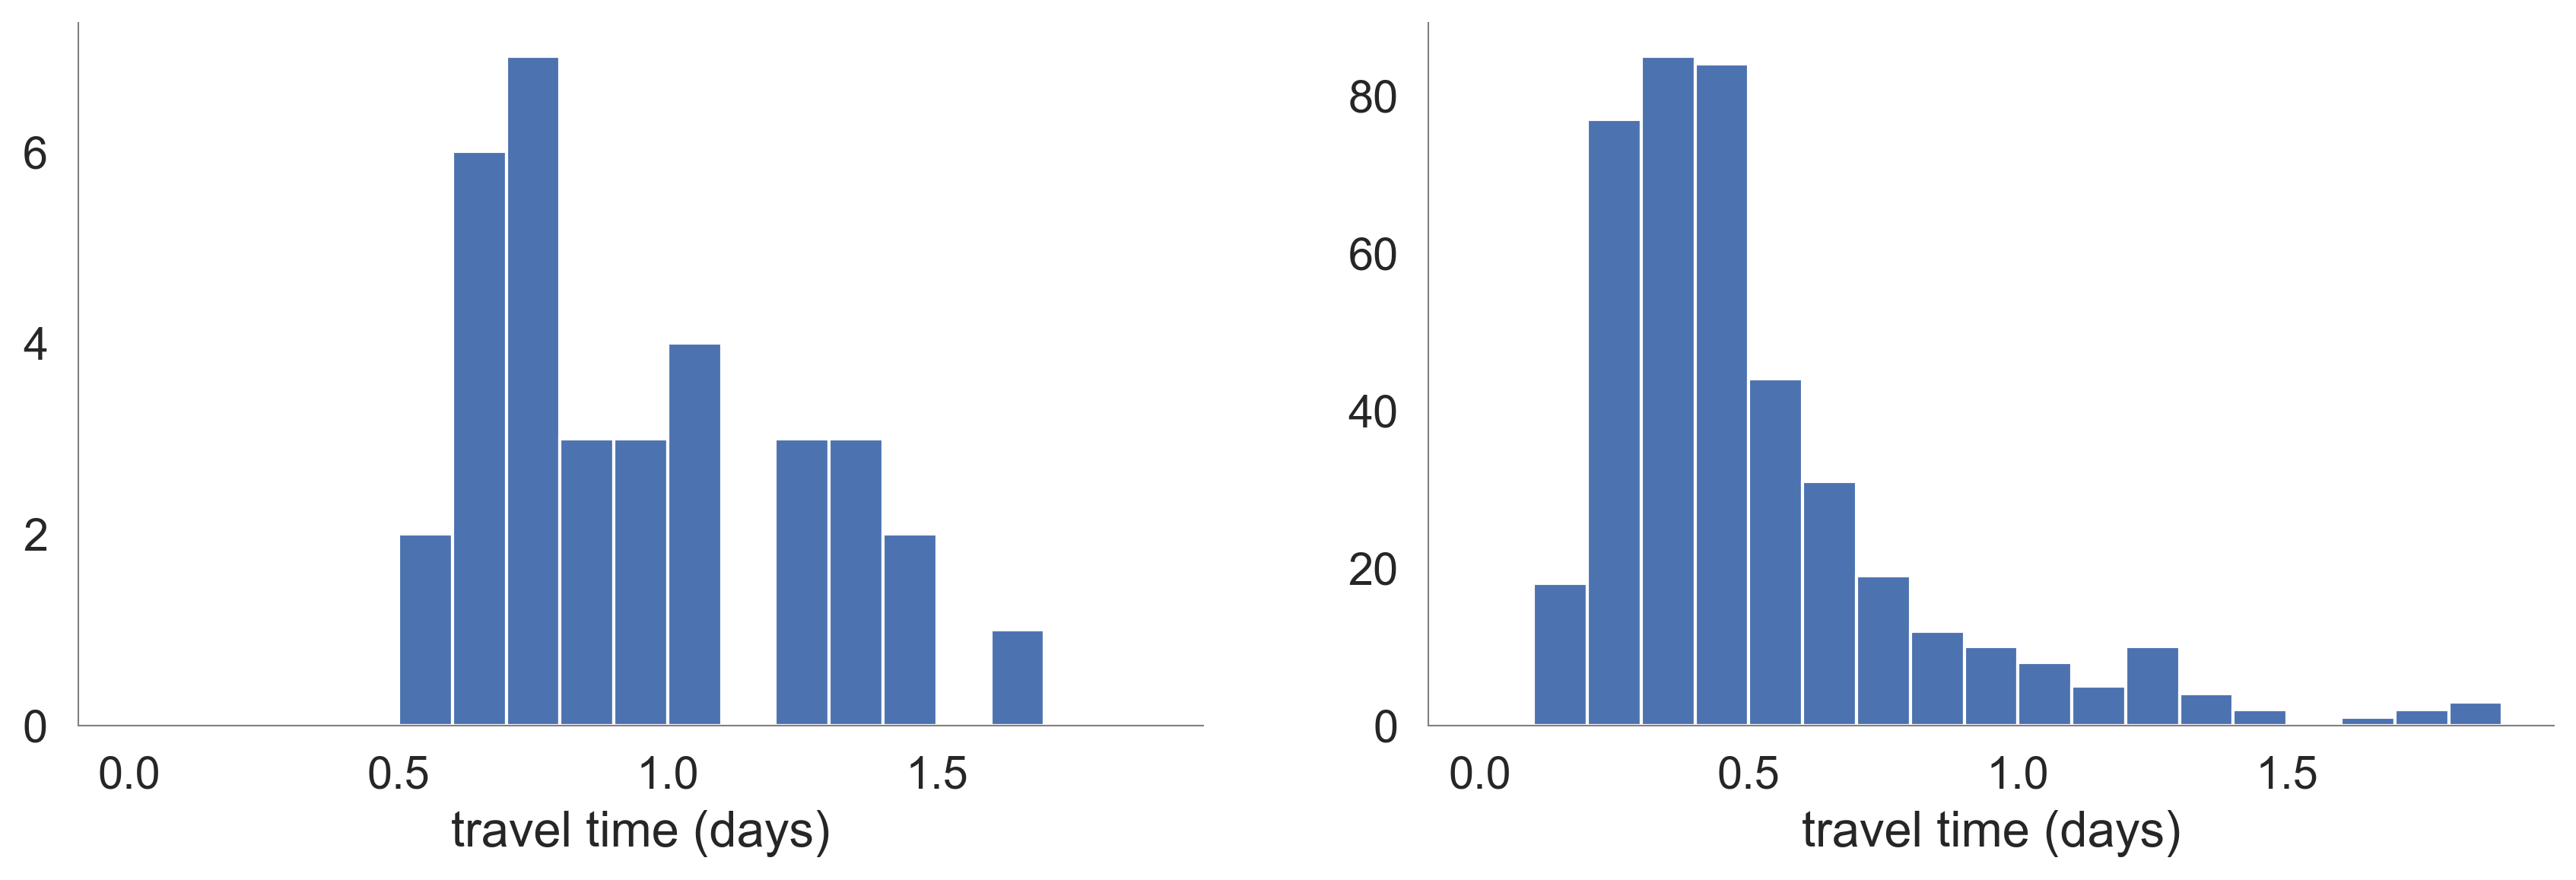

In [119]:
# Velocity estimated as Q/A_b/\psi, where psi is the porosity.

# We then estimated the travel time as w_b/V, where w_b is the berm width.
# For order of magnitude estimate, we assumed the cross sectional area A_b = 3000 m2 (300 x 50 m), width w_b = 20 m, and psi = 0.3 for a mix of sand and gravel.

def plot_travel_time(summary, ax):
    velocity = summary['Q']/10/300/5 # m/s
    velocity = velocity/0.4 # effective porosity
    travel_time = 50/velocity # s
    ax.hist(travel_time/3600/24, np.arange(0, 2, .1));
    ax.set_xlabel("travel time (days)")

fig, axes = plt.subplots(1,2, figsize = (14, 4))
plot_travel_time(summary, axes[0])


def plot_travel_time_K(pooled_event_df, ax):
    velocity = pooled_event_df['seepage']/10/300 # m/s
    velocity = velocity/0.4 # effective porosity
    travel_time = 50/velocity # s
    ax.hist(travel_time/3600/24, np.arange(0, 2, .1));
    ax.set_xlabel("travel time (days)")

plot_travel_time_K(pooled_event_df, axes[1])


In [120]:
# ── Summary statistics ─────────────────────────────────────────────────────────────────
print(f"N events: {len(summary)}")
print(f"\nR² (all events / first-23 events):")
print(f"  median R²:        {summary['R2'].astype(float).median():.3f}  /  "
      f"{summary['R2'].iloc[:23].astype(float).median():.3f}")
print(f"  median R²_optim:  {summary['best_R2'].astype(float).median():.3f}  /  "
      f"{summary['best_R2'].iloc[:23].astype(float).median():.3f}")
print(f"  mean   R²:        {summary['R2'].astype(float).mean():.3f}")
print(f"  mean   R²_optim:  {summary['best_R2'].astype(float).mean():.3f}")
print(f"\nb_V: mean (all)={summary['b_best'].astype(float).mean():.3f}  "
      f"mean (first-20)={summary['b_best'].iloc[:20].astype(float).mean():.3f}")
summary.head()

N events: 35

R² (all events / first-23 events):
  median R²:        0.530  /  0.570
  median R²_optim:  0.630  /  0.690
  mean   R²:        0.442
  mean   R²_optim:  0.543

b_V: mean (all)=1.334  mean (first-20)=1.250


,K_tilde_best,b_best,K_tilde,CI_low,CI_high,R2,best_R2,delta_R2,AIC_linear,AIC_best,AIC_diff,p_val,date,K_tilde_fmt,N,Q,duration
0,0.845,0.90,0.792,0.707934,0.875119,0.48,0.49,0.004,-53.3,-51.5,-1.7,0.0,2014-09-17,0.79 [0.71-0.88],29,2.34308,37
1,0.76,1.40,0.947,0.891393,1.003129,0.64,0.69,0.052,-72.6,-74.5,1.9,0.0,2020-09-26,0.95 [0.89-1.00],25,2.500432,31
2,0.82,1.30,1.021,0.947821,1.095125,0.71,0.73,0.023,-53.5,-53.7,0.3,0.0,2018-10-16,1.02 [0.95-1.10],27,3.33674,29
3,1.091,0.50,0.929,0.784303,1.074573,-0.19,0.06,0.249,-37.8,-41.4,3.6,0.0,2015-09-08,0.93 [0.78-1.07],24,2.122669,27
4,0.837,1.40,1.091,0.992427,1.188597,0.79,0.85,0.057,-39.8,-44.4,4.7,0.0,2015-10-10,1.09 [0.99-1.19],21,3.266756,27


In [121]:
print (summary[['date', 'duration', 'N', 'K_tilde_fmt', 'R2', 'b_best', 'best_R2']].to_latex(index= False
            ).replace("midrule", "hline")
            .replace("toprule", "hline")  
            .replace("bottomrule", "hline").replace("K_tilde_fmt", "$C_L$")
             .replace("b_best", "$b_V$")
            .replace("best_R2", "$R^2_{optim}$")
            .replace("R2", "$R^2$")
            .replace('{lllllll}', '{lllll|ll}')
      )

\begin{tabular}{lllll|ll}
\hline
date & duration & N & $C_L$ & $R^2$ & $b_V$ & $R^2_{optim}$ \\
\hline
2014-09-17 & 37 & 29 & 0.79 [0.71-0.88] & 0.48 & 0.90 & 0.49 \\
2020-09-26 & 31 & 25 & 0.95 [0.89-1.00] & 0.64 & 1.40 & 0.69 \\
2018-10-16 & 29 & 27 & 1.02 [0.95-1.10] & 0.71 & 1.30 & 0.73 \\
2015-09-08 & 27 & 24 & 0.93 [0.78-1.07] & -0.19 & 0.50 & 0.06 \\
2015-10-10 & 27 & 21 & 1.09 [0.99-1.19] & 0.79 & 1.40 & 0.85 \\
2013-06-08 & 26 & 17 & 1.18 [0.95-1.41] & 0.37 & 1.30 & 0.39 \\
2022-10-21 & 26 & 18 & 0.93 [0.82-1.03] & 0.72 & 1.20 & 0.75 \\
2021-09-28 & 25 & 17 & 0.56 [0.50-0.63] & 0.58 & 1.10 & 0.59 \\
2014-10-24 & 25 & 21 & 0.75 [0.68-0.81] & 0.52 & 1.80 & 0.63 \\
2017-08-05 & 23 & 22 & 1.66 [1.60-1.72] & 0.86 & 0.90 & 0.87 \\
2017-09-12 & 23 & 21 & 1.46 [1.33-1.59] & 0.64 & 1.30 & 0.67 \\
2014-01-11 & 22 & 10 & 0.87 [0.65-1.08] & 0.53 & 1.90 & 0.73 \\
2016-09-11 & 19 & 17 & 0.88 [0.79-0.97] & 0.36 & 0.60 & 0.50 \\
2015-05-28 & 18 & 15 & 1.18 [1.07-1.28] & 0.79 & 1.70 & 0.90 \\


Text(1.5, 0.95, ' ')

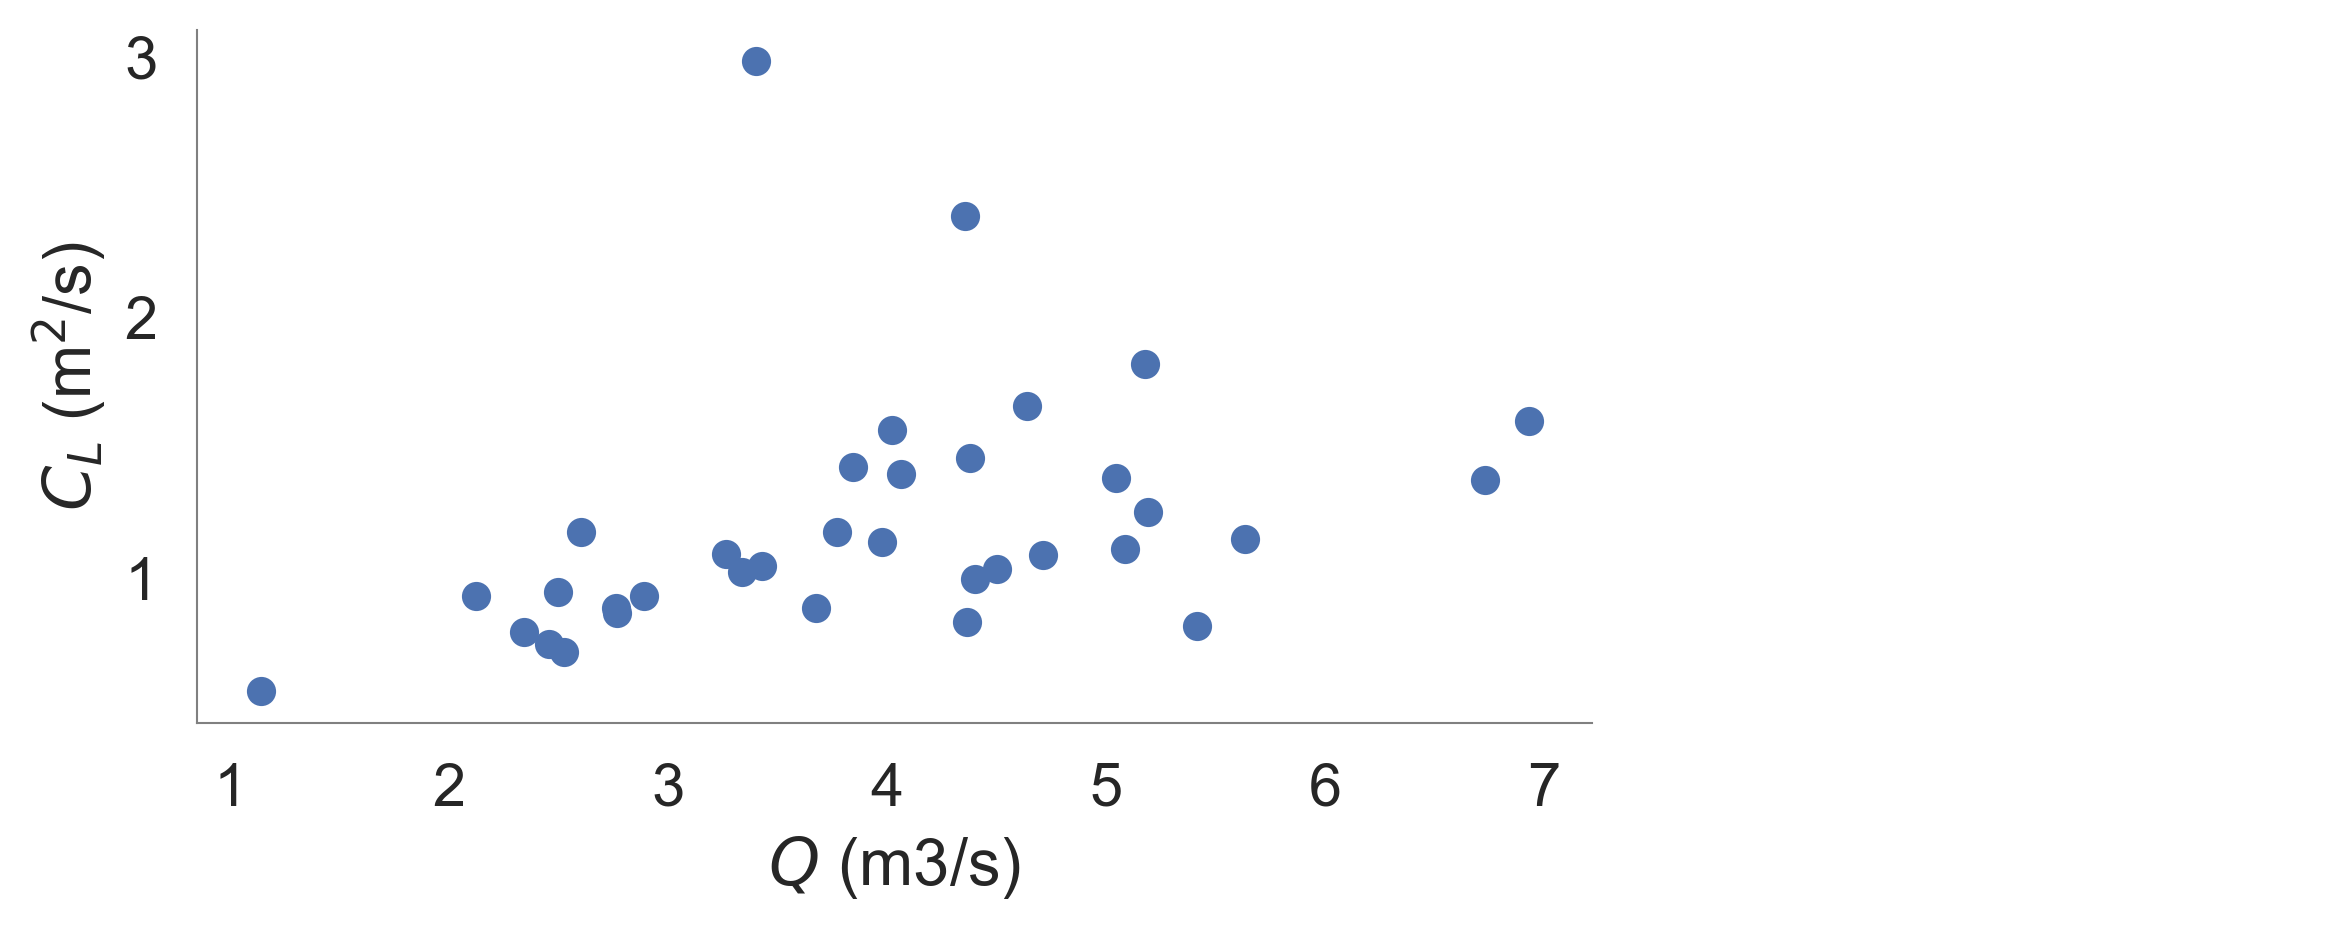

In [122]:
plt.figure(figsize = (6,3))
plt.scatter(summary.Q, summary.K_tilde)
# plt.scatter(summary.Q, summary.b_best.astype(float))
plt.xlabel("$Q$ (m3/s)")
plt.ylabel("$C_L$ (m$^2$/s)")
ax = plt.gca()
ax.text(1.5, .95, " ", transform=ax.transAxes, ha="left", va="top")


###  Figures plots

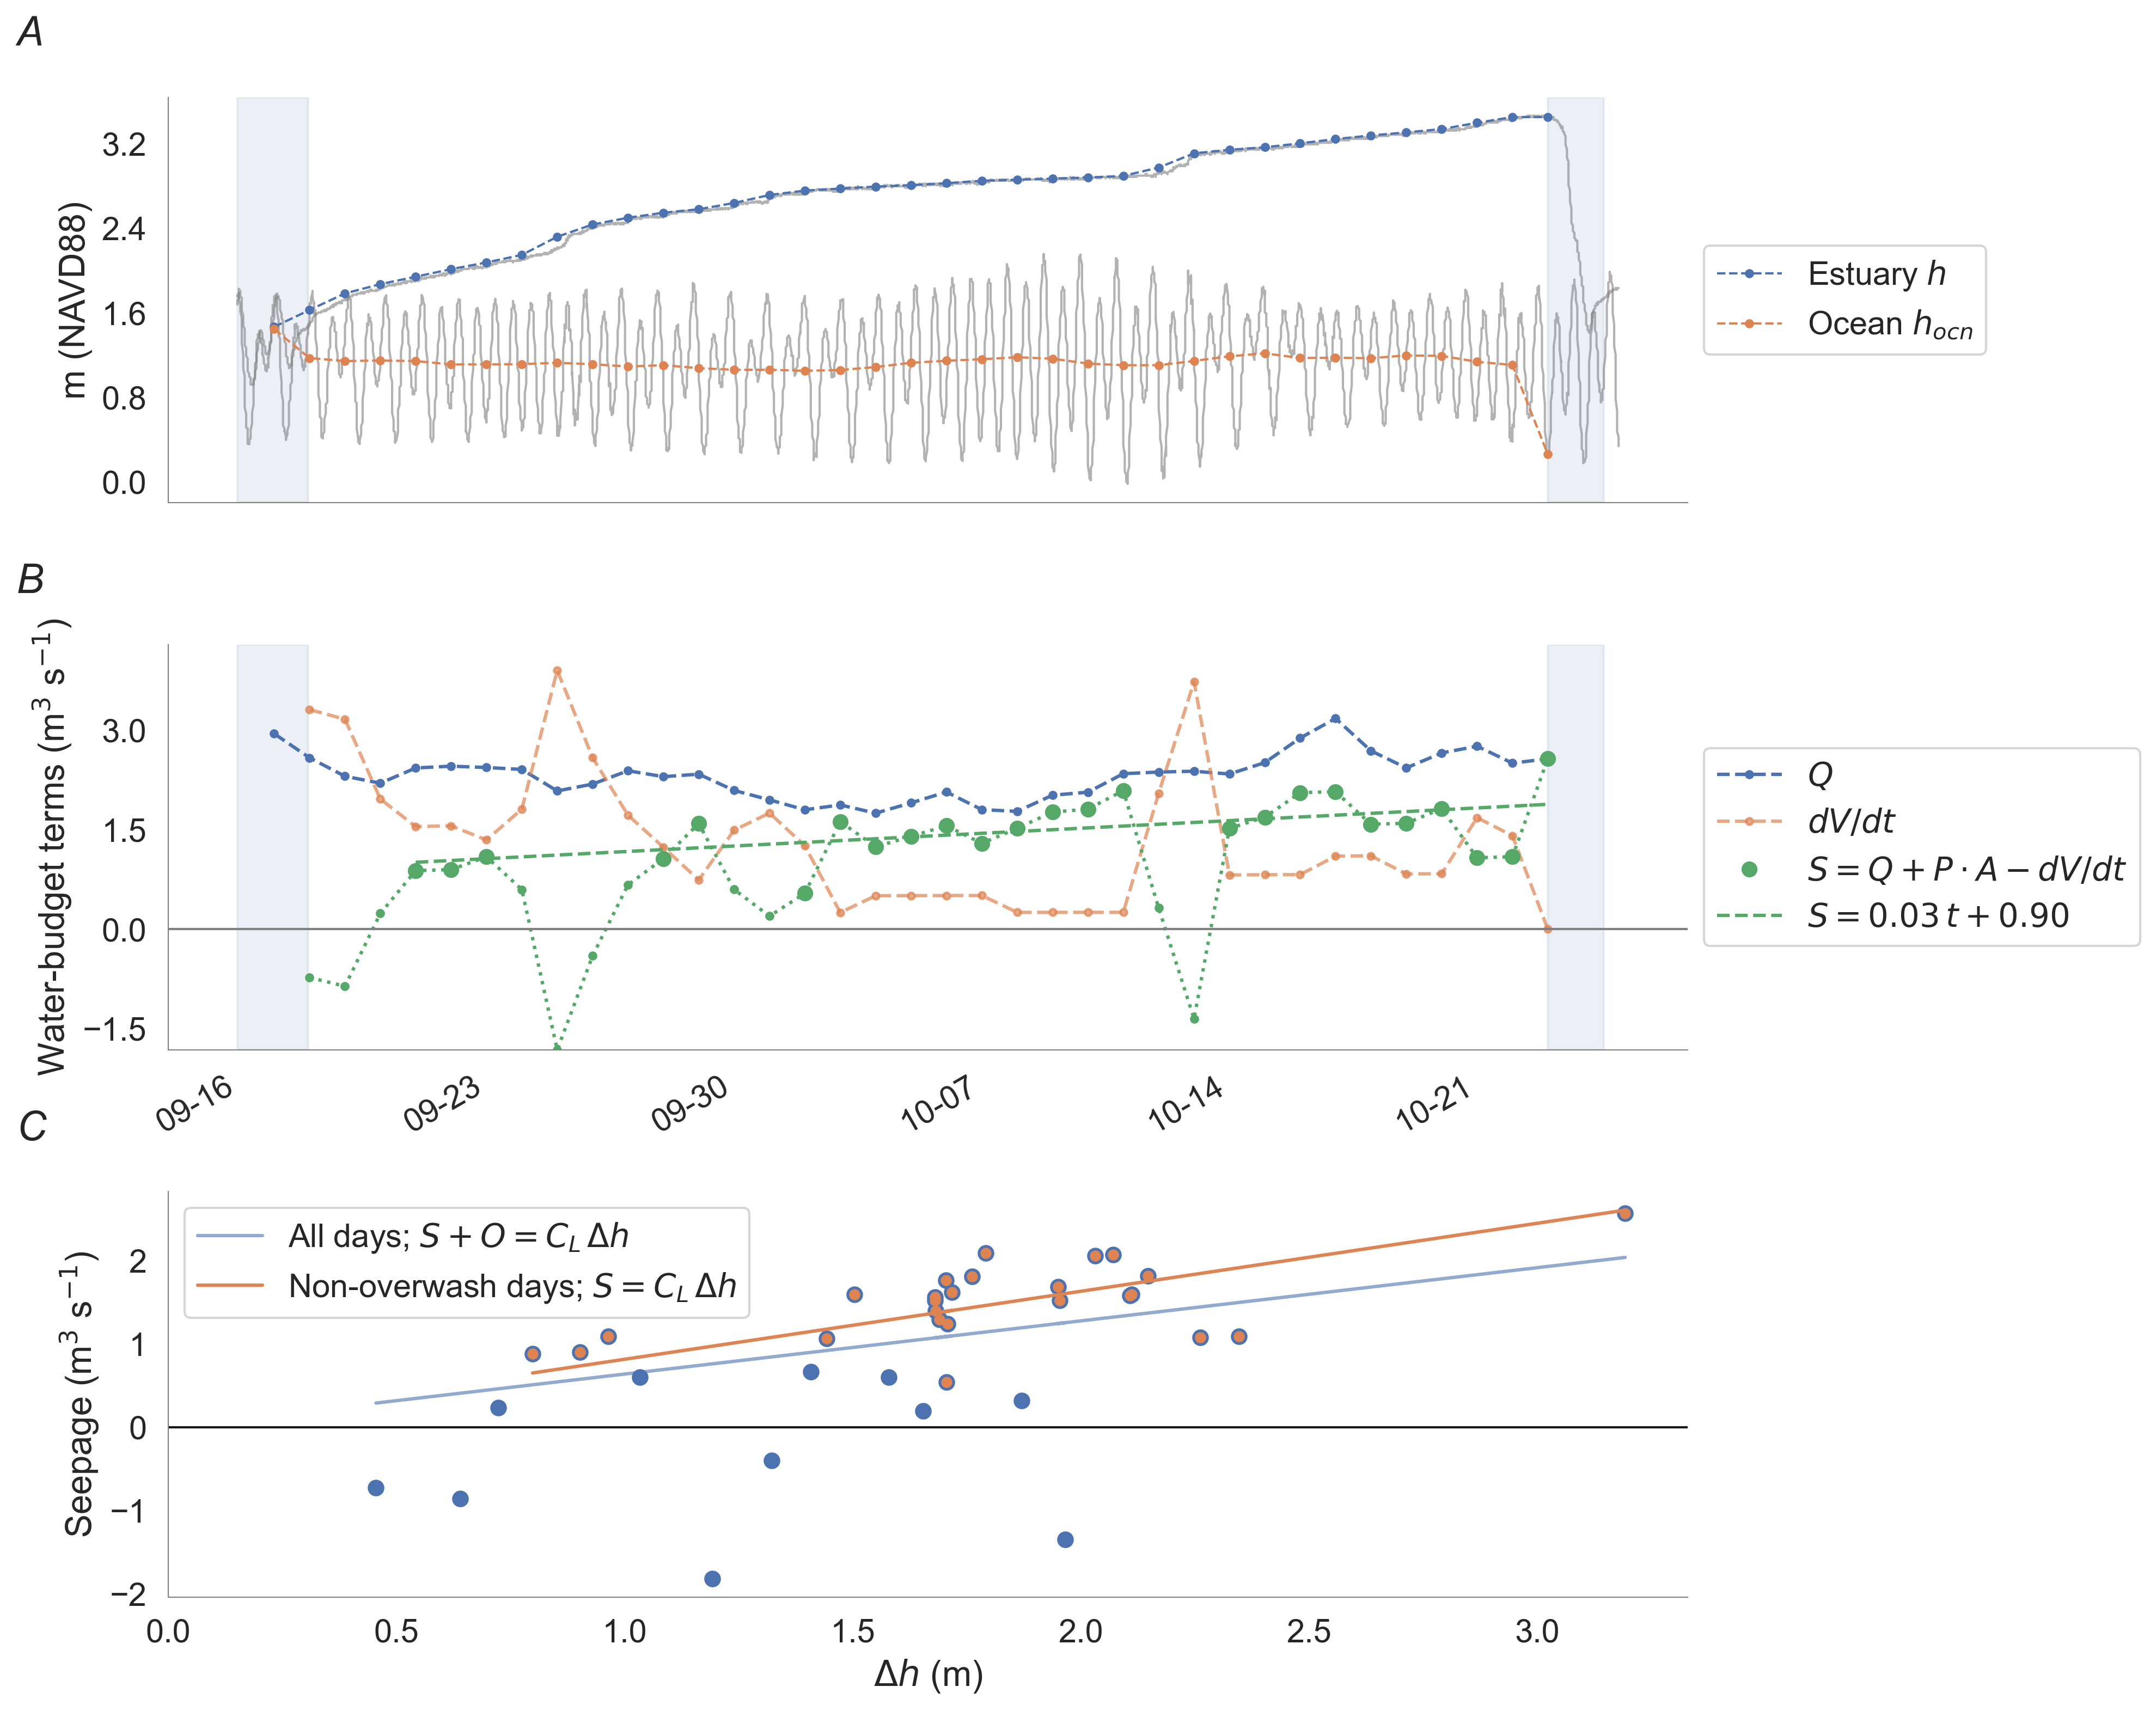

In [123]:

merged_case = merged_rain
for ind in range(1):

    subset =  get_subset(merged_case, ind, 0, 0)

    fig, axes = plt.subplots(3, 1,  figsize = (12, 13.5))
    plt.subplots_adjust(hspace = 0.35)
    plot_12hr_visit(merged_case, ind, axes[0], padding  = 2)
    plot_mass_bal_visit(merged_case, ind, padding  = 2, logscale = False, ax = axes[1])
    plot_visitor_scatter(merged_case, ind, axes[2])

    axes[0].text(-0.1, 1.2, 'A', transform=axes[0].transAxes, ha="left", va="top",
            fontsize = 18, style = 'italic');
    axes[1].text(-0.1, 1.2, 'B', transform=axes[1].transAxes, ha="left", va="top",
            fontsize = 18, style = 'italic');
    axes[2].text(-0.1, 1.2, 'C', transform=axes[2].transAxes, ha="left", va="top",
            fontsize = 18, style = 'italic');
    axes[0].set_xticks([])
    date = "{0}-{1}".format(subset.iloc[0].name.year, subset.iloc[0].name.month)
#     plt.savefig('visitor_closures/{1:.0f}days__{0}.png'.format(date,
#                                              len(subset.query("State_visit == 1"))/24/4), bbox_inches='tight')

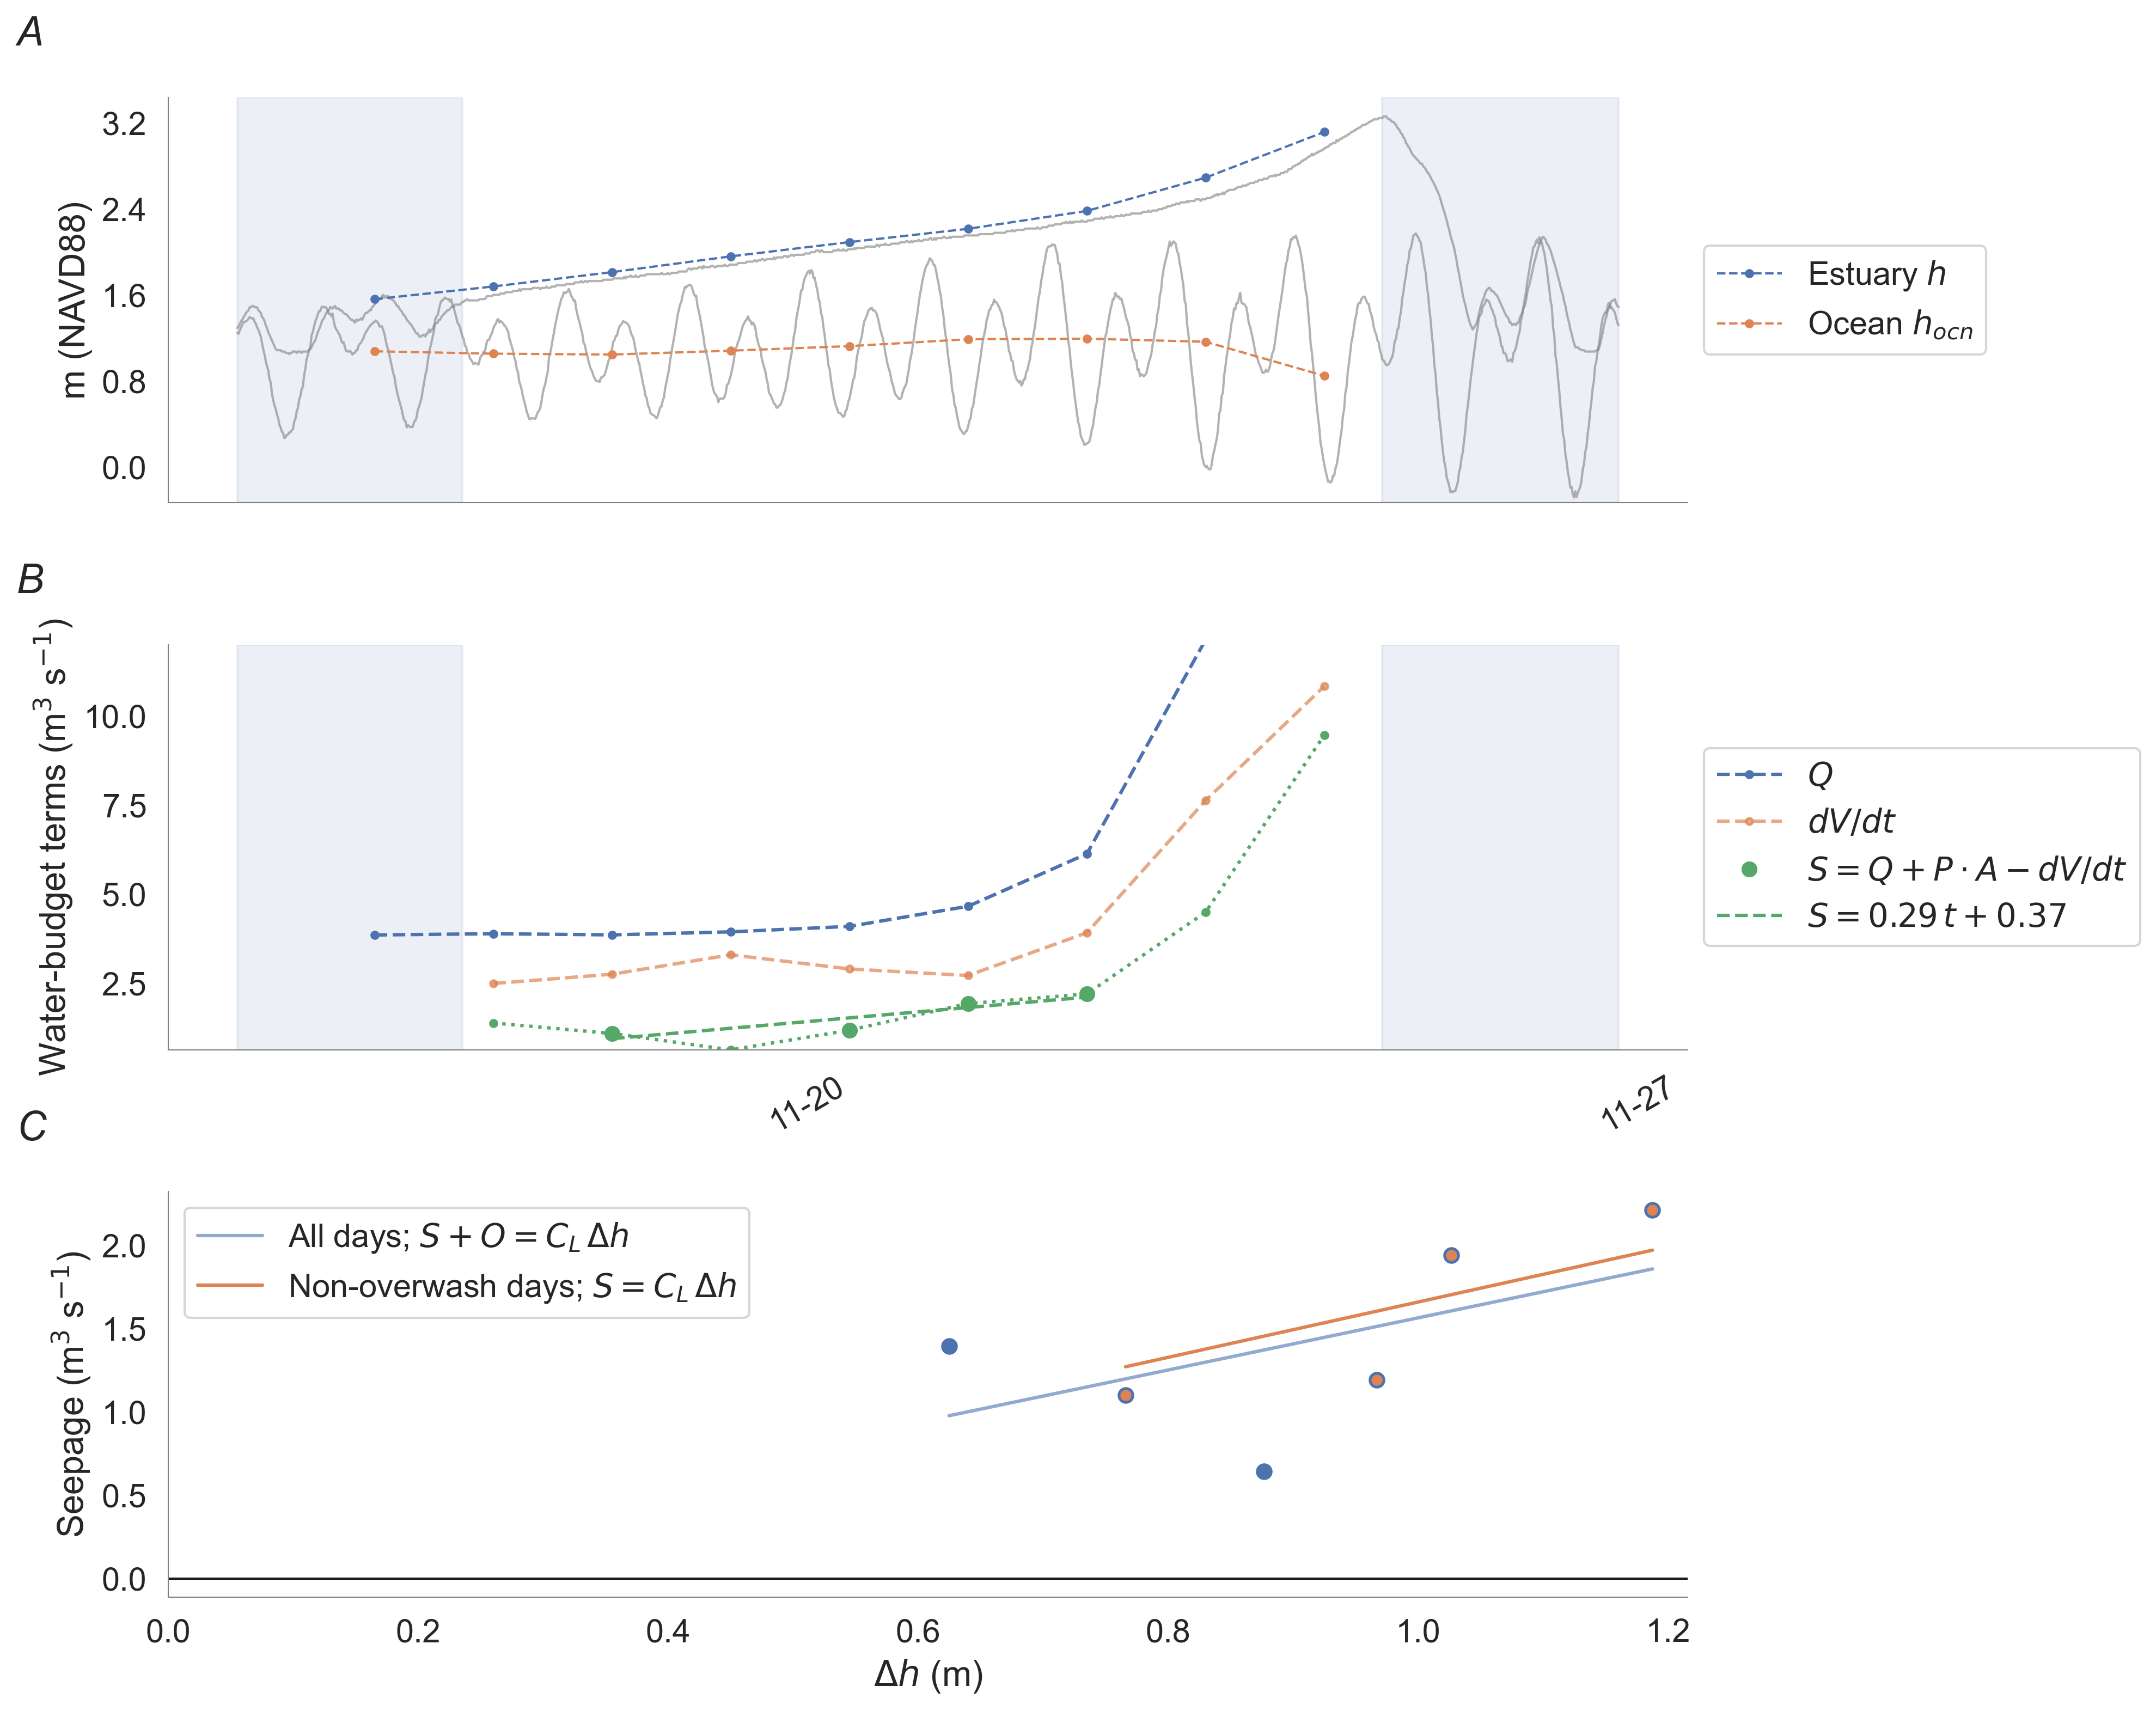

In [124]:
merged_case = merged_wave

ind = 36
subset =  get_subset(merged_case, ind, 0, 0)

fig, axes = plt.subplots(3, 1,  figsize = (12, 13.5))
plt.subplots_adjust(hspace = 0.35)
plot_12hr_visit(merged_case, ind, axes[0], padding  = 2)
plot_mass_bal_visit(merged_case, ind, padding  = 2, logscale = False, ax = axes[1])
plot_visitor_scatter(merged_case, ind, axes[2])

axes[0].text(-0.1, 1.2, 'A', transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[1].text(-0.1, 1.2, 'B', transform=axes[1].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[2].text(-0.1, 1.2, 'C', transform=axes[2].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[0].set_xticks([])
date = "{0}-{1}".format(subset.iloc[0].name.year, subset.iloc[0].name.month)
# plt.savefig('visitor_closures/{1:.0f}days__{0}.png'.format(date,
#                                          len(subset.query("State_visit == 1"))/24/4), bbox_inches='tight')

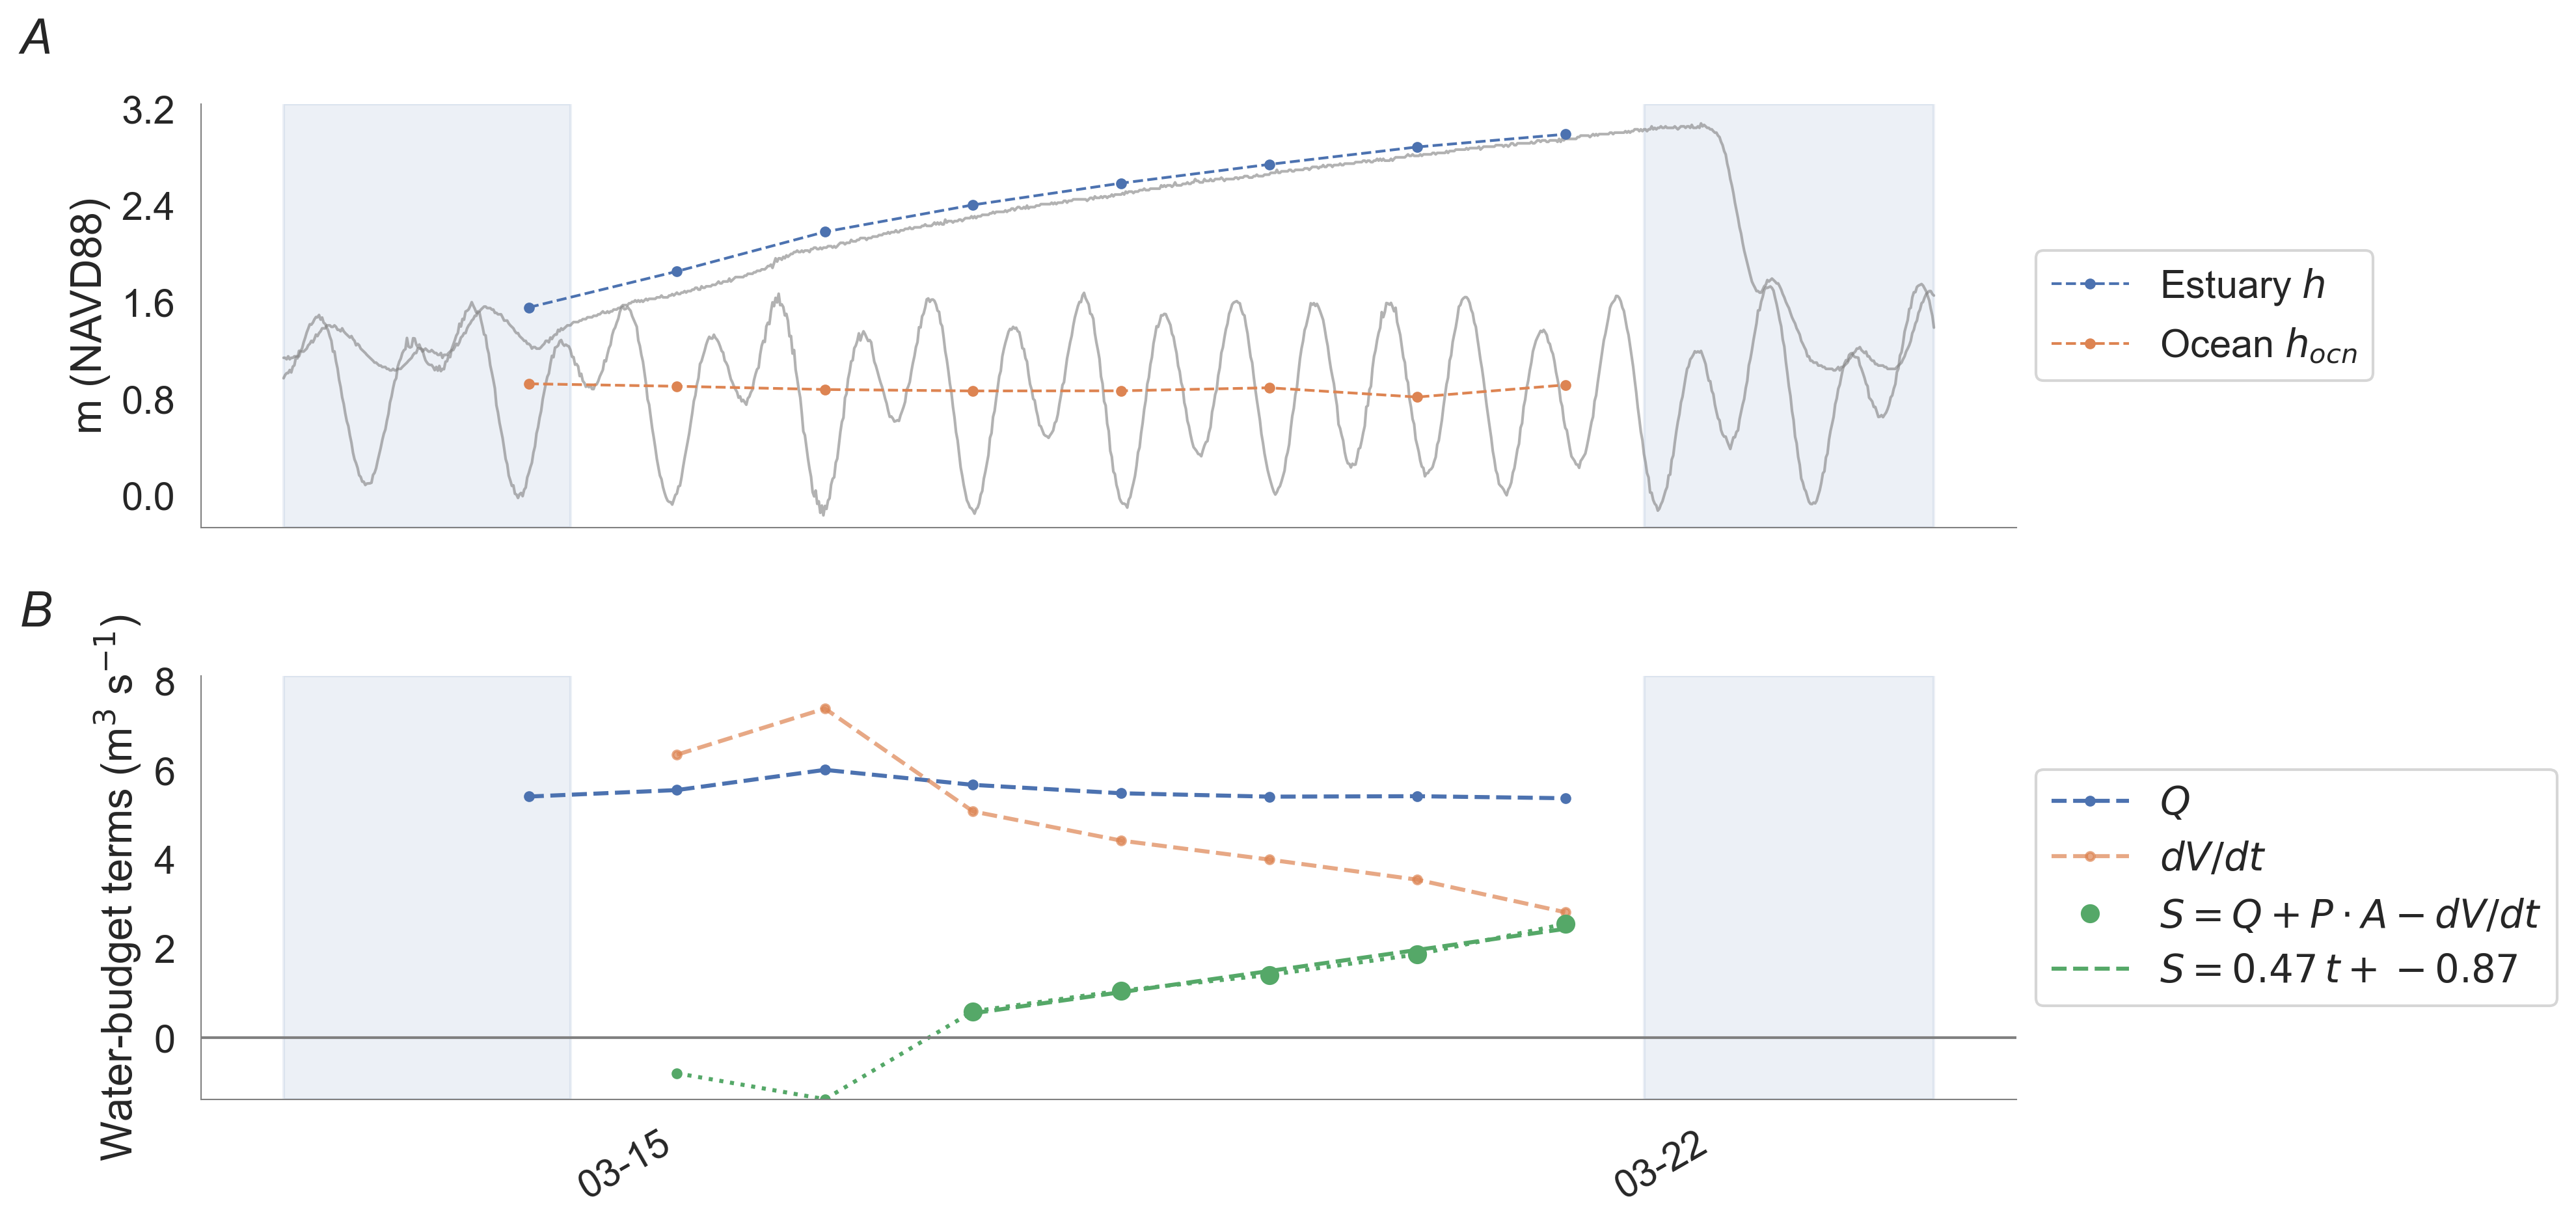

In [125]:
ind = 37
subset =  get_subset(merged_case, ind, 0, 0)

fig, axes = plt.subplots(2, 1, sharex = True, figsize = (12, 7.5))
plt.subplots_adjust(hspace = 0.35)
plot_12hr_visit(merged_case, ind, axes[0], padding  = 2)
plot_mass_bal_visit(merged_case, ind, padding  = 2, logscale = False, ax = axes[1])


axes[0].text(-0.1, 1.2, 'A', transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[1].text(-0.1, 1.2, 'B', transform=axes[1].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');


# Summarize

In [126]:
plt.rcParams['figure.figsize'] = (12.0, 6.0)
for mod in ['plot_config', 'timeseries_functions', 'seepage_analysis', 'seepage_plots']:
    if mod in sys.modules:
        del sys.modules[mod]

import plot_config
from timeseries_functions import *
from seepage_analysis import *
from seepage_plots import *
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

In [127]:


def bootstrap_median_ci(data, n_bootstrap=1000, ci=95):
    """
    Calculate the confidence interval for the median of a dataset using the bootstrap method.

    :param data: List or numpy array of data points
    :param n_bootstrap: Number of bootstrap samples to generate
    :param ci: Confidence level (between 0 and 100)
    :return: Tuple containing lower and upper bounds of the confidence interval
    """
    medians = np.array([np.median(np.random.choice(data, size=len(data)-1, replace=True)) for _ in range(n_bootstrap)])
    lower_bound = np.percentile(medians, (100 - ci) / 2)
    upper_bound = np.percentile(medians, 100 - (100 - ci) / 2)

    return lower_bound, upper_bound


def get_row(merged_case, ind, offset = 0, exponent = 0, filters = None):
    """
    """
    subset =  get_subset(merged_case, ind, 0, 0)

    daily_subset = get_daily_subset(subset.query("State_visit == 1"))
    daily_subset['day'] = np.arange(len(daily_subset))

    duration = len(daily_subset)

    daily_subset = daily_subset.query("seepage_visitor < 4")

    daily_subset['seepage'] =  daily_subset['seepage_visitor']
    daily_subset['State_visit'] = daily_subset['State_visit'].apply(np.floor)

    # Calculate Δh
    daily_subset['delta_h'] = daily_subset.visitor_filled - daily_subset.v
    daily_subset['date'] = daily_subset.index.date

    #daily_subset = daily_subset[:-1]

    if filters == 'forecast':

        # Only include values for which overwash estimates are zero
        hourly_subset = get_hourly_visitor(subset)

        lose = filter_overtop(subset, minval=0.0)
        if len(lose) > 0:
            daily_subset = daily_subset[~(daily_subset.index).isin(lose)]
        daily_subset = daily_subset.query("seepage > 0")

    elif filters == 'positive':
        
        daily_subset = daily_subset.query("seepage > 0")

    daily_subset = daily_subset[['seepage', 'delta_h', 'Q', 'day', 'visitor_h']].dropna().query('seepage < 4')

    # Linear regression model without intercept
    X = (daily_subset['delta_h'] * (daily_subset['delta_h'] + offset)**exponent).values.reshape(-1, 1)

    y =  daily_subset['seepage']

    if len(X) > 3:
        Ks_predictions, Ks, intercept, Ks_r2, t_value, CI_low, CI_high, residuals = fit_Xy(X, y)
    else:
        return

    SQ = daily_subset[['seepage', 'Q']].dropna()
    SQ_ratio =  SQ['seepage']/SQ['Q']
    S_CI = bootstrap_median_ci(daily_subset['seepage'])
    SQ_CI = bootstrap_median_ci(SQ_ratio)

    X = daily_subset[['day']]
    y = daily_subset['seepage']

    S_predictions, dSdt, S_intercept, S_R2, t_value, dSdt_CI_low, dSdt_CI_high, residuals = \
            fit_Xy(X, y, fit_intercept = True)


    row = pd.Series(
            {
            'ind' : ind,
            'duration'  : duration,
            'offset' : offset,
            'exponent' : exponent,                
            'N': len(daily_subset),
            'date': daily_subset.iloc[0].name.date(),
            'year': daily_subset.iloc[0].name.year,
            'month': daily_subset.iloc[0].name.month,
            # regression fits on Ks
            'Ks' : np.round(float(Ks),3),
            'CI_low' : CI_low,
            'CI_high' : CI_high,
            'R2' : np.round(Ks_r2,3),
            # seepage estimates
            'S' : np.round(daily_subset['seepage'].median(), 3),
            'S_max' : np.round(daily_subset['seepage'].max(), 3),
            'S_min' : np.round(daily_subset['seepage'].min(), 3),
            'S_CI_low' : S_CI[0],
            'S_CI_high' : S_CI[1],
            # seepage trends
            'dSdt' : dSdt,
            'dSdt_CI_low' : dSdt_CI_low,
            'dSdt_CI_high' : dSdt_CI_high,
            # discharge
            'delta_h' : np.round(daily_subset['delta_h'].mean(), 3),
            'delta_h_min' : np.round(daily_subset['delta_h'].min(), 3),
            'delta_h_max' : np.round(daily_subset['delta_h'].max(), 3),
            # discharge
            'Q' : np.round(daily_subset['Q'].mean(), 3),
            'Q_min' : np.round(daily_subset['Q'].min(), 3),
            'Q_max' : np.round(daily_subset['Q'].max(), 3),

            # seepage fraction
            'SQ' : np.round(SQ['seepage'].sum()/SQ['Q'].sum(), 3),
            'SQ_min' : np.round(SQ_ratio.min(), 3),
            'SQ_max' : np.round(SQ_ratio.max(), 3),
            'SQ_CI_low' : SQ_CI[0],
            'SQ_CI_high' : SQ_CI[1],
            #
            'delta_h' : np.round(daily_subset['delta_h'].median(), 3),
            'S_list' :
                list(daily_subset['seepage']),
            'Q_list' : list(daily_subset['Q']),
            }, name = ind)

    return row

def compile_summary(merged_case, num, offset = 0, exponent = 0, filters = None):

    summary = pd.DataFrame()

    for ind in range(num):

        row = get_row(merged_case, ind, offset = offset, exponent = exponent, filters = filters)
        summary = pd.concat([summary, row], axis = 1)

    return summary.T

In [128]:
# ── USGS pipeline helpers ────────────────────────────────────────────────────────
def get_row_USGS(ind, filters=None, offset=0, exponent=0):
    """
    USGS variant: matches get_row() functional form for Ks fit.
    Uses X = Δh * (Δh + offset)**exponent (through-origin regression).
    Rain correction (rain_m3s) is subtracted from seepage, matching the visitor pipeline.
    """
    subset = get_subset_USGS(merged, ind, 0, 0)

    daily_subset = get_daily_subset_USGS(subset.query("State_USGS == 1")).copy()
    daily_subset['day'] = np.arange(len(daily_subset))
    duration = len(daily_subset)

    # Seepage (USGS): Q - dV/dt - rain (when State_USGS == 1)
    rain = daily_subset['rain_m3s'] if 'rain_m3s' in daily_subset.columns else 0
    daily_subset['seepage'] = (
        daily_subset['Q'] - daily_subset['dvol/dt_USGS_filled'] - rain
    ).where(daily_subset['State_USGS'] == 1)

    daily_subset['State_USGS'] = np.floor(daily_subset['State_USGS'])

    # Δh (USGS-referenced head difference)
    daily_subset['delta_h'] = daily_subset['USGS_filled'] - daily_subset['v']

    # Optional filters
    if filters == 'forecast':
        # Exclude days with inferred overwash (domain-specific heuristic)
        hourly_subset = get_hourly_USGS(subset)
        if 'USGS_h_Q' in hourly_subset.columns:
            lose = hourly_subset[(hourly_subset['USGS_h_Q'] - hourly_subset['USGS_h']) < -0.02].index
            lose = list(np.unique(lose.date))
            daily_subset = daily_subset[~daily_subset.index.isin(lose)]
        else:
            return
    elif filters == 'positive':
        daily_subset = daily_subset.query("seepage > 0")

    # Keep required fields; light screen on seepage
    daily_subset = (
        daily_subset[['seepage', 'delta_h', 'Q', 'day', 'USGS_h']]
        .dropna()
        .query('seepage < 4')
    )

    # --- Ks regression (through origin), matching get_row() functional form ---
    # X = Δh * (Δh + offset)**exponent
    X = (daily_subset['delta_h'] * (daily_subset['delta_h'] + offset)**exponent).values.reshape(-1, 1)
    y = daily_subset['seepage']

    if len(X) > 3:
        Ks_predictions, Ks, intercept, Ks_r2, t_value, CI_low, CI_high, residuals = fit_Xy(X, y)
    else:
        return

    # Seepage fraction stats
    SQ = daily_subset[['seepage', 'Q']].dropna()
    SQ_ratio = SQ['seepage'] / SQ['Q']
    S_CI = bootstrap_median_ci(daily_subset['seepage'])
    SQ_CI = bootstrap_median_ci(SQ_ratio)

    # Seepage trend vs day (with intercept)
    X_tr = daily_subset[['day']]
    y_tr = daily_subset['seepage']
    S_predictions, dSdt, S_intercept, S_R2, t_value, dSdt_CI_low, dSdt_CI_high, residuals = \
        fit_Xy(X_tr, y_tr, fit_intercept=True)

    row = pd.Series({
        'duration': duration,
        'offset': offset,
        'exponent': exponent,
        'N': len(daily_subset),
        'date': daily_subset.iloc[0].name.date(),
        'year': daily_subset.iloc[0].name.year,
        'month': daily_subset.iloc[0].name.month,

        # regression fits on Ks
        'Ks': np.round(float(Ks), 3),
        'CI_low': CI_low,
        'CI_high': CI_high,
        'R2': np.round(Ks_r2, 3),

        # seepage estimates
        'S': np.round(daily_subset['seepage'].median(), 3),
        'S_max': np.round(daily_subset['seepage'].max(), 3),
        'S_min': np.round(daily_subset['seepage'].min(), 3),
        'S_CI_low': S_CI[0],
        'S_CI_high': S_CI[1],

        # seepage trends
        'dSdt': dSdt,
        'dSdt_CI_low': dSdt_CI_low,
        'dSdt_CI_high': dSdt_CI_high,

        # discharge & Δh (summaries; keep existing naming)
        'Q': np.round(daily_subset['Q'].median(), 3),

        # seepage fraction
        'SQ': np.round(SQ['seepage'].sum() / SQ['Q'].sum(), 3),
        'SQ_min': np.round(SQ_ratio.min(), 3),
        'SQ_max': np.round(SQ_ratio.max(), 3),
        'SQ_CI_low': SQ_CI[0],
        'SQ_CI_high': SQ_CI[1],

        # Δh summary and raw lists (unchanged)
        'delta_h': np.round(daily_subset['delta_h'].median(), 3),
        'S_list': list(daily_subset['seepage']),
        'Q_list': list(daily_subset['Q']),
    }, name=ind)

    return row

def compile_summary_USGS(num, offset = 0, exponent = 0, filters = None):
    summary = pd.DataFrame()

    for ind in range(num):
        row = get_row_USGS(ind, filters, offset = offset, exponent=exponent)
        summary = pd.concat([summary, row], axis = 1)

    return summary.T


In [129]:
summary = compile_summary(merged_wave, N_VISITOR_EVENTS, offset = 0., filters = None).sort_values("date")


Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/octaviacrompton/anaconda3/envs/hydro/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3526, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/j3/k_zl73yn1mxfz7brb0f4_lx40000gn/T/ipykernel_17557/117430124.py", line 1, in <module>
    summary = compile_summary(merged_wave, N_VISITOR_EVENTS, offset = 0., filters = None).sort_values("date")
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/j3/k_zl73yn1mxfz7brb0f4_lx40000gn/T/ipykernel_17557/1518633677.py", line 131, in compile_summary
    row = get_row(merged_case, ind, offset = offset, exponent = exponent, filters = filters)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/j3/k_zl73yn1mxfz7brb0f4_lx40000gn/T/ipykernel_17557/1518633677.py", line 20, in get_row
    subset =  get_subset(merged_case, ind, 0, 0)
  

In [ ]:
summary_for = compile_summary(merged, N_VISITOR_EVENTS, offset = 0., exponent = 0, filters = 'forecast').sort_values("date")
summary_subset = summary_for.query("N > 5 and year > 2010").iloc[1:]
summary_subset.to_csv(data_path / 'processed/summary_for.csv')


In [ ]:
summary_for['R2'].mean(), summary_for['R2'].median()

In [ ]:
summary_subset = summary_for.query(" N > 5")[1:]
fig, axes = plt.subplots(3, 1, figsize = (12, 9), sharex = True, sharey = False)

plot_seepage(summary_subset, axes[0])
plot_Ks(summary_subset, axes[1])
plot_seepage_ratio(summary_subset, axes[2])

axes[1].set_ylim(0.3, )
summary_subset[['SQ', 'S']].median()

axes[0].text(-0.1, 1.2, 'A', transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[1].text(-0.1, 1.2, 'B', transform=axes[1].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[2].text(-0.1, 1.2, 'C', transform=axes[2].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');

axes[0].set_ylim(0, )
axes[1].set_ylim(0, )
axes[2].set_ylim(0, )


dates = [pd.to_datetime('2013-02-01', format='%Y-%m-%d', errors='coerce'),
         pd.to_datetime('2015-09-01', format='%Y-%m-%d', errors='coerce'),
         pd.to_datetime('2017-03-01', format='%Y-%m-%d', errors='coerce'),
         pd.to_datetime('2019-10-01', format='%Y-%m-%d', errors='coerce'),
         pd.to_datetime('2021-11-01', format='%Y-%m-%d', errors='coerce'),
        ]

axes[1].set_ylabel(r"$C_L$ (m$^2$/s)")

In [ ]:
plt.figure(figsize = (6,3))
plt.scatter(summary_subset.Q, summary_subset.Ks)
plt.xlabel("$Q$ (m3/s)")
plt.ylabel("$C_L$ (m$^2$/s)")
ax = plt.gca()
ax.text(1.5, .95, " ", transform=ax.transAxes, ha="left", va="top")

In [ ]:
plt.figure(figsize = (6,3))
plt.scatter(summary_subset.Q, summary_subset.Q/summary_subset.Ks, label = "steady ($C_L / Q_r$ )")

plt.scatter(summary_subset.Q, summary_subset.delta_h, label = "observed")
plt.xlabel("$Q$ (m3/s)")
plt.ylabel("$\\Delta h$ (m)")
plt.axhline(3,c =  'k')
ax = plt.gca()
ax.text(1.5, .95, " ", transform=ax.transAxes, ha="left", va="top")
ax.legend()

In [ ]:
(hypso['vol_m3']/hypso['h_m']).iloc[0]

In [ ]:
summary_p25 = compile_summary(merged, N_VISITOR_EVENTS, offset = .25, filters = 'forecast').sort_values("date")
summary_p5 = compile_summary(merged, N_VISITOR_EVENTS, offset = 0.5, filters = 'forecast').sort_values("date")
summary_1 = compile_summary(merged, N_VISITOR_EVENTS, offset = 1, filters = 'forecast').sort_values("date")


In [ ]:
summary_2 = compile_summary(merged, N_VISITOR_EVENTS, offset = 2, filters = 'forecast').sort_values("date")


In [ ]:
summary_low_wind = compile_summary(merged_wave.query("wind < 12"), N_VISITOR_EVENTS, exponent = 0, filters = 'positive').sort_values("date")


In [ ]:
merged_wave.wind.mean(),  merged_wave.wind.std()


In [ ]:
summary_small_Hs = compile_summary(merged_wave.query("waveHs < 1"), N_VISITOR_EVENTS, exponent = 0, filters = 'positive').sort_values("date")


In [ ]:
summary_smaller_Hs = compile_summary(merged_wave.query("waveHs < 0.6"), N_VISITOR_EVENTS, exponent = 0, filters = 'positive').sort_values("date")


In [ ]:
summary_low_wind.R2.mean()

In [ ]:
ax, axes = plt.subplots(1, 2, figsize= (12, 4), sharey = True)
ax = axes[0]
summary_subset = summary.query("duration > 10 and N > 9")


ax.errorbar(summary_subset.duration, summary_subset['dSdt'],  color = 'C0',
                yerr = (summary_subset['dSdt_CI_high'] - summary_subset['dSdt_CI_low'])/2,
                label = '',
                linestyle = '', marker = 'o')

ax.set_ylabel("$dS/dt$ (m$^3$s$^{-1}$day$^{-1}$)")
ax.set_xlabel("closure duration (days)")


ax = axes[1]

ax.errorbar(summary_subset.S, summary_subset['dSdt'],  color = 'C0',
                yerr = (summary_subset['dSdt_CI_high'] - summary_subset['dSdt_CI_low'])/2,
                linestyle = '', marker = 'o')
len(summary_subset)
ax.set_ylabel("$dS/dt$ (m$^3$s$^{-1}$day$^{-1}$)")
ax.set_xlabel("$S$ (m$^3$s$^{-1}$)")

axes[0].text(-0.16, 1.1, 'A', transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');

axes[1].text(-0.08, 1.1, 'B', transform=axes[1].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');


In [ ]:

fig, axes = plt.subplots(3, 1, figsize = (12, 9), sharex = True, sharey = False)
summary_subset = summary.query(" N > 5 and year > 2010")[1:]
plot_seepage(summary_subset, axes[0], label = '$S + O$')
plot_Ks(summary_subset, axes[1], label = '$S + O$')
plot_seepage_ratio(summary_subset, axes[2], label = '$S + O$')


summary_subset = summary_for.query(" N > 5 and year > 2010")[1:]
plot_seepage(summary_subset, axes[0], label = '$S$', alpha = 0.7)
plot_Ks(summary_subset, axes[1], label = '$S$', alpha = 0.7)
plot_seepage_ratio(summary_subset, axes[2], label = '$S$',alpha = 0.7)
axes[0].legend()

axes[0].text(-0.1, 1.2, 'A', transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[1].text(-0.1, 1.2, 'B', transform=axes[1].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[2].text(-0.1, 1.2, 'C', transform=axes[2].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
for i in range(3):
    axes[i].axhline(0, c = 'k', linestyle = '--', alpha = 0.5, lw = 0.8)

# ax.set_ylabel("Sandbar conductivity (m2/s)")

In [ ]:
fig, axes = plt.subplots(3, 1, figsize = (12, 9), sharex = True, sharey = False)
summary_subset = summary_low_wind.query(" N >= 6 and year > 2010").iloc[1:]
plot_seepage(summary_subset, axes[0], label = '$S(U < 12 $m/s$)$')
plot_Ks(summary_subset, axes[1], label = '$S(U < 12$m/s$)$')
plot_seepage_ratio(summary_subset, axes[2], label = '$S(U < 12$m/s$)$')

summary_subset = summary_for.query(" N >= 6 and year > 2010").iloc[1:]
plot_seepage(summary_subset, axes[0], label = '$S$', alpha = 0.7)
plot_Ks(summary_subset, axes[1], label = '$S$', alpha = 0.7)
plot_seepage_ratio(summary_subset, axes[2], label = '$S$',alpha = 0.7)
axes[0].legend()

axes[0].text(-0.1, 1.2, 'A', transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[1].text(-0.1, 1.2, 'B', transform=axes[1].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[2].text(-0.1, 1.2, 'C', transform=axes[2].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
for i in range(3):
    axes[i].axhline(0, c = 'k', linestyle = '--', alpha = 0.5, lw = 0.8)

# ax.set_ylabel("Sandbar conductivity (m2/s)")

In [ ]:
fig, axes = plt.subplots(3, 1, figsize = (12, 9), sharex = True, sharey = False)
summary_subset = summary_smaller_Hs.query(" N >= 6 and year > 2010").iloc[1:]
plot_seepage(summary_subset, axes[0], label = '$S(Hs < 0.5 $ m$)$')
plot_Ks(summary_subset, axes[1], label = '$S(Hs < 0.5 $ m$)$')
plot_seepage_ratio(summary_subset, axes[2], label = '$S(Hs < 0.5 $ m$)$')


summary_subset = summary_for.query(" N >= 6 and year > 2010").iloc[1:]
plot_seepage(summary_subset, axes[0], label = '$S$', alpha = 0.7)
plot_Ks(summary_subset, axes[1], label = '$S$', alpha = 0.7)
plot_seepage_ratio(summary_subset, axes[2], label = '$S$',alpha = 0.7)
axes[0].legend()

axes[0].text(-0.1, 1.2, 'A', transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[1].text(-0.1, 1.2, 'B', transform=axes[1].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[2].text(-0.1, 1.2, 'C', transform=axes[2].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
for i in range(3):
    axes[i].axhline(0, c = 'k', linestyle = '--', alpha = 0.5, lw = 0.8)

# ax.set_ylabel("Sandbar conductivity (m2/s)")

In [ ]:
summary_2.query("year == 2013")

## Back of envelope calculations

In [ ]:
Evap = 10./1000/3600/24 #mm/day m/mm day/s
# Estuary area is 10,000 m2
Evap*100000


In [ ]:
# plt.hist(summary_pos.S)
summary_for.S.median(), summary_for.Q.median()

# Median S during closures is 1.5 m3/s = 540000.0 m3/day

# sand conductivity m/day = 41 m/day = 41/3600/24 m/day
# cross sectional area is about 300x5 m2
# S = K*A *dh/dL
# KK = K A/dL
K = 41/3600/24
A = 300*(5) # summary_pos.delta_h.median()*2)
L = 50
# K*A*summary_pos.delta_h.median()/L, summary_pos.S.median()

In [ ]:
K*A/L,  summary_for.Ks.mean()

## USGS plots

In [ ]:

def get_shading_regions(series, threshold):
    """
    """
    regions = []
    start = None
    for i, val in enumerate(series):
        if val < threshold and start is None:
            start = series.index[max(i-1, 0)]
        elif val >= threshold and start is not None:
            regions.append((start, series.index[i]))
            start = None
    if start is not None:
        regions.append((start, series.index[-1]))
    return regions

def get_ylim(daily_subset):
    """
    ylimits for plot_USGS_scatter
    """
    Qmax = np.percentile(daily_subset['Q'].dropna(), 99)
    dvol_max = np.percentile(daily_subset['dvol/dt_USGS_filled'].dropna(), 99)
    seep_max =np.percentile(daily_subset['seepage_USGS'].dropna(), 100)

    ymax = max(Qmax, dvol_max, seep_max )*1.1


    Qmin =np.percentile(daily_subset['Q'].dropna(), 0)
    dvol_min = np.percentile(daily_subset['dvol/dt_USGS_filled'].dropna(), 0)
    seep_min =np.percentile(daily_subset['seepage_USGS'].dropna(), 0)

    ymin = min(Qmin, dvol_min, seep_min )*1.1
    ymin = min(ymin, 0)

    return ymin, ymax



def get_ylim_visitor(daily_subset):
    """
    ylimits for plot_USGS_scatter
    """
    Qmax = np.percentile(daily_subset['Q'].dropna(), 99)
    dvol_max = np.percentile(daily_subset['dvol/dt_visitor_filled'].dropna(), 99)
    seep_max =np.percentile(daily_subset['seepage_visitor'].dropna(), 100)

    ymax = max(Qmax, dvol_max, seep_max )*1.1


    Qmin =np.percentile(daily_subset['Q'].dropna(), 0)
    dvol_min = np.percentile(daily_subset['dvol/dt_visitor_filled'].dropna(), 0)
    seep_min =np.percentile(daily_subset['seepage_visitor'].dropna(), 0)

    ymin = min(Qmin, dvol_min, seep_min )*1.1
    ymin = min(ymin, 0)

    return ymin, ymax

def hide_axes(ax):
    # Hide the spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Hide the ticks and labels
    ax.set_xticks([])
    ax.set_yticks([])


def plot_mass_bal_USGS(merged, ind, ax, padding = 10, logscale = 1, legend_loc = 'outside',
                        regression_line = True):
    """

    """
    subset =  get_subset_USGS(merged, ind, padding, padding)

    closure_subset =  get_subset_USGS(merged, ind, 0, 0)

    daily_subset = get_daily_subset(closure_subset, include_USGS = 1).query("seepage_USGS < 8")
    daily_subset['date'] = daily_subset.index.date
    daily_subset['day'] = np.arange(len(daily_subset))

    lose = filter_overtop(closure_subset)

    # fixes x-axis limits
    subset[[ 'v']].rename({'v' : ''}, axis= 1).plot(ax = ax, visible = False)

    # Create a boolean mask where 'State_visit' > 0
    closed = daily_subset['State_visit'] > 0
    closed = daily_subset[closed].index

    daily_subset['Q'].plot(secondary_y=False, xlabel='Time', style='C0.--',
                        legend=True, ax = ax, label = '$Q$')

    (daily_subset['dvol/dt_USGS_filled']).plot(xlabel='Time', ylabel='m3/s',
                            style = 'C1.--', ax = ax, label = '$dV/dt$')

    (daily_subset['seepage_USGS']).plot(xlabel='Time', ylabel='m3/s',
                                    style = 'C2:.', ax = ax, label = '')

    pos_subset = daily_subset[~(daily_subset.date).isin(lose)]

    pos_subset = pos_subset[['day', 'date', 'seepage_USGS']].dropna()

    if len(pos_subset) > 0:

        (pos_subset['seepage_USGS']).plot(xlabel='Time', ylabel='m3/s',
                                        style = 'C2o', ms = 7, ax = ax, label = '$S = Q - dV/dt$')

    if len(pos_subset) > 0 and regression_line == True:
        X = pos_subset[['day']]
        y =  pos_subset['seepage_USGS']
        predictions, slope, intercept, r_squared, t_value, CI_low, CI_high, residuals = fit_Xy(X, y, fit_intercept = True)
        pos_subset['predictions'] = predictions

        (pos_subset['predictions']).plot(style = 'C2--', ax = ax,
            label=f'$S = ${slope:.2f}$t$ + {intercept:.2f};  $R^2$ = {r_squared:.2f}')


    ax.axhline(0, c = 'grey', lw = 1)

    ymin, ymax = get_ylim(daily_subset.loc[closed])
    ax.set_ylim(ymin, ymax)
    ax.yaxis.set_major_locator(MaxNLocator(5))
    ax.set_ylabel("m3/s")

    # Add shading wherever power_12_hour is less than threshold
    for start, end in get_shading_regions(subset['State_visit'], 0.2)[1:]:
        ax.axvspan(start, end, color='C0', alpha=0.1)

    for start, end in get_shading_regions(subset['State_visit'], 0.2)[:1]:
        ax.axvspan(start, end, color='C0', alpha=0.1, label = "")

    ax.legend(title='', loc='upper left', fontsize=10)
    ax.set_xlabel('')

    return ax


def plot_12hr_USGS(merged, ind, ax, legend_loc = 'outside', padding = 10):
    """
    """
    subset =  get_subset_USGS(merged, ind, padding, padding)

    closure_subset =  get_subset_USGS(merged, ind, 0, 0)

    daily_subset = get_daily_subset(closure_subset, periods = 1, include_USGS = 1 )
    closed = daily_subset.index

    #subset[[ 'USGS_12_hr']].plot(ax = ax, linestyle = '--',  drawstyle='steps')

    subset[[ 'USGS_filled']].rename({'USGS_filled' : ''}, axis= 1
            ).plot(c = 'grey', alpha = 1,  ax = ax, linewidth= 1)

    daily_subset[['USGS_filled', 'v']].rename(
        {'USGS_filled' : 'Estuary $h$', 'v' : 'Ocean $h$',}, axis= 1
            ).plot(ax = ax,  marker = '.', linestyle = '--', linewidth= 1)

    ax.set_ylabel("m (NAVD)")
    ax.yaxis.set_major_locator(MaxNLocator(5))

    # Add shading wherever power_12_hour is less than threshold
    for start, end in get_shading_regions(subset['State_visit'], 0.2)[1:]:
        ax.axvspan(start, end, color='C0', alpha=0.1)

    for start, end in get_shading_regions(subset['State_visit'], 0.2)[:1]:
        ax.axvspan(start, end, color='C0', alpha=0.1, label = "")

    ax.legend(title='', loc='upper left', fontsize=10)

    ax.set_ylim(ax.get_ylim()[0]*0.5, ax.get_ylim()[1])

    ax.set_xlabel('')
    title = "{0} day closure from {1} to {2}".format(len(closed),
                closed[0].date().strftime("%b %d"),
                closed[-1].date().strftime("%b %d, %Y"))

    return title


def plot_USGS_scatter(merged, ind, ax):
    """
    """
    subset =  get_subset(merged, ind, 0, 0)

    daily_subset = get_daily_subset(subset, periods = 1, include_USGS = 1).query("seepage_USGS < 6")

    daily_subset['seepage'] =  daily_subset['seepage_USGS']

    daily_subset['State_visit'] = daily_subset['State_visit'].apply(np.floor)

    # Calculate Δh
    daily_subset['delta_h'] = daily_subset.USGS_filled - daily_subset.v
    daily_subset = daily_subset[['seepage', 'delta_h']].dropna()
    daily_subset['date'] = daily_subset.index.date

    ax.scatter(daily_subset['delta_h'], daily_subset['seepage'], label='', s = 40)
    # Linear regression model without intercept
    X = daily_subset[['delta_h']]
    y =  daily_subset['seepage']

    if len(X) >0:

        predictions, slope, intercept, r_squared, t_value, CI_low, CI_high, residuals = fit_Xy(X, y)

        ax.plot(daily_subset['delta_h'], predictions, color='C0',
            label=f'$S+O$ = {slope:.2f}$\Delta h$;  $R^2$ = {r_squared:.2f}')

    lose = filter_overtop(subset)

    pos_subset = daily_subset[~(daily_subset.date).isin(lose)]

    if len(pos_subset) > 0:

        X = pos_subset[['delta_h']]
        y =  pos_subset['seepage']
        predictions, slope, intercept, r_squared, t_value, CI_low, CI_high, residuals = fit_Xy(X, y)

        ax.scatter(pos_subset['delta_h'], pos_subset['seepage'], label='', s = 15)

        ax.plot(pos_subset['delta_h'], predictions, color='C1',
            label=f'$S$ = {slope:.2f}$\Delta h$;  $R^2$ = {r_squared:.2f}')

    ax.set_ylabel('$S = Q - dV/dt$')
    ax.set_xlabel('$\Delta h$')
    ax.legend(loc='upper left', fontsize=10)
    ax.set_xlim(0, )

    ax.axhline(0, c = 'k', lw = 1)


ind = 2

subset =  get_subset_USGS(merged, ind, 0, 0)

fig, axes = plt.subplots(3, 1, figsize = (12, 13.5))
plt.subplots_adjust(hspace = 0.35)
title = plot_12hr_USGS(merged, ind, axes[0], padding  = 1)

plot_mass_bal_USGS(merged, ind, padding  = 1, logscale = False,
                    regression_line = True, ax = axes[1])
plot_USGS_scatter(merged, ind, axes[2])

axes[0].text(-0.1, 1.2, 'A', transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[0].set_title(title)
axes[1].text(-0.1, 1.2, 'B', transform=axes[1].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[2].text(-0.1, 1.2, 'C', transform=axes[2].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[0].set_xticks([])
date = "{0}-{1}".format(subset.iloc[0].name.year, subset.iloc[0].name.month)


# plt.savefig('USGS_closures_reg/{1}days__{0}.png'.format(subset.iloc[0].name.date(),
#                                          len(daily_subset.query("State_visit == 1"))), bbox_inches='tight')

### USGS illustrate


In [ ]:
def plot_mass_bal_USGS(merged, ind, ax, padding = 10, logscale = 1):
    """
    Mass balance plot at daily timestep using USGS center data
    """
    subset =  get_subset_USGS(merged, ind, padding, padding)

    closure_subset =  get_subset_USGS(merged, ind, 0, 0)

    daily_subset = get_daily_subset(closure_subset, include_USGS = 1).query("seepage_USGS < 8")
    daily_subset['date'] = daily_subset.index.date
    daily_subset['day'] = np.arange(len(daily_subset))

    lose = filter_overtop(closure_subset)

    # fixes x-axis limits
    subset[[ 'v']].rename({'v' : ''}, axis= 1).plot(ax = ax, visible = False)

    # Create a boolean mask where 'State_visit' > 0
    closed = daily_subset['State_visit'] > 0
    closed = daily_subset[closed].index

    daily_subset['Q'].plot(secondary_y=False, xlabel='Time', style='C0.--',
                        legend=True, ax = ax, label = '$Q$')

    (daily_subset['dvol/dt_USGS_filled']).plot(xlabel='Time', ylabel='m3/s',
                            style = 'C1.--', ax = ax, label = '$dV/dt$')


    (daily_subset['seepage_USGS']).plot(xlabel='Time', ylabel='m3/s',
                                    style = 'C2:.', ax = ax, label = '')

    pos_subset = daily_subset[~(daily_subset.date).isin(lose)]

    pos_subset = pos_subset[['day', 'date', 'seepage_USGS']].dropna()

    (pos_subset['seepage_USGS']).plot(xlabel='Time', ylabel='m3/s',
                                        style = 'C2o', ms = 7, ax = ax, label = '$S = Q - dV/dt$')

    ax.axhline(0, c = 'grey', lw = 1)

    ymin, ymax = get_ylim(daily_subset.loc[closed])
    ax.set_ylim(ymin, ymax)

    ax.set_ylabel("m3/s")

    # Add shading wherever power_12_hour is less than threshold
    for start, end in get_shading_regions(subset['State_visit'], 0.2)[1:]:
        ax.axvspan(start, end, color='C0', alpha=0.1)

    for start, end in get_shading_regions(subset['State_visit'], 0.2)[:1]:
        ax.axvspan(start, end, color='C0', alpha=0.1, label = "Open")

    ax.legend(title='', loc='upper left', fontsize=10)
    ax.set_xlabel('')

    return ax


def plot_USGS_scatter(merged, ind,ax):
    """
    """
    subset =  get_subset_USGS(merged, ind, 0, 0)

    daily_subset = get_daily_subset(subset, periods = 1, include_USGS = 1).query("seepage_USGS < 6")

    daily_subset['seepage'] =  daily_subset['seepage_USGS']

    daily_subset['State_visit'] = daily_subset['State_visit'].apply(np.floor)

    # Calculate Δh
    daily_subset['delta_h'] = daily_subset.USGS_filled - daily_subset.v
    daily_subset = daily_subset[['seepage', 'delta_h']].dropna()
    daily_subset['date'] = daily_subset.index.date

    # Linear regression model without intercept
    X = daily_subset[['delta_h']]
    y =  daily_subset['seepage']
    lose = filter_overtop(subset)

    pos_subset = daily_subset[~(daily_subset.date).isin(lose)]

    if len(pos_subset) > 0:

        X = pos_subset[['delta_h']]
        y =  pos_subset['seepage']
        predictions, slope, intercept, r_squared, t_value, CI_low, CI_high, residuals = fit_Xy(X, y)

        ax.scatter(pos_subset['delta_h'], pos_subset['seepage'], label='', s = 15)

        ax.plot(pos_subset['delta_h'], predictions, color='C0',
            label=f'S = {slope:.2f}$\Delta h$;  $R^2$ = {r_squared:.2f}')

    ax.set_ylabel('$S = Q - dV/dt$')
    ax.set_xlabel('$\Delta h$')
    ax.legend(loc='upper left', fontsize=10)
    ax.set_xlim(pos_subset['delta_h'].min()*0.75, )

    ax.axhline(0, c = 'k', lw = 1)

In [ ]:
# ── Driver: plot one USGS closure event ──────────────────────────────
ind = 0

subset =  get_subset_USGS(merged, ind, 0, 0)
fig, axes = plt.subplots(3, 1,  figsize = (12, 13.5))
plt.subplots_adjust(hspace = 0.35)
plot_12hr_USGS(merged, ind, axes[0], padding  = 2)
plot_mass_bal_USGS(merged, ind, padding  = 2, logscale = False, ax = axes[1])
plot_USGS_scatter(merged, ind, axes[2])

axes[0].text(-0.1, 1.2, 'A', transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[1].text(-0.1, 1.2, 'B', transform=axes[1].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[2].text(-0.1, 1.2, 'C', transform=axes[2].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[0].set_xticks([])
# date = "{0}-{1}".format(subset.iloc[0].name.year, subset.iloc[0].name.month)
# plt.savefig('USGS_closures/{1:.0f}days__{0}.png'.format(date,
#                                          len(subset.query("State_visit == 1"))/24/4), bbox_inches='tight')

## Summary

In [ ]:
USGS_pos = compile_summary_USGS(N_USGS_EVENTS, filters = 'positive').sort_values("date")
USGS_forcast = compile_summary_USGS(N_USGS_EVENTS, filters = 'forecast').sort_values("date")


In [ ]:
USGS_pos_p5 = compile_summary_USGS(N_USGS_EVENTS, filters = 'positive', exponent = .5).sort_values("date")


In [ ]:
USGS_pos_1p5 = compile_summary_USGS(N_USGS_EVENTS, filters = 'positive', exponent = 1.5).sort_values("date")


In [ ]:
USGS_pos = compile_summary_USGS(N_USGS_EVENTS, filters = 'positive', exponent = 0).sort_values("date")


In [ ]:
USGS_pos_p5.R2.mean(),USGS_pos_1p5.R2.mean(),USGS_pos.R2.mean()

## USGS - visitor center comparison

In [ ]:
mpl.rcParams['figure.dpi'] = 300
fig, axes = plt.subplots(3, 1, figsize = (12, 9), sharex = True, sharey = False)
summary_subset = summary_for.query(" N > 6 and year > 2010")
plot_seepage(summary_subset, axes[0], label = 'visitor center')
plot_Ks(summary_subset, axes[1], label = 'visitor center')
plot_seepage_ratio(summary_subset, axes[2], label = 'visitor center')

# Filter USGS to only events within 2 days of a visitor center event
usgs_subset = USGS_pos.query(" N > 5 and year > 2010").copy()
vis_dates = pd.to_datetime(summary_subset['date'])
usgs_dates = pd.to_datetime(usgs_subset['date'])
match_mask = usgs_dates.apply(lambda d: (vis_dates - d).abs().min() <= pd.Timedelta(days=2))
summary_subset = usgs_subset[match_mask.values]

plot_seepage(summary_subset, axes[0], label = 'USGS', alpha = 0.7)
plot_Ks(summary_subset, axes[1], label = 'USGS', alpha = 0.7)
plot_seepage_ratio(summary_subset, axes[2], label = 'USGS', alpha = 0.7)
axes[0].legend()

axes[0].text(-0.1, 1.2, 'A', transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[1].text(-0.1, 1.2, 'B', transform=axes[1].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[2].text(-0.1, 1.2, 'C', transform=axes[2].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
for i in range(3):
    axes[i].axhline(0, c = 'k', linestyle = '--', alpha = 0.5, lw = 0.8)

# ax.set_ylabel("Sandbar conductivity (m2/s)")

In [ ]:

# Data coverage summary: start year, end year, and valid record count for each component

# Columns from merged 15-min DataFrame (only those that exist)
merged_cols = {
    'Visitor center gauge (visitor_h)': 'visitor_h',
    'USGS gauge (USGS_h)'            : 'USGS_h',
    'River discharge Q'              : 'Q',
    'Rain in merged (rain_m3s)'      : 'rain_m3s',
    'Ocean level v'                  : 'v',
    'State_visit (closure flag)'     : 'State_visit',
    'State_USGS (closure flag)'      : 'State_USGS',
}

rows = []
for name, col in merged_cols.items():
    if col not in merged.columns:
        continue
    valid = merged[col].dropna()
    if len(valid) == 0:
        continue
    rows.append({
        'Component'   : name,
        'Start year'  : valid.index.min().year,
        'End year'    : valid.index.max().year,
        'Valid records': len(valid),
    })

# Also check wind/solar columns in merged (variable names)
for col in merged.columns:
    if any(kw in col.lower() for kw in ('wind', 'solar')):
        valid = merged[col].dropna()
        if len(valid) > 0:
            rows.append({
                'Component'   : f'merged[{col!r}]',
                'Start year'  : valid.index.min().year,
                'End year'    : valid.index.max().year,
                'Valid records': len(valid),
            })

# Standalone DataFrames — index may not be DatetimeIndex
for name, obj in [('waveHs (standalone)', waveHs), ('wind (standalone)', wind), ('rain (standalone)', rain)]:
    if obj is None or obj.empty:
        continue
    valid_obj = obj.dropna(how='all') if isinstance(obj, pd.DataFrame) else obj.dropna()
    if len(valid_obj) == 0:
        continue
    idx = pd.to_datetime(valid_obj.index)
    rows.append({
        'Component'   : name,
        'Start year'  : idx.min().year,
        'End year'    : idx.max().year,
        'Valid records': len(idx),
    })

cov = pd.DataFrame(rows)
print(cov[['Component', 'Start year', 'End year', 'Valid records']].to_string(index=False))

print(f"\n--- K̃ event summaries ---")
print(f"summary_for (visitor): {int(summary_for['year'].min())}–{int(summary_for['year'].max())},  N = {len(summary_for)}")
print(f"USGS_pos:              {int(USGS_pos['year'].min())}–{int(USGS_pos['year'].max())},  N = {len(USGS_pos)}")


In [ ]:
ax = plt.gca()
b = ax.hist(summary_for.query("duration > 10")['Ks'], density = True);
ax.hist(USGS_pos.query("duration > 10")['Ks'], b[1], alpha = 0.5,  density = True);
ax.set_xlabel(r"$C_L$ (m$^2$/s)")
ax.yaxis.set_major_locator(MaxNLocator(5))

In [ ]:

ax = plt.gca()
b = ax.hist(summary_for.query("duration > 10")['dSdt'], density = True);
ax.hist(USGS_pos.query("duration > 10")['dSdt'], b[1], alpha = 0.5,  density = True);
ax.set_xlabel("$dS/dt$ (m3/s/day)")
ax.yaxis.set_major_locator(MaxNLocator(5))

## Exploratory plots

In [ ]:


peaks, _ = find_peaks(merged['v'], distance = 31)
mins, _ = find_peaks(-merged['v'], distance = 31)

h_peaks = merged.iloc[peaks].index
h_mins = merged.iloc[mins].index

merged[['v_peak', 'v_min']] = 0
merged.loc[h_peaks, 'v_peak'] = 1
merged.loc[h_mins, 'v_min'] = 1
plt.figure(figsize=(15, 4))

df_hourly = merged.iloc[10000:14000]
df_daily = (df_hourly.groupby(df_hourly.date).mean())

s = df_hourly.query("v_peak == 1")
plt.gca().plot(s.index, s.v,  'o', label = None)
s = df_hourly.query("v_min == 1")
plt.gca().plot(s.index, s.v,  'o', label = None)

# df_hourly['h'].rename('Jenner $h$').plot(ylabel= 'm',  ax = plt.gca())
plt.plot(df_daily.index, df_daily.v,'--', c = 'C2')
df_hourly['v'].rename('Pt Reyes $h$').plot(  ax = plt.gca())

plt.gca().axhline(0, c = 'k', alpha = 0.5)
plt.gca().legend()


In [ ]:
plt.figure(figsize = (15, 4))
merged[['visitor_h', 'v']].rename(
    {'v' : 'Pt Reyes', 'Jenner_h' : 'Jenner USGS', 'visitor_h' : 'Jenner visitor'}, axis= 1).iloc[
    10000:10400].plot(ax= plt.gca())


In [ ]:
def crosscorr(datax, datay, lag=0):
    """ Lag-N cross correlation.
    Parameters
    ----------
    lag : int, default 0
    datax, datay : pandas.Series objects of equal length

    Returns
    ----------
    crosscorr : float
    """
    return datax.corr(datay.shift(lag))

plt.figure(figsize = (15, 4))
lags = np.arange(-48, 48)
xcov = [crosscorr(merged.v,  merged.visitor_h, lag=i) for i in lags]
plt.plot(lags/4, xcov)
plt.axvline(-1.5)
print (lags[np.where(xcov == np.max(xcov))[0][0]]/4)

subset = merged.query("State == 0")
xcov = [crosscorr(subset.v,  subset.visitor_h, lag=i) for i in lags]
print (lags[np.where(xcov == np.max(xcov))[0][0]]/4)
plt.plot(lags/4, xcov, label = "open")

subset = merged.query("State == 1")
xcov = [crosscorr(subset.v,  subset.visitor_h, lag=i) for i in lags]
print (lags[np.where(xcov == np.max(xcov))[0][0]]/4)
plt.plot(lags/4, xcov, label = "closed")
plt.legend()
plt.xlabel("hours")
plt.ylabel("correlation")
plt.axhline(0)

## Closures

In [ ]:
def plot_closure(patches, ind):

    duration = patches[ind]
    longest_start = ind - 1000
    longest_end = ind + duration + 1000

    start_date = merged.iloc[longest_start].name
    end_date = merged.iloc[longest_end].name
    subset = merged.loc[start_date:end_date]

    start_date = merged.iloc[ind].name
    end_date = merged.iloc[ind + duration].name

    plt.figure(figsize = (15, 4))
    ax = plt.gca()
    subset['visitor_h'].plot(xlabel='', ylabel='Stage (m)', style = '--', c = 'C0', ax = ax, label = '')
    subset['visitor_h'].plot( ylabel='Stage (m)', style = '-', c = 'C0', ax = ax, label = 'Jenner USGS')


    subset['v'].plot(ax =ax, label = 'Point Reyes',c = 'C1',)
    subset['State'][::10].plot(xlabel = '' , ylabel='Stage (m)', c = 'C2', marker = '.',
                               linestyle = 'none', ax = ax, label = 'Closed')
    # ax.set_xlim('2018-10-10', '2018-11-15')
    ax.legend()

    plt.axvline(end_date, c = 'k')
    plt.axvline(start_date, c = 'k')
    return subset, start_date, end_date, ax

inds = list(visitor_patches.keys())
subset, start_date, end_date, ax = plot_closure(visitor_patches, inds[0])


In [ ]:

subset, start_date, end_date, ax = plot_closure(visitor_patches, inds[0])


In [ ]:

### USGS-specific functions – move after mass balance...
def plot_daily_closure(subset):
    subset['Delta'] = subset['visitor_h'] - subset['v']
    subset =  add_vol('visitor_h', subset, name='vol_visitor')
    daily_subset = subset[['v', 'Delta', 'visitor_h',  'vol_visitor']].groupby(subset.date).mean()
    daily_subset['dh/dt'] = daily_subset['visitor_h'].diff()
    daily_subset['d_vol/dt'] = daily_subset['vol_visitor'].diff()
    plt.figure(figsize = (15, 4))
    ax = plt.gca()
    daily_subset['Delta'].plot(ax = ax , label = '$\Delta h$', )
    daily_subset['visitor_h'].plot(ax = ax , label = 'Jenner $h$', ylabel = 'm')
    (daily_subset['dh/dt']*10).plot(ax = ax ,  marker = 'o', linestyle = ':', label = '$dh/dt$ (cm/day)')
    ax.axhline(0)
    ax.set_ylim(-1, 4)

    plt.axvline(end_date, c = 'k')
    plt.axvline(start_date, c = 'k')
    ax.legend()
    return ax

def plot_daily(subset):
    plt.figure(figsize = (15, 4))
    ax = plt.gca()
    subset['Delta'] = subset['visitor_h'] - subset['v']
    closed = subset.query("State == 1").index
    (subset['Delta']).groupby(subset.date).mean().plot(xlabel='Time', ylabel='$\Delta h$ (m)',
                                                  style = '.-', ax = ax, label = '$\Delta h$ (Jenner - Pt Reyes)')

    (subset['Delta']).plot(xlabel='Time', ylabel='$\Delta h$ (m)', alpha = 0.1, c = 'C0',
                                                  style = '.-', ax = ax, label = "15 min data")


    (subset['Delta']).loc[closed].plot(xlabel='Time', ylabel='$\Delta h$ (m)', alpha = 0.2, c = 'C1', label = '',
                                                  style = '.', ax = ax)

    plt.axvline(end_date, c = 'grey')
    plt.axvline(start_date, c = 'grey')
    plt.axhline(0, c = 'grey')
    ax.legend()


subset, start_date, end_date, ax = plot_closure(visitor_patches, inds[5])
plot_daily(subset)
ax = plot_daily_closure(subset)


## Load images

In [ ]:
dirname = '../data/boon-webcam/2018/'
files = os.listdir(dirname)
files = [f for f in files if '1025' in f]

In [ ]:

i = 0
for  name in files:
    fig, ax = plt.subplots(1, figsize=(8, 4), dpi = 300)

    ax.axis('off')  # to hide the axis values

    if len(files) == 0:
        continue
    image_path = os.path.join(dirname, files[0])

    # load the image using PIL
    image = Image.open(image_path)

    # plot the image using matplotlib
    ax.imshow(image)
    i += 1

In [ ]:
print (merged['year'])

In [ ]:


merged.sort_index(inplace=True)
merged['time_since_closed'] = pd.NaT
merged.loc[merged['State_visit'] == 1, 'time_since_closed'] = merged.loc[merged['State_visit'] == 1].index

# Forward fill the 'time_since_closed' column
merged['time_since_closed'] = merged['time_since_closed'].fillna(method='ffill')

# Calculate the difference in days from 'time_since_closed' to the current timestamp
merged['time_since_closed'] = (merged.index - merged['time_since_closed']).dt.days

# Where 'status' is 1, set 'time_since_closed' to 0, as it is closed on the same day
merged.loc[merged['State_visit'] == 1, 'time_since_closed'] = 0

# Optionally, where 'status' has never been 1, you might want to set 'time_since_closed' to some default value or keep as NaN


In [ ]:

# Assuming 'merged' is your DataFrame and it has been sorted by index
merged.sort_index(inplace=True)
merged['hours_since_closed'] = pd.NaT
merged.loc[merged['State_visit'] == 1, 'hours_since_closed'] = merged.loc[merged['State_visit'] == 1].index

merged['hours_since_closed'] = merged['hours_since_closed'].fillna(method='ffill')

merged['hours_since_closed'] = (merged.index - merged['hours_since_closed']).dt.total_seconds() / 3600.0

merged.loc[merged['State_visit'] == 1, 'hours_since_closed'] = 0


merged['hours_since_closed'] = np.round(merged['hours_since_closed']/2)*2

In [ ]:
subset = merged.query("hours_since_closed < 72 and State_visit == 0")
ax = sns.lineplot(data = subset, x = 'hours_since_closed',
             estimator = 'median',
             y = 'visitor_h')
bounds = subset.groupby('hours_since_closed')['visitor_h'].quantile((0.25,0.75)).unstack()
ax.fill_between(x=bounds.index,y1=bounds.iloc[:,0],y2=bounds.iloc[:,1],alpha=0.1, label = '[0.25, 0.75]')

bounds = subset.groupby('hours_since_closed')['visitor_h'].quantile((0.1,0.9)).unstack()
ax.fill_between(x=bounds.index,y1=bounds.iloc[:,0],y2=bounds.iloc[:,1],alpha=0.1, label = '[0.1, 0.9]')
ax.axhline(2,  c= 'C2', label = 'mean marsh elevation')
ax.legend()
ax.set_ylabel("estuary h (NAVD)")
ax.set_xlabel("hours since closed")
# want a distribution of marsh elevations

In [ ]:
merged.groupby('State_visit')[['Q']].describe()

In [ ]:
merged.query("visitor_filled > 2 and time_since_closed < 5").groupby('State_visit')[['Q']].describe()

In [ ]:
merged['within_3_days'] = merged['time_since_closed'] < 3

In [ ]:
merged.query("within_3_days == 1")[['Q', 'visitor_filled']].corr()

In [ ]:
merged.query("State_visit == 0 and within_3_days == 0")[['Q', 'visitor_filled']].corr()

In [ ]:
merged['U'] = (merged['Q']/merged['visitor_filled']/50)

In [ ]:
merged.query("visitor_filled > 2 and State_visit == 0").groupby('within_3_days')['visitor_filled'].describe()

In [ ]:

def match_files(row):
    directory = '../data/boon-webcam//{0}/'.format(row.name.year)
    files = os.listdir( directory)
    files.sort()


    # specify the month and day
    month = str(row.name.month).zfill(2)

    day = str(row.name.day).zfill(2)
    # create the regex pattern using string formatting
    pattern_str = r'\d{4}' + month + day + r'\d{4}\.jpg'
    pattern = re.compile(pattern_str)


    # loop through the files and find matches
    matched_files = [f for f in os.listdir(directory) if pattern.match(f)]

    return (matched_files)



fig, axes = plt.subplots(2,2, figsize=(8, 4), dpi = 300)
axes = axes.ravel()
plt.subplots_adjust(hspace= 0)

row = merged.loc[pd.to_datetime('2021-01-08').tz_localize('UCT')]
directory = '../data/boon-webcam/{0}/'.format(row.name.year)
files = match_files(row)
print (files)
i = 0
for  name in files[:4]:
    ax = axes[i]

    ax.axis('off')  # to hide the axis values
    closed = 'closed' if (row.State == 1) else 'open'
    ax.set_title( '{0};  {1}'.format(row.name.date(), closed), fontsize = 12)

    if len(files) == 0:
        continue
    image_path = os.path.join(directory, files[0])

    # load the image using PIL
    image = Image.open(image_path)

    # plot the image using matplotlib
    ax.imshow(image)
    i += 1


    

In [ ]:
start = pd.to_datetime('2021-01-25').tz_localize('UCT')
final = pd.to_datetime('2021-02-28').tz_localize('UCT')

subset = merged.loc[start:final]

daily_subset = get_daily_subset(subset, include_USGS = False, periods = 1)

In [ ]:
mpl.rcParams['figure.dpi'] = 300
fig, axes = plt.subplots(4,2, figsize=(8, 8), dpi = 300)
axes = axes.ravel()
plt.subplots_adjust(hspace= 0)
i = 0
for  ind in (daily_subset.index[:min(len(daily_subset), 8)]):
    ax = axes[i]
    row = daily_subset.loc[ind]
    files = match_files(row)
    ax.axis('off')  # to hide the axis values
    closed = 'closed' if (row.State_visit == 1) else 'open'
    ax.set_title( '{0};  {1}'.format(row.name.date(),closed), fontsize = 12)

    if len(files) == 0:
        continue
    directory = '../data/boon-webcam/{0}/'.format(row.name.year)

    try:
        image_path = os.path.join(directory, files[0])
        # load the image using PIL
        image = Image.open(image_path)
    except:
        image_path = os.path.join(directory, files[1])
        # load the image using PIL
        image = Image.open(image_path)

    try:
        ax.imshow(image)
        i += 1
    except:
        continue

In [ ]:

# -------------------------------------------------------------------
# 1. Helper: find all webcam files for a given date
# -------------------------------------------------------------------
def find_webcam_files_for_date(date, base_dir="../data/boon-webcam"):
    """
    Return a sorted list of full paths to webcam jpgs for a given date.

    Parameters
    ----------
    date : pandas.Timestamp or datetime.date
        Date for which to find images.
    base_dir : str
        Root directory containing year subfolders, e.g. base_dir/YYYY.

    Returns
    -------
    list of str
        Full paths to matching image files.
    """
    # Ensure we have a Timestamp so .year/.month/.day are available
    date = pd.to_datetime(date)

    year = date.year
    month = f"{date.month:02d}"
    day   = f"{date.day:02d}"

    directory = os.path.join(base_dir, f"{year}")
    if not os.path.isdir(directory):
        return []

    # Filenames are like YYYYMMDDhhmm.jpg
    pattern_str = rf"\d{{4}}{month}{day}\d{{4}}\.jpg"
    pattern = re.compile(pattern_str)

    matches = [
        os.path.join(directory, fname)
        for fname in os.listdir(directory)
        if pattern.match(fname)
    ]
    matches.sort()
    return matches

# -------------------------------------------------------------------
# 2. Find closure dates from the merged dataframe
# -------------------------------------------------------------------
# All timestamps where State == 1
closed_mask = merged["State"] == 1
closed_times = merged.index[closed_mask]


# Unique calendar dates (preserve timezone if present)
closure_dates = pooled_event_df.date
print(f"Found {len(closure_dates)} closure dates.")

# -------------------------------------------------------------------
# 3. Copy all closure-day photos into an output folder
# -------------------------------------------------------------------
out_root = "../data/boon-webcam-closures"  # change if you like
os.makedirs(out_root, exist_ok=True)

n_copied = 0
for date in closure_dates:
    files = find_webcam_files_for_date(date)
    if not files:
        continue

    # One subfolder per date: YYYY-MM-DD
    out_dir = os.path.join(out_root, pd.to_datetime(date).strftime("%Y-%m-%d"))
    os.makedirs(out_dir, exist_ok=True)

    for src in files:
        dst = os.path.join(out_dir, os.path.basename(src))
        shutil.copy2(src, dst)
        n_copied += 1

print(f"Copied {n_copied} images into {out_root}")


| Variable / column            | Description                                                                 | Units                          |
|------------------------------|-----------------------------------------------------------------------------|--------------------------------|
| `datetime`, `date`           | Timestamp of observation (index of most tables)                             | datetime (UTC)                 |
| `year`                       | Calendar year                                                               | –                              |
| `State`                      | Barrier state from original record (1 = closed, 0 = open)                  | –                   |
| `State_visit`                | Derived barrier state using Visitor Center water level                  | –                   |
| `State_USGS`                 | Derived barrier state using USGS water level                            | –                   |
| `event`                      | Closure–event identifier                                                    | integer                    |
| `visitor_h`                  | Estuary water level at Visitor Center                                      | m (NAVD88)                     |
| `visitor_filled`             | Gap-filled Visitor Center water level                                      | m (NAVD88)                     |
|  `visitor_<T>_hr` | Normalized STFT tidal-band amplitude at period \(T\) hours (open/closed detector) |  dimensionless, 0–1 |
| `USGS_h`                     | River stage at USGS gauge (Hacienda)                                       | m (NAVD88)                     |
| `USGS_filled`                | Gap-filled USGS stage                                                       | m (NAVD88)                     |
| `v`                          | Ocean / tide reference water level used for Δh                             | m (NAVD88)                     |
| `Delta`                      | Estuary–ocean head difference (`visitor_h - v`)                            | m                              |
| `delta_h`                    | Daily Δh used in seepage fits (`visitor_filled - v`)                       | m                              |
| `Q`                          | River discharge at USGS gauge                                              | m³ s⁻¹                         |
| `waveHs`                     | Significant wave height from CDIP hindcast/nowcast                         | m                              |
| `U`, `wind`                  | Nearshore wind speed                                                       | m s⁻¹                          |
| `h_m`                        | Stage levels in hypsometry table                                           | m (NAVD88)                     |
| `vol_m3`                     | Hypsometric water volume at stage `h_m`                                    | m³                             |
| `A_surface`            | Flooded water-surface area at stage `h_m`                                  | m²                             |
| `A_from_grad_m2`             | Surface area from dV/dh (numerical gradient of `vol_m3`)                   | m²                             |
| `vol_visitor`                | Estuary volume inferred from `visitor_h` via hypsometry                    | m³                             |
| `d_vol/dt`                   | Daily change in estuary volume (from `vol_visitor` differences)            | m³ day⁻¹                       |
| `dvol/dt_USGS_filled`        | Storage-change flux from USGS-based volume curve                           | m³ s⁻¹                         |
| `dvol/dt_visitor_filled`     | Storage-change flux from Visitor-based volume curve                        | m³ s⁻¹                         |
| `seepage`                    | Daily seepage estimate used in pooled Δh analysis                          | m³ s⁻¹                         |
| `seepage_USGS`               | Seepage inferred from USGS-based mass balance                              | m³ s⁻¹                         |
| `seepage_visitor`            | Seepage inferred from Visitor-based mass balance                           | m³ s⁻¹                         |
| `Ks`                         | Effective berm conductance parameter                                       |  m² s⁻¹           |
| `rain`                       | Daily rainfall depth at BML gauge (after inch→meter conversion)            | m day⁻¹                        |
| `rain_vol`                   | Daily rainfall volume over the estuary (`A_surface * rain`)                | m³ day⁻¹                       |
| `rain_m3s`                   | Rainfall contribution to water balance (`rain_vol / 86400`)                | m³ s⁻¹                         |
| `R/Q` (derived)              | Ratio of rain flux to river discharge (`rain_m3s / Q`)                     | – (dimensionless)              |
| `time_since_closed`          | Days since barrier closure (0 on closure day)                              | days                           |
| `hours_since_closed`         | Hours since barrier closure                                                | hours                          |
| `within_3_days`              | Indicator for days with `time_since_closed < 3`                            | – (True/False)                 |
| `day`                        | Sequential day index within a closure event                                | days (index)                   |
